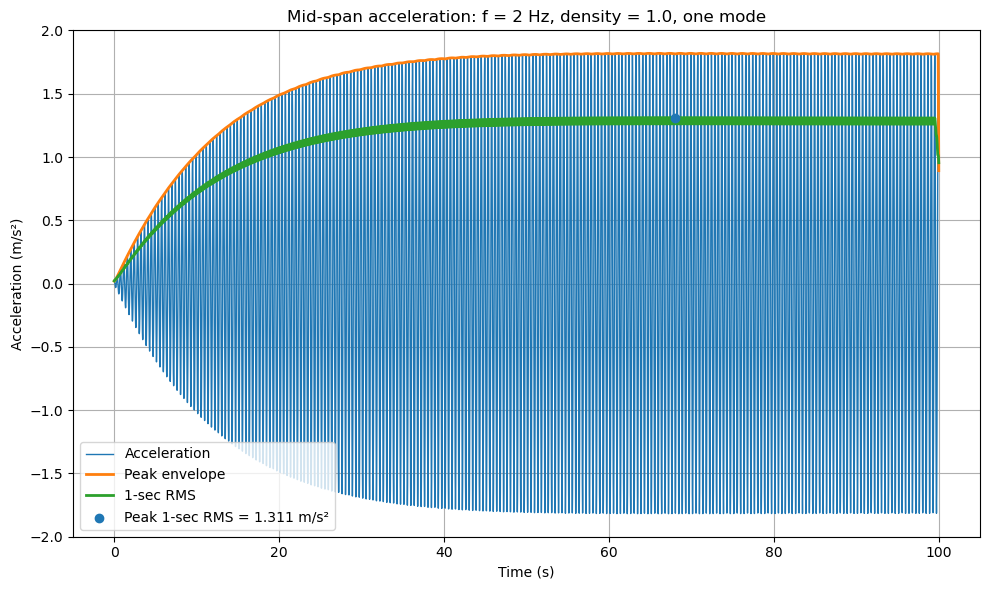

Peak absolute acceleration = 1.8191091700458906
Peak envelope              = 1.8191091700458906
Max 1-sec RMS from result  = 1.3112790406630033
Max 1-sec RMS calculated   = 1.3112790406630033
Time of peak 1-sec RMS     = 68.06
Modified modal mass        = 16000.0


In [19]:
import matplotlib.pyplot as plt
import math
import numpy as np
from biascodefunction import *
# run deterministic/code response

result = run_code_response(
    density=0.83,
    mass_ratio=0.28,              # example mass ratio from stochastic simulation
    length=50.0,
    width=2.0,
    beam_freq=np.array([2.4]),                # first mode = 2 Hz
    modal_damping_ratio=np.array([0.005]),
    linear_mass=500.0,
    hht=0.01,
    t_end=100.0,
    numbers=1,                    # only one mode
    modify_both_modes=False,       # irrelevant here since only one mode
    force_reduction_factor=1
)

t = result["t"]
acc = result["acceleration"]
env = result["envelope"]

# calculate 1-sec RMS
dt = 0.01
rms_1s = sliding_rms(acc, dt=dt, window_sec=1.0)

# peak 1-sec RMS
peak_rms_1s = np.max(rms_1s)
idx_peak_rms = np.argmax(rms_1s)

# plot acceleration, envelope, and RMS
plt.figure(figsize=(10, 6))
plt.plot(t, acc, label="Acceleration", linewidth=1.0)
plt.plot(t, env, label="Peak envelope", linewidth=2.0)
plt.plot(t, rms_1s, label="1-sec RMS", linewidth=2.0)

plt.scatter(
    t[idx_peak_rms],
    rms_1s[idx_peak_rms],
    zorder=5,
    label=f"Peak 1-sec RMS = {peak_rms_1s:.3f} m/s²"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Mid-span acceleration: f = 2 Hz, density = 1.0, one mode")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# print useful scalar values
print("Peak absolute acceleration =", result["peak_abs_acceleration"])
print("Peak envelope              =", result["peak_envelope"])
print("Max 1-sec RMS from result  =", result["max_rms_1s"])
print("Max 1-sec RMS calculated   =", peak_rms_1s)
print("Time of peak 1-sec RMS     =", t[idx_peak_rms])
print("Modified modal mass        =", result["modified_modal_mass"])

Accelerations shape: (100, 10001)
Mean modal mass ratios shape: (100,)
Steady-state accelerations shape: (100, 9001)
Peak absolute acceleration values shape: (100,)
Peak absolute acceleration values:
[3.0406487  2.6082311  2.75576793 2.94709314 1.99691169 3.1180984
 1.90737473 1.43250661 1.99259714 1.80486419 1.93480581 2.63340516
 2.86725536 2.16548181 2.15772676 1.84245032 1.91047724 1.55201524
 3.38731351 1.83007803 2.20931768 3.11026964 1.56082458 2.37404697
 1.93167603 3.4634532  2.23764835 2.43632665 2.07073939 1.69300549
 1.87377339 2.07488665 1.94410306 1.80582577 1.93286783 2.53424271
 1.73782239 1.88817811 3.4499771  1.97623616 2.54823421 2.51613119
 2.97151804 2.90301619 1.92899247 1.76387114 2.29498334 1.93794446
 1.78498626 2.20031855 1.95427998 2.13015498 2.0114304  1.53061461
 1.97629451 2.7396435  1.88104395 3.12836078 2.10246179 3.63879884
 1.66349272 1.52905531 1.8221472  2.34847422 1.69020784 2.04558667
 2.10842145 2.188674   1.75664202 1.94377507 1.99784976 2.978277

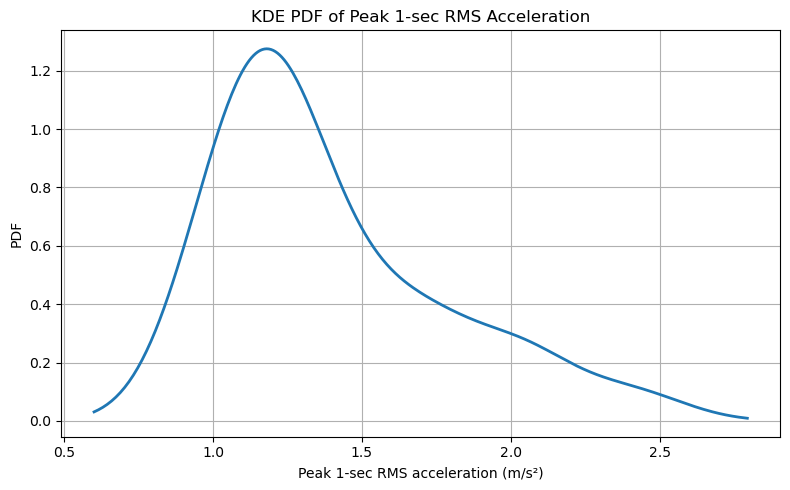

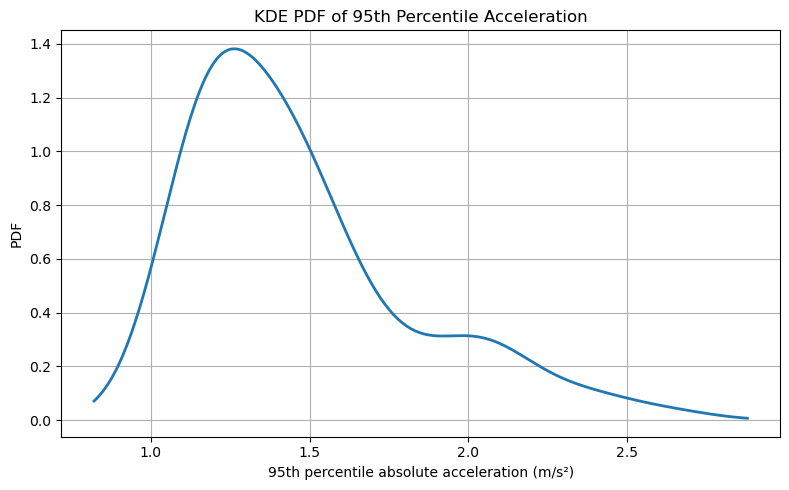

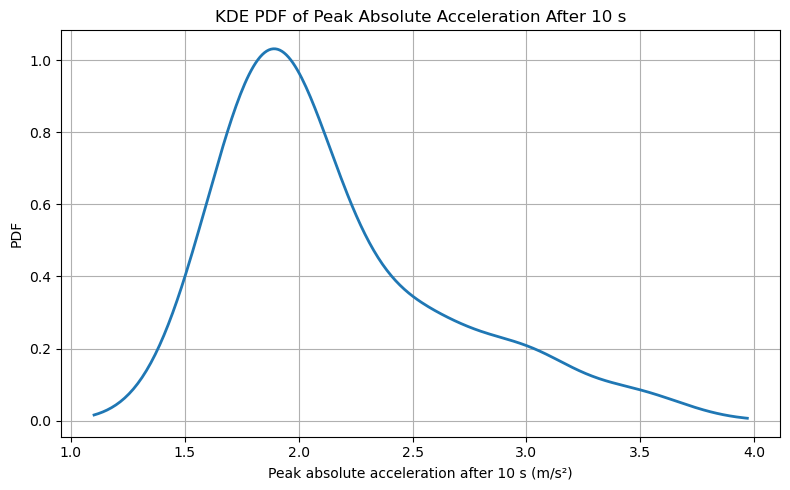

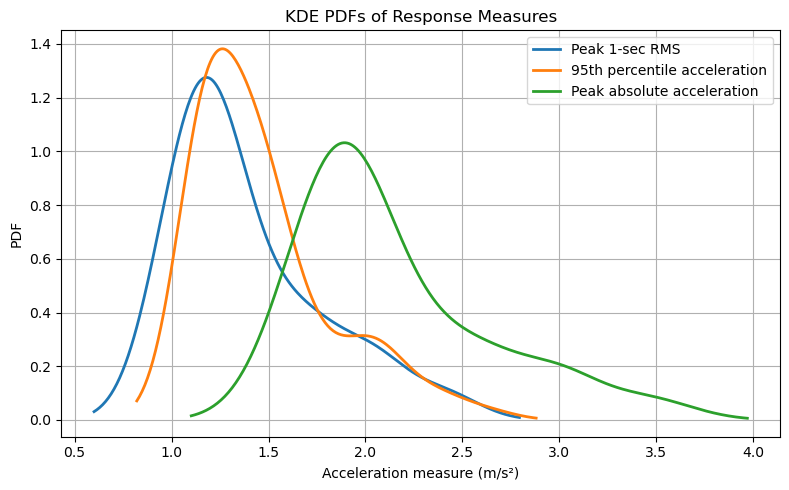

Overall mean modal mass ratio = 0.30481209678421506
Overall std modal mass ratio  = 0.10412049470511822


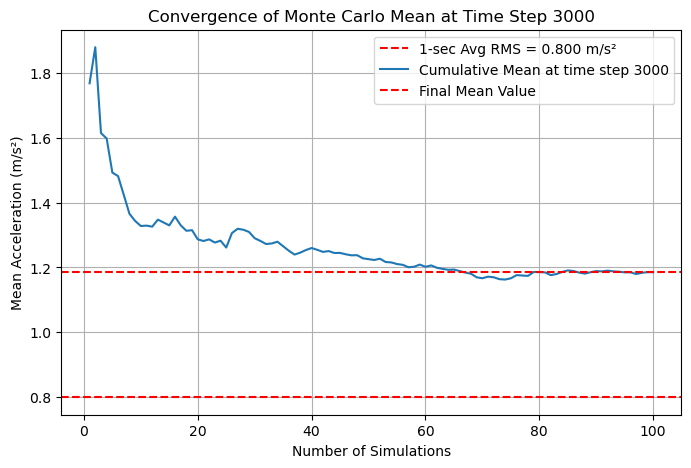

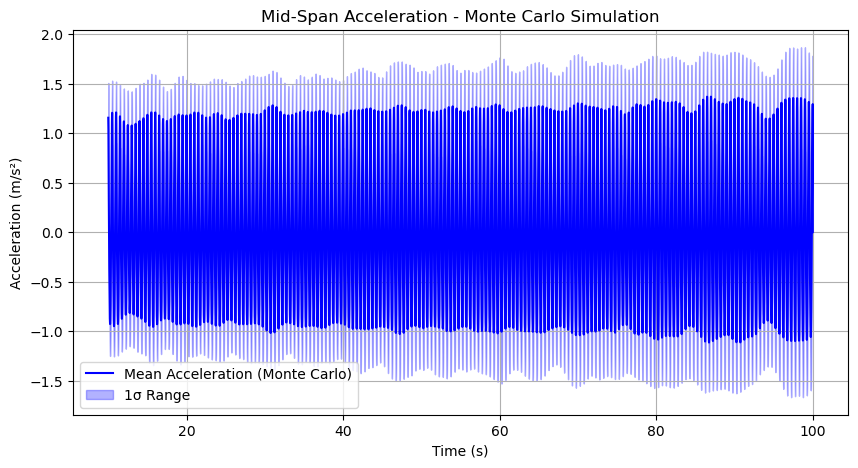

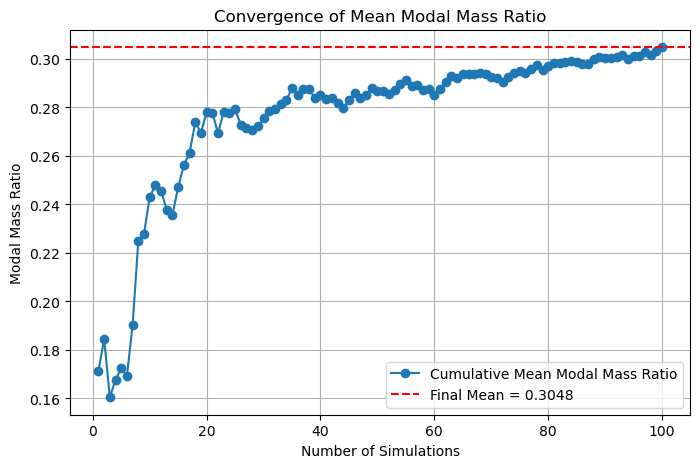

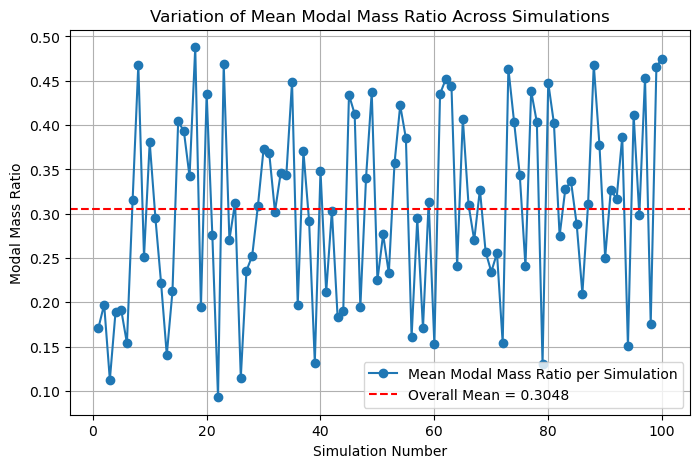

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing 
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt
from socialforcefunctions import initial_state_corridor
from solver import Newmarksuper_HSIsocial, compute_1sec_rms_mean
from matrix import bridge
from pedestrian import Pedestrian
from bias import run_simulation
from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    plot_kde_pdf
)
# Define Monte Carlo settings
NUM_SIMULATIONS = 100 # Number of Monte Carlo runs (increase for better statistics)
NUM_PROCESSES = 10  # Use all available CPU cores
hht = 0.01

# Using multiprocessing Pool to parallelize the simulations
if __name__ == "__main__":
    with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
        peddamp = 0.30
        pedBodyF = 3.10
        BeamFreq = np.array([2,8]) #Hz
        Beamdamp = np.array([0.005])
        Tocity = 50
        Outcity = 50
        Length = 50
        Width = 2

        # Different but reproducible seed for each MC run
        BASE_SEED = 12345
        seeds = np.random.SeedSequence(BASE_SEED).generate_state(NUM_SIMULATIONS)

        args_list = [(int(seeds[i]), peddamp, pedBodyF, BeamFreq, Beamdamp, Tocity, Outcity, Length, Width) for i in range(NUM_SIMULATIONS)]
        results = pool.map(run_simulation, args_list)

    # Convert results to NumPy array for statistical processing
    accelerations = [r[0] for r in results]
    mean_mass_ratios = [r[1] for r in results]

    # Convert to NumPy arrays
    accelerations = np.array(accelerations)         # shape: (num_sims, n_time_steps)
    mean_mass_ratios = np.array(mean_mass_ratios)   # shape: (num_sims,)

    print("Accelerations shape:", accelerations.shape)
    print("Mean modal mass ratios shape:", mean_mass_ratios.shape)
    steady_start_time = 10.0
    steady_start_idx = int(round(steady_start_time / hht))

    accelerations_ss = accelerations[:, steady_start_idx:]

    print("Steady-state accelerations shape:", accelerations_ss.shape)

    # Time vector for steady-state part
    t_ss = np.arange(accelerations_ss.shape[1]) * hht + steady_start_time

    rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
    )

    acc_95_values = percentile_acc_distribution(
    accelerations_ss,
    percentile=95,
    use_abs=True
    )

    # ==================================================
    # Distribution of peak absolute acceleration after 10 seconds
    # ==================================================
    peak_abs_acc_values = peak_abs_acc_distribution(
    accelerations_ss
    )

    print("Peak absolute acceleration values shape:", peak_abs_acc_values.shape)
    print("Peak absolute acceleration values:")
    print(peak_abs_acc_values)
    
    # KDE PDF of peak 1-sec RMS values
    x_peak_rms, kde_peak_rms = plot_kde_pdf(
    peak_rms_values,
    num_points=300,
    bandwidth="scott",
    xlabel="Peak 1-sec RMS acceleration (m/s²)",
    title="KDE PDF of Peak 1-sec RMS Acceleration"
    )

    # KDE PDF of 95th percentile acceleration values
    x_acc_95, kde_acc_95 = plot_kde_pdf(
    acc_95_values,
    num_points=300,
    bandwidth="scott",
    xlabel="95th percentile absolute acceleration (m/s²)",
    title="KDE PDF of 95th Percentile Acceleration"
    )
    # KDE PDF of peak absolute acceleration values
    x_peak_abs, kde_peak_abs = plot_kde_pdf(
    peak_abs_acc_values,
    num_points=300,
    bandwidth="scott",
    xlabel="Peak absolute acceleration after 10 s (m/s²)",
    title="KDE PDF of Peak Absolute Acceleration After 10 s"
    )

    plt.figure(figsize=(8, 5))

    plt.plot(x_peak_rms, kde_peak_rms, linewidth=2, label="Peak 1-sec RMS")
    plt.plot(x_acc_95, kde_acc_95, linewidth=2, label="95th percentile acceleration")
    plt.plot(x_peak_abs, kde_peak_abs, linewidth=2, label="Peak absolute acceleration")

    plt.xlabel("Acceleration measure (m/s²)")
    plt.ylabel("PDF")
    plt.title("KDE PDFs of Response Measures")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
 # --------------------------------------------------
    # Acceleration statistics
    # --------------------------------------------------
    mean_acceleration = np.mean(accelerations_ss, axis=0)
    std_acceleration = np.std(accelerations_ss, axis=0)

    # --------------------------------------------------
    # Cumulative mean of acceleration
    # --------------------------------------------------
    cumulative_means = np.array([
        np.mean(accelerations_ss[:i+1], axis=0) for i in range(NUM_SIMULATIONS)
    ])

    # Pick a specific time step to check convergence
    time_step = min(3000, accelerations_ss.shape[1] - 1)
    convergence_curve = cumulative_means[:, time_step]

    # Compute 1-second average RMS
    avg_1sec_rms = compute_1sec_rms_mean(accelerations_ss, int(1 / hht))

    # Time vector
    #t = np.arange(accelerations_ss.shape[1]) * hht + steady_start_time

    # --------------------------------------------------
    # Modal mass ratio statistics
    # --------------------------------------------------
    overall_mean_mass_ratio = np.mean(mean_mass_ratios)
    overall_std_mass_ratio = np.std(mean_mass_ratios)

    # Cumulative mean modal mass ratio
    sim_numbers = np.arange(1, NUM_SIMULATIONS + 1)
    cumulative_mean_mass_ratio = np.cumsum(mean_mass_ratios) / sim_numbers

    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Overall std modal mass ratio  =", overall_std_mass_ratio)

    # --------------------------------------------------
    # Plot 1: Acceleration convergence at selected time step
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.axhline(avg_1sec_rms, color='red', linestyle='--',
                label=f'1-sec Avg RMS = {avg_1sec_rms:.3f} m/s²')
    plt.plot(sim_numbers, convergence_curve, label=f"Cumulative Mean at time step {time_step}")
    plt.axhline(y=convergence_curve[-1], color='r', linestyle="--", label="Final Mean Value")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Mean Acceleration (m/s²)")
    plt.title(f"Convergence of Monte Carlo Mean at Time Step {time_step}")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 2: Mean acceleration time history
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(t_ss, mean_acceleration, label="Mean Acceleration (Monte Carlo)", color='b')
    plt.fill_between(
        t_ss,
        mean_acceleration - std_acceleration,
        mean_acceleration + std_acceleration,
        color='b',
        alpha=0.3,
        label="1σ Range"
    )
    plt.title("Mid-Span Acceleration - Monte Carlo Simulation")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 3: Cumulative mean of modal mass ratio
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, cumulative_mean_mass_ratio, marker='o',
             label="Cumulative Mean Modal Mass Ratio")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Final Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Convergence of Mean Modal Mass Ratio")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 4: Variation of modal mass ratio across simulations
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, mean_mass_ratios, marker='o', linestyle='-',
             label="Mean Modal Mass Ratio per Simulation")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Overall Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Simulation Number")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Variation of Mean Modal Mass Ratio Across Simulations")
    plt.legend()
    plt.grid()
    plt.show()



In [7]:
from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    plot_kde_pdf,
    run_code_response_from_mc_inputs
)
# ==================================================
# Deterministic/code response using same MC input set
# ==================================================

linear_mass = 500.0
t_end = accelerations.shape[1] * hht

code_result, code_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity,
    Outcity=Outcity,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=overall_mean_mass_ratio,
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False
)

print("\n--- Deterministic/code response measures after 10 s ---")
print("Density used                 =", code_measures["density"])
print("Mean MC modal mass ratio     =", code_measures["mean_mass_ratio_from_mc"])
print("Code mass ratio used         =", code_measures["code_mass_ratio_used"])
print("Mass ratio modified?         =", code_measures["mass_ratio_modified"])
print("Code peak absolute acc       =", code_measures["peak_abs_acc"])
print("Code peak 1-sec RMS          =", code_measures["peak_1sec_rms"])
print("Code 95% absolute acc        =", code_measures["p95_abs_acc"])


--- Deterministic/code response measures after 10 s ---
Density used                 = 1.0
Mean MC modal mass ratio     = 0.30481209678421506
Code mass ratio used         = 0.30481209678421506
Mass ratio modified?         = True
Code peak absolute acc       = 19.547048707830147
Code peak 1-sec RMS          = 13.84547286384103
Code 95% absolute acc        = 19.21508151988508


In [20]:
import pickle

with open("forcefactors_bridgeF_bridgedamp.pkl", "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

# ==================================================
# Simplified model using max available mass ratio = 0.2954
# ==================================================

target_bf = float(np.asarray(BeamFreq).ravel()[0])
target_beamdamp = float(np.asarray(Beamdamp).ravel()[0])

# use max available mass ratio from interpolation database
target_mass_ratio_used = 0.29

# interpolate modifying factor x
x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
    results_all=ff_results_all,
    target_bf=target_bf,
    target_beamdamp=target_beamdamp,
    target_mass_ratio=target_mass_ratio_used,
    damping_values=ff_damping_values,
    densities=ff_densities,
    bridge_frequencies=ff_bridge_frequencies,
    pedBodyF=ff_pedBodyF
)

print("\n--- Interpolated modifying factor ---")
print("Bridge frequency          =", target_bf)
print("Frequency ratio 3.1/fb    =", x_freq_ratio)
print("Damping ratio             =", target_beamdamp)
print("Mass ratio used for x     =", target_mass_ratio_used)
print("Interpolated x factor     =", x_factor)

# modify density by multiplying pedestrian numbers by x
Tocity_simplified = Tocity * x_factor
Outcity_simplified = Outcity * x_factor

base_density = (Tocity + Outcity) / (Width * Length)
modified_density = (Tocity_simplified + Outcity_simplified) / (Width * Length)

print("\n--- Density modification ---")
print("Original density =", base_density)
print("Modified density =", modified_density)

# run simplified deterministic prediction
simplified_result, simplified_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity_simplified,
    Outcity=Outcity_simplified,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=target_mass_ratio_used,   # use 0.2954 here too
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False
)

print("\n--- Simplified/code response measures after 10 s ---")
print("Density used                 =", simplified_measures["density"])
print("Mass ratio used              =", simplified_measures["code_mass_ratio_used"])
print("Mass ratio modified?         =", simplified_measures["mass_ratio_modified"])
print("Simplified peak absolute acc =", simplified_measures["peak_abs_acc"])
print("Simplified peak 1-sec RMS    =", simplified_measures["peak_1sec_rms"])
print("Simplified 95% absolute acc  =", simplified_measures["p95_abs_acc"])


--- Interpolated modifying factor ---
Bridge frequency          = 2.0
Frequency ratio 3.1/fb    = 1.55
Damping ratio             = 0.005
Mass ratio used for x     = 0.29
Interpolated x factor     = 0.18775621534451364

--- Density modification ---
Original density = 1.0
Modified density = 0.18775621534451364

--- Simplified/code response measures after 10 s ---
Density used                 = 0.18775621534451364
Mass ratio used              = 0.29
Mass ratio modified?         = True
Simplified peak absolute acc = 3.536499896401526
Simplified peak 1-sec RMS    = 2.5049568392895507
Simplified 95% absolute acc  = 3.476439580221585



Bias: MC peak absolute acceleration / code
Mean     = 0.10996466843779253
Std      = 0.02506963348459147
COV      = 0.22797898489343843
Median   = 0.10110948303058924
5%       = 0.08245741222354619
95%      = 0.15954385581608055
Min      = 0.07328505873160483
Max      = 0.18615592021276967

Bias: MC peak 1-sec RMS / code
Mean     = 0.10063797439192984
Std      = 0.027887408761799605
COV      = 0.2771062208902716
Median   = 0.0914453545002729
5%       = 0.06838842273347912
95%      = 0.15720030192824005
Min      = 0.06163573491948954
Max      = 0.18353818393345608

Bias: MC 95% acceleration / code
Mean     = 0.0763487880283818
Std      = 0.01821461181951368
COV      = 0.23857106694008823
Median   = 0.07202986227783217
5%       = 0.05743540622829169
95%      = 0.11237968750220413
Min      = 0.05507629503587029
Max      = 0.13753203520147522

Bias: MC peak absolute acceleration / simplified
Mean     = 0.6078000263144572
Std      = 0.13856563301737515
COV      = 0.22797898489343849
Median

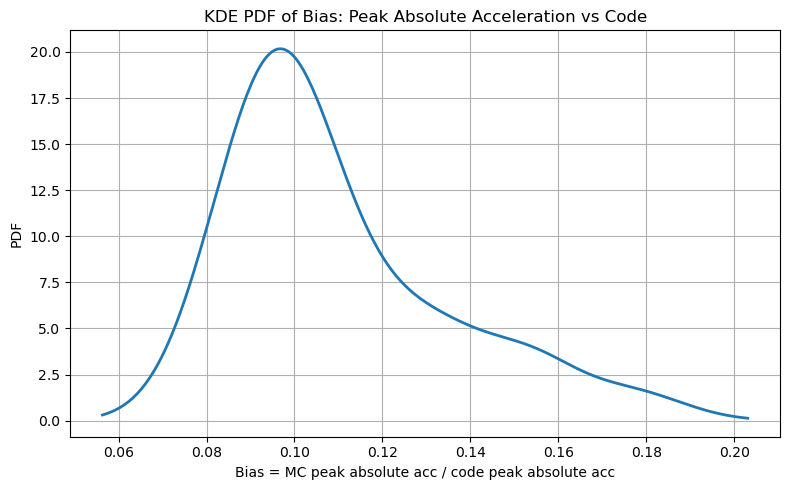

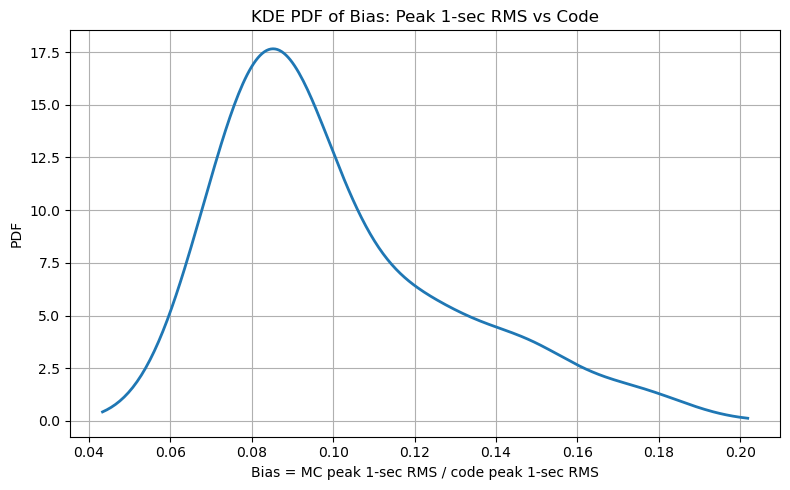

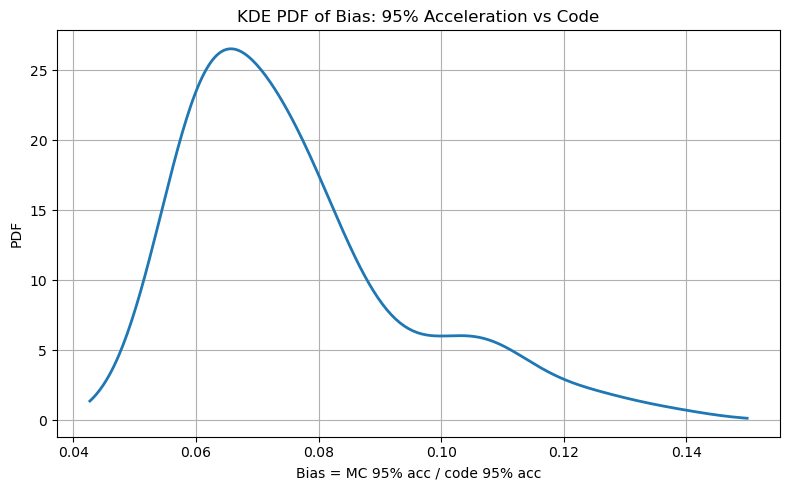

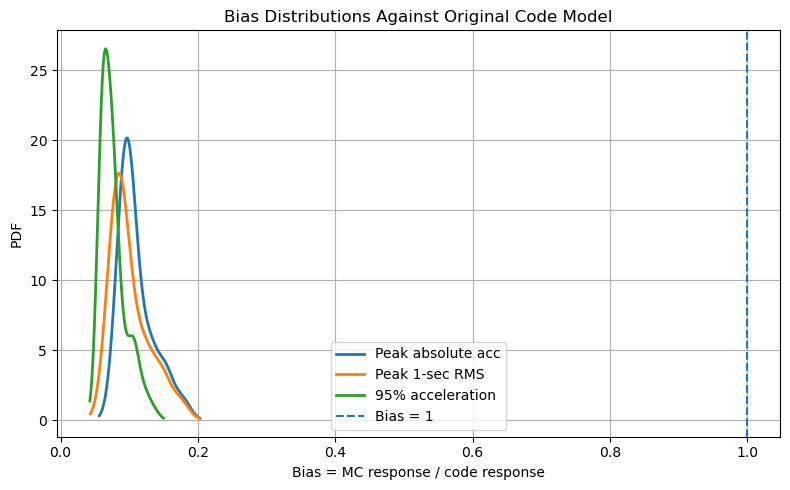

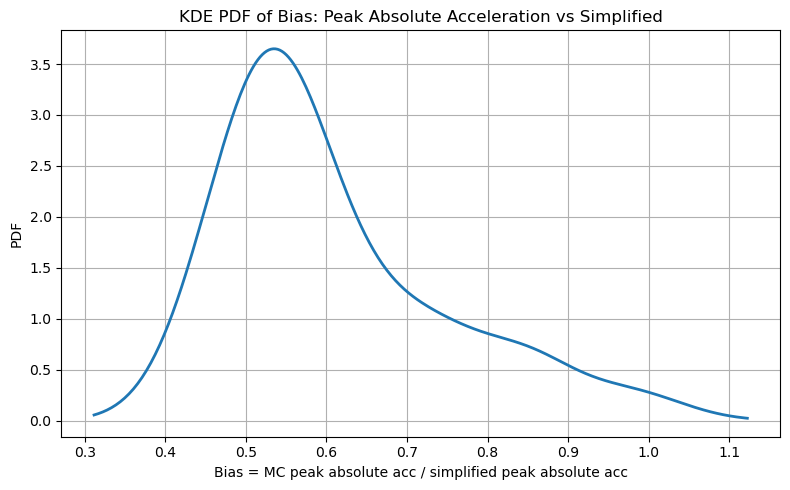

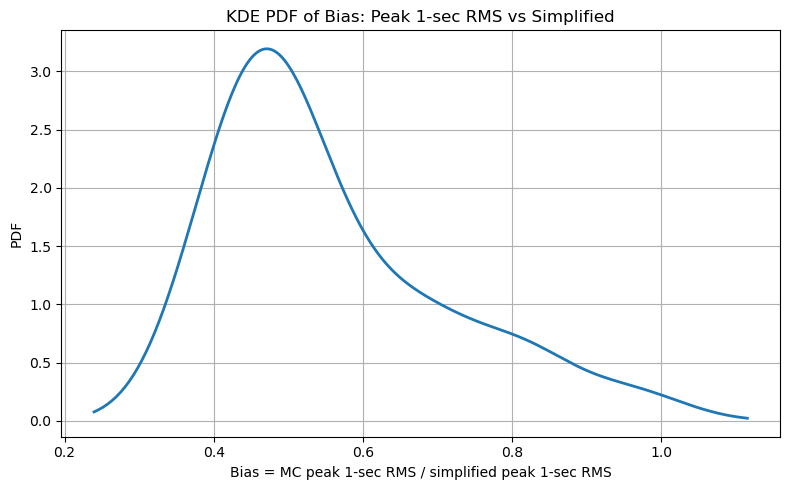

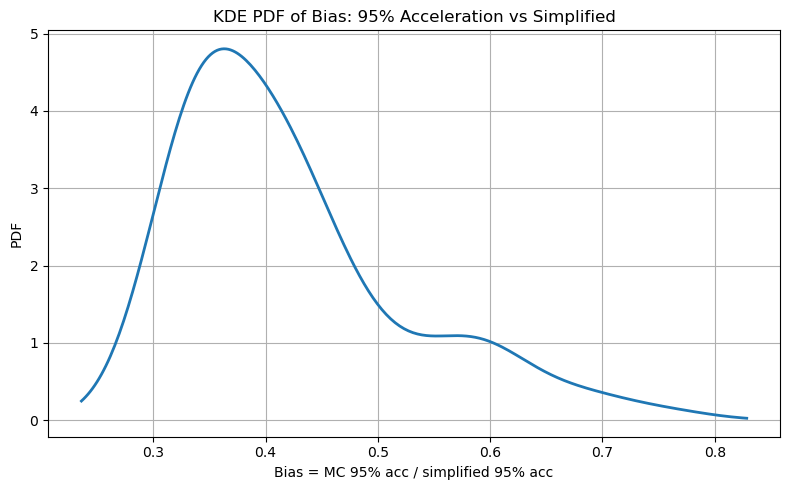

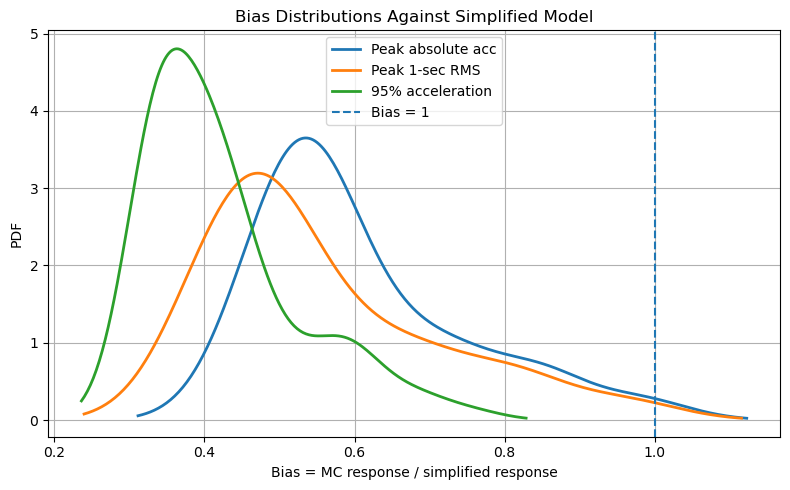

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from biascodefunction import plot_kde_pdf

# ==================================================
# Bias distributions
# MC distribution / deterministic scalar prediction
# ==================================================

eps = 1e-12

# --------------------------------------------------
# Bias against original deterministic code model
# --------------------------------------------------
B_code_peak_abs = peak_abs_acc_values / max(code_measures["peak_abs_acc"], eps)
B_code_peak_rms = peak_rms_values / max(code_measures["peak_1sec_rms"], eps)
B_code_acc_95   = acc_95_values / max(code_measures["p95_abs_acc"], eps)

# --------------------------------------------------
# Bias against simplified model
# --------------------------------------------------
B_simp_peak_abs = peak_abs_acc_values / max(simplified_measures["peak_abs_acc"], eps)
B_simp_peak_rms = peak_rms_values / max(simplified_measures["peak_1sec_rms"], eps)
B_simp_acc_95   = acc_95_values / max(simplified_measures["p95_abs_acc"], eps)

def print_bias_stats(name, B):
    print(f"\n{name}")
    print("Mean     =", np.mean(B))
    print("Std      =", np.std(B))
    print("COV      =", np.std(B) / np.mean(B))
    print("Median   =", np.percentile(B, 50))
    print("5%       =", np.percentile(B, 5))
    print("95%      =", np.percentile(B, 95))
    print("Min      =", np.min(B))
    print("Max      =", np.max(B))


print_bias_stats("Bias: MC peak absolute acceleration / code", B_code_peak_abs)
print_bias_stats("Bias: MC peak 1-sec RMS / code", B_code_peak_rms)
print_bias_stats("Bias: MC 95% acceleration / code", B_code_acc_95)

print_bias_stats("Bias: MC peak absolute acceleration / simplified", B_simp_peak_abs)
print_bias_stats("Bias: MC peak 1-sec RMS / simplified", B_simp_peak_rms)
print_bias_stats("Bias: MC 95% acceleration / simplified", B_simp_acc_95)

# ==================================================
# KDE PDFs: bias against original code
# ==================================================

x_B_code_peak_abs, kde_B_code_peak_abs = plot_kde_pdf(
    B_code_peak_abs,
    num_points=300,
    bandwidth="scott",
    xlabel="Bias = MC peak absolute acc / code peak absolute acc",
    title="KDE PDF of Bias: Peak Absolute Acceleration vs Code"
)

x_B_code_peak_rms, kde_B_code_peak_rms = plot_kde_pdf(
    B_code_peak_rms,
    num_points=300,
    bandwidth="scott",
    xlabel="Bias = MC peak 1-sec RMS / code peak 1-sec RMS",
    title="KDE PDF of Bias: Peak 1-sec RMS vs Code"
)

x_B_code_acc_95, kde_B_code_acc_95 = plot_kde_pdf(
    B_code_acc_95,
    num_points=300,
    bandwidth="scott",
    xlabel="Bias = MC 95% acc / code 95% acc",
    title="KDE PDF of Bias: 95% Acceleration vs Code"
)

# ==================================================
# Combined plot: code bias distributions
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(x_B_code_peak_abs, kde_B_code_peak_abs, linewidth=2, label="Peak absolute acc")
plt.plot(x_B_code_peak_rms, kde_B_code_peak_rms, linewidth=2, label="Peak 1-sec RMS")
plt.plot(x_B_code_acc_95, kde_B_code_acc_95, linewidth=2, label="95% acceleration")

plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Bias = MC response / code response")
plt.ylabel("PDF")
plt.title("Bias Distributions Against Original Code Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# ==================================================
# KDE PDFs: bias against simplified model
# ==================================================

x_B_simp_peak_abs, kde_B_simp_peak_abs = plot_kde_pdf(
    B_simp_peak_abs,
    num_points=300,
    bandwidth="scott",
    xlabel="Bias = MC peak absolute acc / simplified peak absolute acc",
    title="KDE PDF of Bias: Peak Absolute Acceleration vs Simplified"
)

x_B_simp_peak_rms, kde_B_simp_peak_rms = plot_kde_pdf(
    B_simp_peak_rms,
    num_points=300,
    bandwidth="scott",
    xlabel="Bias = MC peak 1-sec RMS / simplified peak 1-sec RMS",
    title="KDE PDF of Bias: Peak 1-sec RMS vs Simplified"
)

x_B_simp_acc_95, kde_B_simp_acc_95 = plot_kde_pdf(
    B_simp_acc_95,
    num_points=300,
    bandwidth="scott",
    xlabel="Bias = MC 95% acc / simplified 95% acc",
    title="KDE PDF of Bias: 95% Acceleration vs Simplified"
)
# ==================================================
# Combined plot: simplified bias distributions
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(x_B_simp_peak_abs, kde_B_simp_peak_abs, linewidth=2, label="Peak absolute acc")
plt.plot(x_B_simp_peak_rms, kde_B_simp_peak_rms, linewidth=2, label="Peak 1-sec RMS")
plt.plot(x_B_simp_acc_95, kde_B_simp_acc_95, linewidth=2, label="95% acceleration")

plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Bias = MC response / simplified response")
plt.ylabel("PDF")
plt.title("Bias Distributions Against Simplified Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
import importlib
import biascodefunction

importlib.reload(biascodefunction)

print(biascodefunction.__file__)
print(hasattr(biascodefunction, "run_code_response_from_mc_inputs"))
print(hasattr(biascodefunction, "interpolate_force_factor_exact_point"))

\\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\biascodefunction.py
True
True



--- MC reference system ---
Accelerations shape          = (10, 10001)
Mean modal mass ratios shape = (10,)
Overall mean modal mass ratio = 0.29069761812982453
Overall std modal mass ratio  = 0.11882402009864786
Steady-state accelerations shape = (10, 9001)

--- MC response distributions after 10 s ---
Peak absolute acceleration values shape = (10,)
Peak 1-sec RMS values shape            = (10,)
95% acceleration values shape          = (10,)


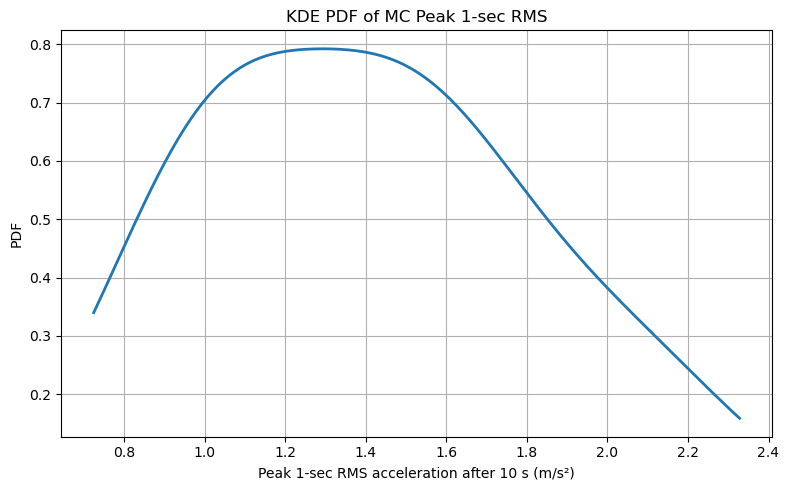

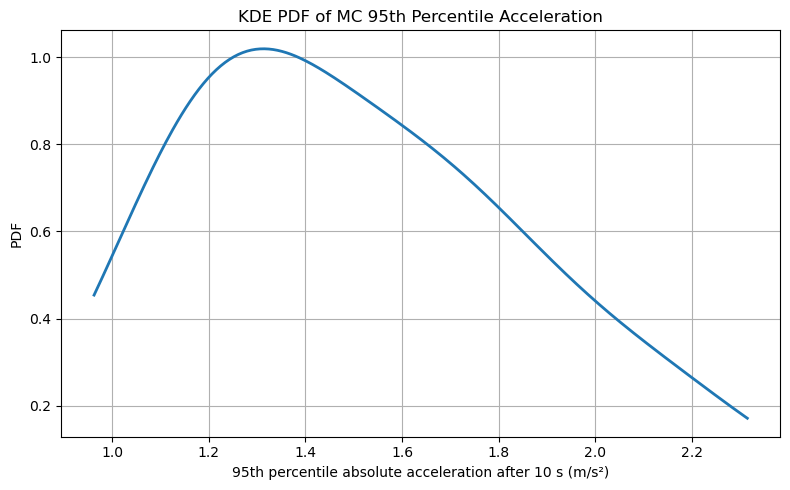

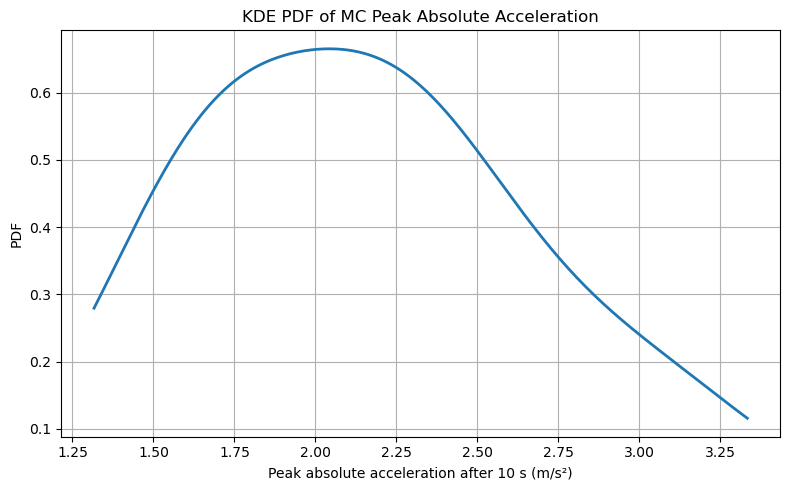

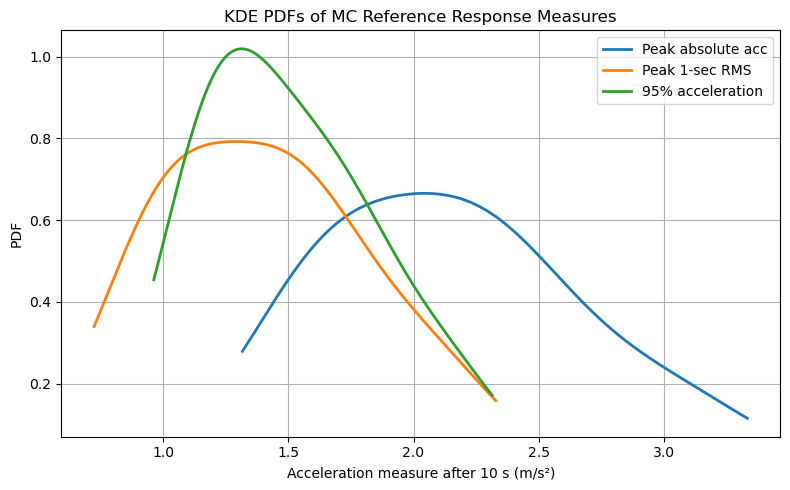


--- Original deterministic/code response after 10 s ---
Density used                 = 1.0
Mean MC modal mass ratio     = 0.29069761812982453
Code mass ratio used         = 0.29069761812982453
Mass ratio modified?         = True
Code peak absolute acc       = 19.760806289672097
Code peak 1-sec RMS          = 13.996880620739427
Code 95% absolute acc        = 19.425208860434896
MC mean mass ratio      = 0.29069761812982453
Mass ratio used for x   = 0.29

--- Interpolated modifying factor for simplified model ---
Target bridge frequency        = 2.0
Frequency ratio 3.1/fb         = 1.55
Target damping ratio           = 0.005
MC mean mass ratio             = 0.29069761812982453
Mass ratio used for x          = 0.29
Interpolated density factor x  = 0.18775621534451364
Lower damping used             = 0.005
Upper damping used             = 0.005
FF at lower damping            = 0.18775621534451364
FF at upper damping            = 0.18775621534451364
Damping interpolation weight   = 0.0

---

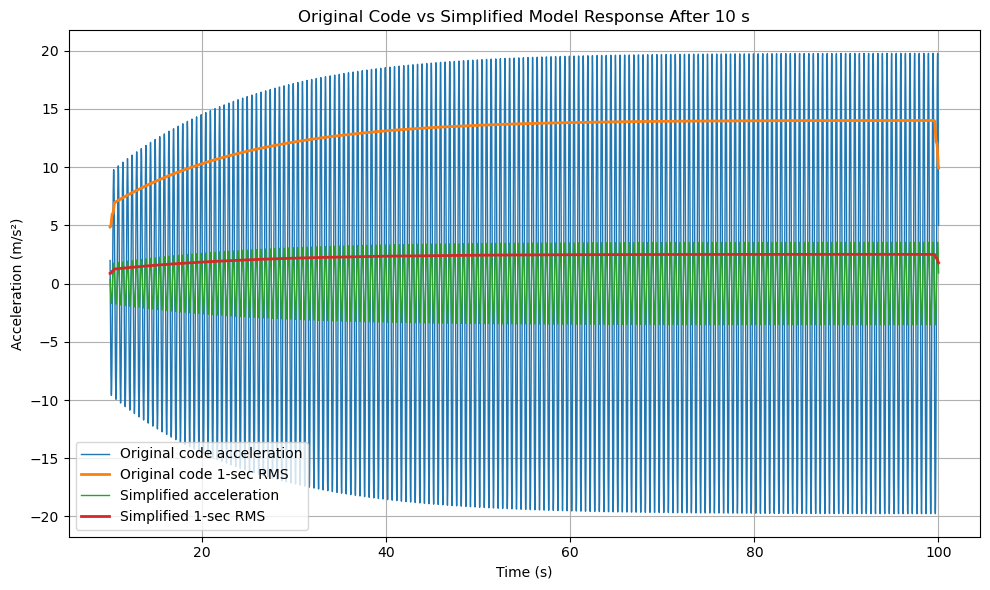


Bias: MC peak absolute acceleration / original code
Mean     = 0.10891431125551934
Std      = 0.023973391859778714
COV      = 0.22011241299167503
Median   = 0.10998624410958768
5%       = 0.07966866673574306
95%      = 0.14772698559262176
Min      = 0.07840752476773548
Max      = 0.1568940249042266

Bias: MC peak 1-sec RMS / original code
Mean     = 0.10070066207928581
Std      = 0.027398083312732305
COV      = 0.2720745102069007
Median   = 0.10269623813510043
5%       = 0.06764281554412975
95%      = 0.14468182665033033
Min      = 0.0649564599457489
Max      = 0.15310744934685777

Bias: MC 95% acceleration / original code
Mean     = 0.0775321558734374
Std      = 0.016613482473391117
COV      = 0.21427860848485594
Median   = 0.07431618913214194
5%       = 0.0590693658915411
95%      = 0.1046452350501626
Min      = 0.05758570507276883
Max      = 0.11110983468011026

Bias: MC peak absolute acceleration / simplified
Mean     = 0.6085775964770481
Std      = 0.13395548325323703
COV      = 

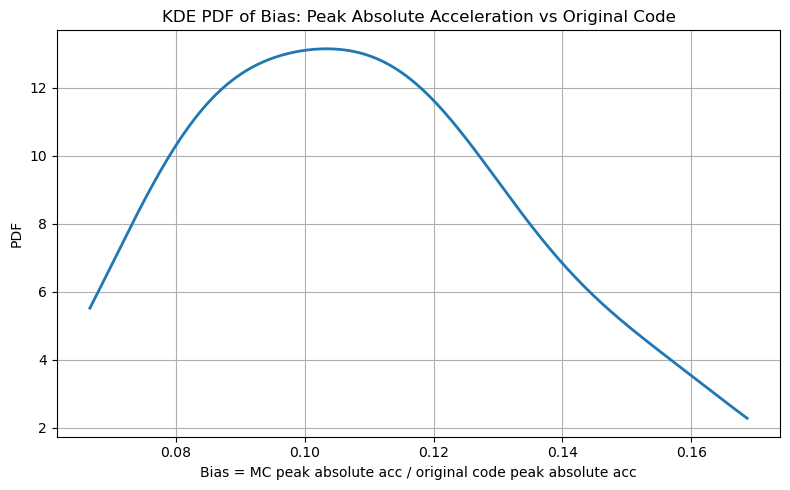

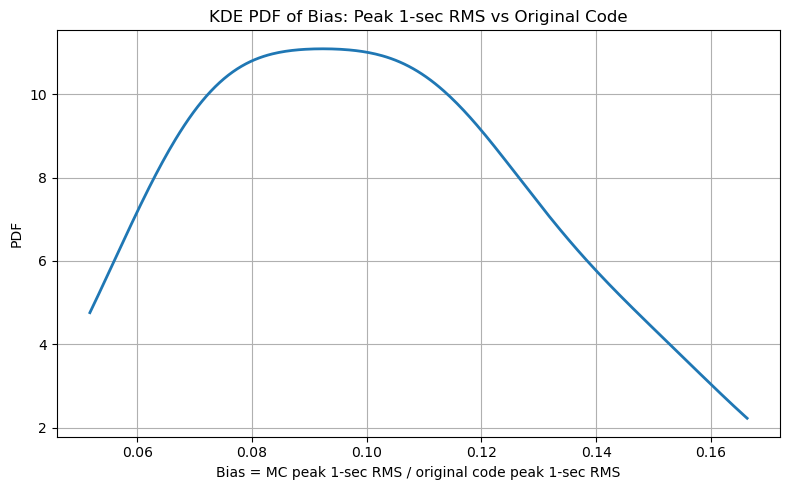

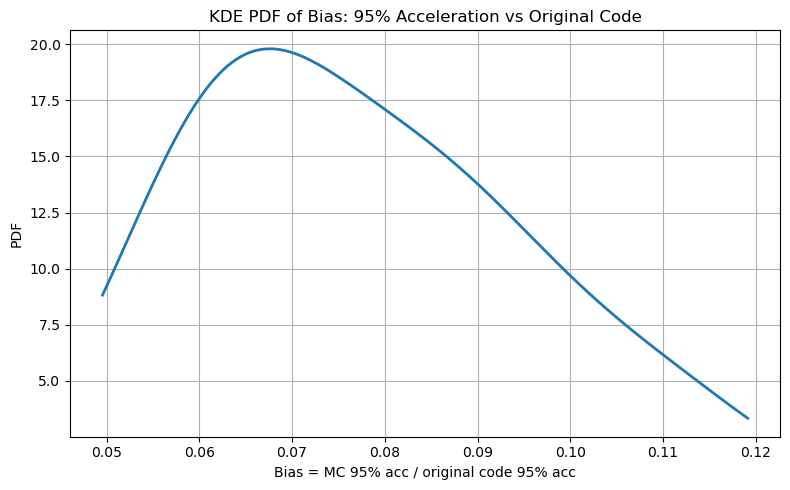

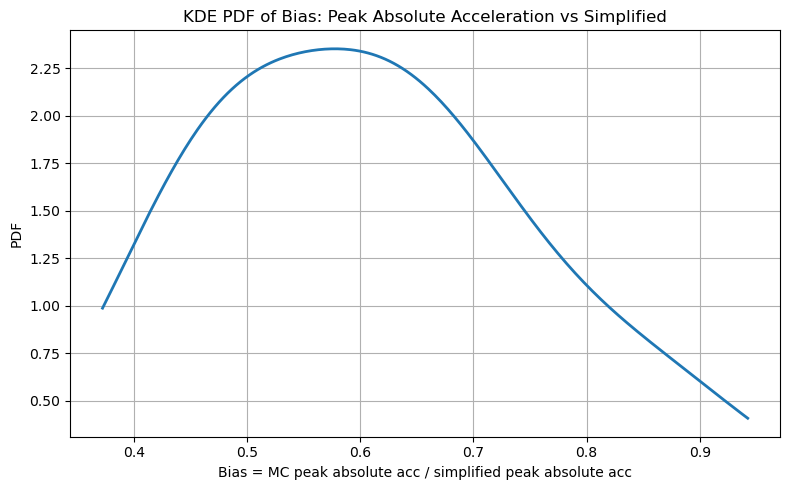

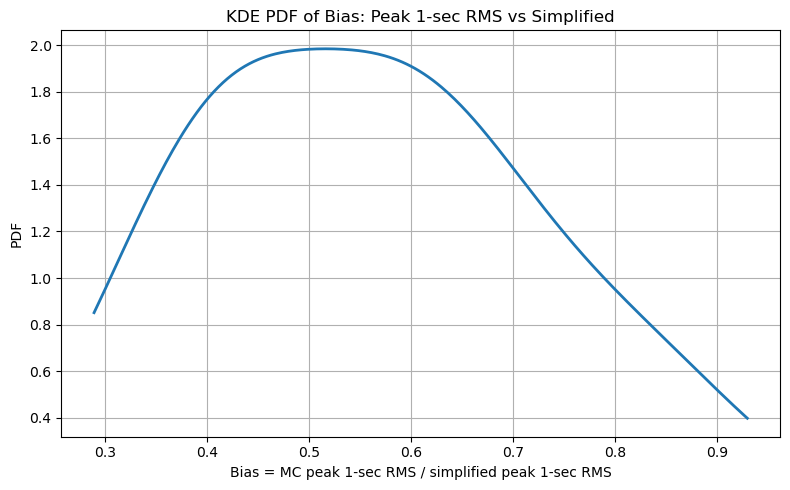

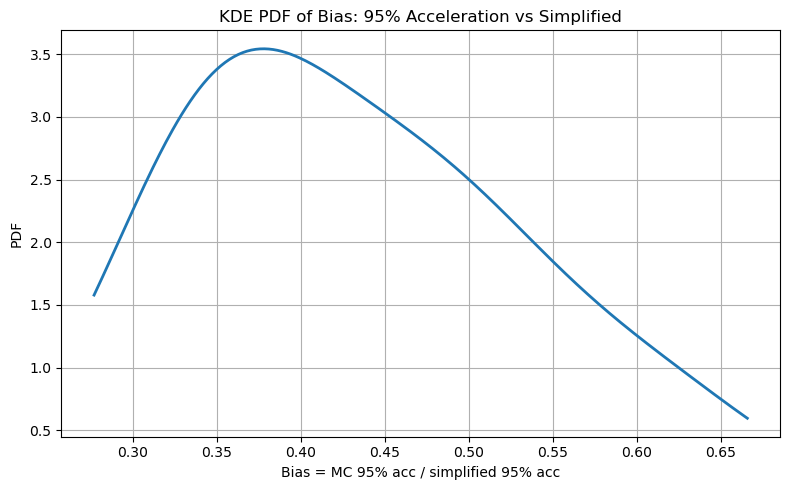

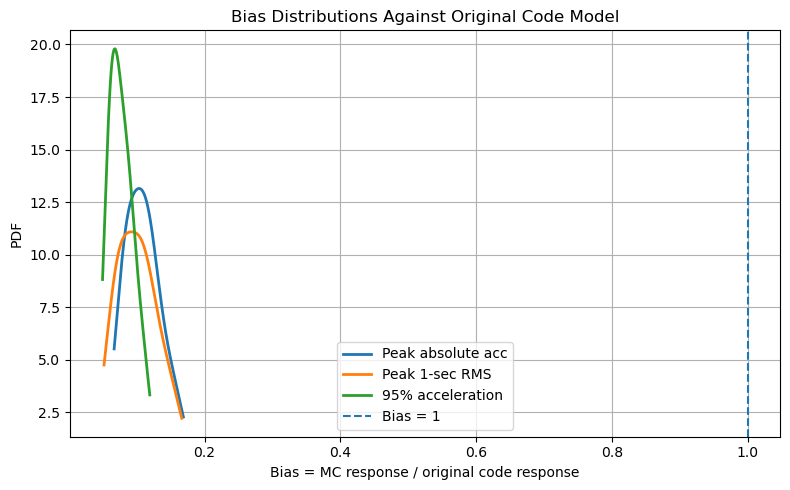

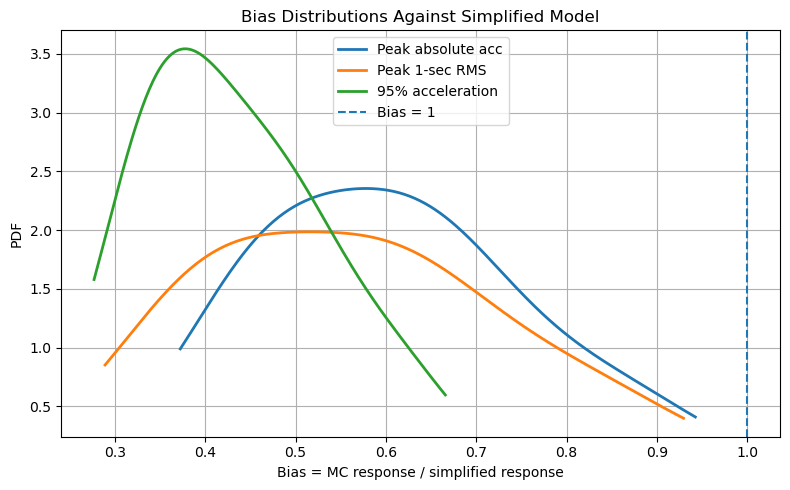

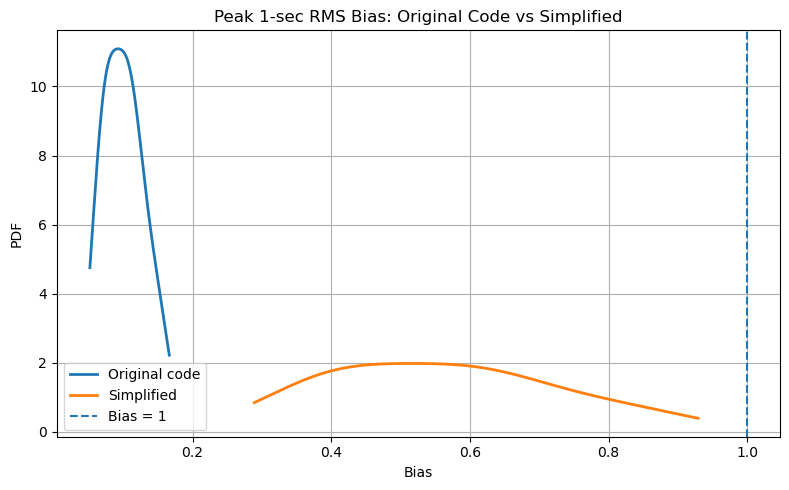

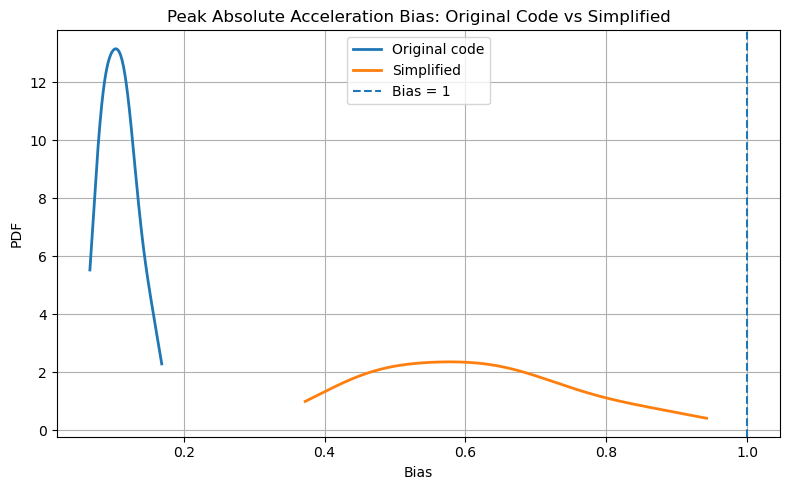

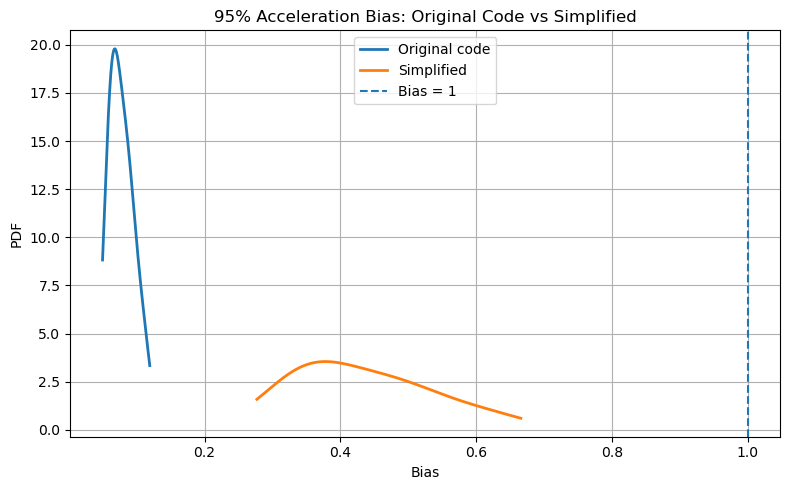

In [23]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    plot_kde_pdf,
    run_code_response_from_mc_inputs,
    interpolate_force_factor_exact_point
)

# ==================================================
# SETTINGS
# ==================================================

NUM_SIMULATIONS = 10
NUM_PROCESSES = 10

hht = 0.01
steady_start_time = 10.0

peddamp = 0.30
pedBodyF = 3.10
BeamFreq = np.array([2, 8])       # MC uses first mode plus second mode
Beamdamp = np.array([0.005])

Tocity = 50
Outcity = 50
Length = 50
Width = 2

linear_mass = 500.0

# For simplified model interpolation
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

# Temporary cap because current interpolation database max mass ratio is around 0.2954
MAX_AVAILABLE_MASS_RATIO_FOR_X = 0.29


# ==================================================
# SMALL HELPER
# ==================================================

def print_bias_stats(name, B):
    print(f"\n{name}")
    print("Mean     =", np.mean(B))
    print("Std      =", np.std(B))
    print("COV      =", np.std(B) / np.mean(B))
    print("Median   =", np.percentile(B, 50))
    print("5%       =", np.percentile(B, 5))
    print("95%      =", np.percentile(B, 95))
    print("Min      =", np.min(B))
    print("Max      =", np.max(B))


if __name__ == "__main__":

    # ==================================================
    # 1. RUN MC REFERENCE SYSTEM
    # ==================================================

    with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:

        BASE_SEED = 12345
        seeds = np.random.SeedSequence(BASE_SEED).generate_state(NUM_SIMULATIONS)

        args_list = [
            (
                int(seeds[i]),
                peddamp,
                pedBodyF,
                BeamFreq,
                Beamdamp,
                Tocity,
                Outcity,
                Length,
                Width
            )
            for i in range(NUM_SIMULATIONS)
        ]

        results = pool.map(run_simulation, args_list)

    accelerations = np.array([r[0] for r in results])
    mean_mass_ratios = np.array([r[1] for r in results])

    print("\n--- MC reference system ---")
    print("Accelerations shape          =", accelerations.shape)
    print("Mean modal mass ratios shape =", mean_mass_ratios.shape)

    overall_mean_mass_ratio = np.mean(mean_mass_ratios)
    overall_std_mass_ratio = np.std(mean_mass_ratios)

    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Overall std modal mass ratio  =", overall_std_mass_ratio)

    # ==================================================
    # 2. TRIM FIRST 10 SECONDS
    # ==================================================

    steady_start_idx = int(round(steady_start_time / hht))

    if steady_start_idx >= accelerations.shape[1]:
        raise ValueError("steady_start_time is longer than the acceleration time history.")

    accelerations_ss = accelerations[:, steady_start_idx:]
    t_ss = np.arange(accelerations_ss.shape[1]) * hht + steady_start_time

    print("Steady-state accelerations shape =", accelerations_ss.shape)

    # ==================================================
    # 3. MC RESPONSE DISTRIBUTIONS
    # ==================================================

    rms_histories, peak_rms_values = peak_rms_distribution(
        accelerations_ss,
        dt=hht,
        window_sec=1.0
    )

    acc_95_values = percentile_acc_distribution(
        accelerations_ss,
        percentile=95,
        use_abs=True
    )

    peak_abs_acc_values = peak_abs_acc_distribution(
        accelerations_ss
    )

    print("\n--- MC response distributions after 10 s ---")
    print("Peak absolute acceleration values shape =", peak_abs_acc_values.shape)
    print("Peak 1-sec RMS values shape            =", peak_rms_values.shape)
    print("95% acceleration values shape          =", acc_95_values.shape)

    # Optional: plot MC response measure PDFs
    x_peak_rms, kde_peak_rms = plot_kde_pdf(
        peak_rms_values,
        num_points=300,
        bandwidth="scott",
        xlabel="Peak 1-sec RMS acceleration after 10 s (m/s²)",
        title="KDE PDF of MC Peak 1-sec RMS"
    )

    x_acc_95, kde_acc_95 = plot_kde_pdf(
        acc_95_values,
        num_points=300,
        bandwidth="scott",
        xlabel="95th percentile absolute acceleration after 10 s (m/s²)",
        title="KDE PDF of MC 95th Percentile Acceleration"
    )

    x_peak_abs, kde_peak_abs = plot_kde_pdf(
        peak_abs_acc_values,
        num_points=300,
        bandwidth="scott",
        xlabel="Peak absolute acceleration after 10 s (m/s²)",
        title="KDE PDF of MC Peak Absolute Acceleration"
    )

    plt.figure(figsize=(8, 5))
    plt.plot(x_peak_abs, kde_peak_abs, linewidth=2, label="Peak absolute acc")
    plt.plot(x_peak_rms, kde_peak_rms, linewidth=2, label="Peak 1-sec RMS")
    plt.plot(x_acc_95, kde_acc_95, linewidth=2, label="95% acceleration")
    plt.xlabel("Acceleration measure after 10 s (m/s²)")
    plt.ylabel("PDF")
    plt.title("KDE PDFs of MC Reference Response Measures")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ==================================================
    # 4. ORIGINAL DETERMINISTIC/CODE PREDICTION
    # ==================================================

    t_end = accelerations.shape[1] * hht

    code_result, code_measures = run_code_response_from_mc_inputs(
        Tocity=Tocity,
        Outcity=Outcity,
        Length=Length,
        Width=Width,
        BeamFreq=BeamFreq,
        Beamdamp=Beamdamp,
        linear_mass=linear_mass,
        hht=hht,
        t_end=t_end,
        mean_mass_ratio=overall_mean_mass_ratio,
        mass_ratio_limit=0.05,
        steady_start_time=steady_start_time,
        numbers=1,
        modify_both_modes=False
    )

    print("\n--- Original deterministic/code response after 10 s ---")
    print("Density used                 =", code_measures["density"])
    print("Mean MC modal mass ratio     =", code_measures["mean_mass_ratio_from_mc"])
    print("Code mass ratio used         =", code_measures["code_mass_ratio_used"])
    print("Mass ratio modified?         =", code_measures["mass_ratio_modified"])
    print("Code peak absolute acc       =", code_measures["peak_abs_acc"])
    print("Code peak 1-sec RMS          =", code_measures["peak_1sec_rms"])
    print("Code 95% absolute acc        =", code_measures["p95_abs_acc"])

    # ==================================================
    # 5. LOAD FORCE-FACTOR DATABASE
    # ==================================================

    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_bridge_frequencies = ff_data["bridge_frequencies"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    # ==================================================
    # 6. INTERPOLATE MODIFICATION FACTOR x
    # ==================================================

    target_bf = float(np.asarray(BeamFreq).ravel()[0])
    target_beamdamp = float(np.asarray(Beamdamp).ravel()[0])

    # For now, use capped mass ratio because database does not cover higher values
    # Cap mass ratio for interpolation
    mc_mass_ratio = float(overall_mean_mass_ratio)

    if mc_mass_ratio > 0.29:
        target_mass_ratio_used = 0.29
    else:
        target_mass_ratio_used = mc_mass_ratio

    print("MC mean mass ratio      =", mc_mass_ratio)
    print("Mass ratio used for x   =", target_mass_ratio_used)

    x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
        results_all=ff_results_all,
        target_bf=target_bf,
        target_beamdamp=target_beamdamp,
        target_mass_ratio=target_mass_ratio_used,
        damping_values=ff_damping_values,
        densities=ff_densities,
        bridge_frequencies=ff_bridge_frequencies,
        pedBodyF=ff_pedBodyF
    )

    print("\n--- Interpolated modifying factor for simplified model ---")
    print("Target bridge frequency        =", target_bf)
    print("Frequency ratio 3.1/fb         =", x_freq_ratio)
    print("Target damping ratio           =", target_beamdamp)
    print("MC mean mass ratio             =", overall_mean_mass_ratio)
    print("Mass ratio used for x          =", target_mass_ratio_used)
    print("Interpolated density factor x  =", x_factor)
    print("Lower damping used             =", interp_details["lower_damp"])
    print("Upper damping used             =", interp_details["upper_damp"])
    print("FF at lower damping            =", interp_details["ff_lower"])
    print("FF at upper damping            =", interp_details["ff_upper"])
    print("Damping interpolation weight   =", interp_details["damping_weight"])

    # ==================================================
    # 7. SIMPLIFIED MODEL PREDICTION
    # ==================================================
    # run_code_response_from_mc_inputs calculates:
    # density = (Tocity + Outcity) / (Width * Length)
    #
    # Therefore, to make:
    # density_simplified = x * density_original
    #
    # we multiply Tocity and Outcity by x.

    Tocity_simplified = Tocity * x_factor
    Outcity_simplified = Outcity * x_factor

    base_density = (Tocity + Outcity) / (Width * Length)
    modified_density = (Tocity_simplified + Outcity_simplified) / (Width * Length)

    print("\n--- Density modification for simplified model ---")
    print("Original density =", base_density)
    print("x factor         =", x_factor)
    print("Modified density =", modified_density)

    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
        Tocity=Tocity_simplified,
        Outcity=Outcity_simplified,
        Length=Length,
        Width=Width,
        BeamFreq=BeamFreq,
        Beamdamp=Beamdamp,
        linear_mass=linear_mass,
        hht=hht,
        t_end=t_end,
        mean_mass_ratio=target_mass_ratio_used,
        mass_ratio_limit=0.05,
        steady_start_time=steady_start_time,
        numbers=1,
        modify_both_modes=False
    )

    print("\n--- Simplified/code response after 10 s ---")
    print("Density used                 =", simplified_measures["density"])
    print("Mass ratio used              =", simplified_measures["code_mass_ratio_used"])
    print("Mass ratio modified?         =", simplified_measures["mass_ratio_modified"])
    print("Simplified peak absolute acc =", simplified_measures["peak_abs_acc"])
    print("Simplified peak 1-sec RMS    =", simplified_measures["peak_1sec_rms"])
    print("Simplified 95% absolute acc  =", simplified_measures["p95_abs_acc"])

    # Optional: plot code and simplified time histories
    plt.figure(figsize=(10, 6))
    plt.plot(code_measures["t_ss"], code_measures["acc_ss"], linewidth=1.0, label="Original code acceleration")
    plt.plot(code_measures["t_ss"], code_measures["rms_1s_ss"], linewidth=2.0, label="Original code 1-sec RMS")
    plt.plot(simplified_measures["t_ss"], simplified_measures["acc_ss"], linewidth=1.0, label="Simplified acceleration")
    plt.plot(simplified_measures["t_ss"], simplified_measures["rms_1s_ss"], linewidth=2.0, label="Simplified 1-sec RMS")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.title("Original Code vs Simplified Model Response After 10 s")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # 8. BIAS DISTRIBUTIONS
    # ==================================================

    eps = 1e-12

    # Bias against original code model
    B_code_peak_abs = peak_abs_acc_values / max(code_measures["peak_abs_acc"], eps)
    B_code_peak_rms = peak_rms_values / max(code_measures["peak_1sec_rms"], eps)
    B_code_acc_95 = acc_95_values / max(code_measures["p95_abs_acc"], eps)

    # Bias against simplified model
    B_simp_peak_abs = peak_abs_acc_values / max(simplified_measures["peak_abs_acc"], eps)
    B_simp_peak_rms = peak_rms_values / max(simplified_measures["peak_1sec_rms"], eps)
    B_simp_acc_95 = acc_95_values / max(simplified_measures["p95_abs_acc"], eps)

    print_bias_stats("Bias: MC peak absolute acceleration / original code", B_code_peak_abs)
    print_bias_stats("Bias: MC peak 1-sec RMS / original code", B_code_peak_rms)
    print_bias_stats("Bias: MC 95% acceleration / original code", B_code_acc_95)

    print_bias_stats("Bias: MC peak absolute acceleration / simplified", B_simp_peak_abs)
    print_bias_stats("Bias: MC peak 1-sec RMS / simplified", B_simp_peak_rms)
    print_bias_stats("Bias: MC 95% acceleration / simplified", B_simp_acc_95)

    # ==================================================
    # 9. KDE PDFs OF BIAS DISTRIBUTIONS
    # ==================================================

    # Original code
    x_B_code_peak_abs, kde_B_code_peak_abs = plot_kde_pdf(
        B_code_peak_abs,
        num_points=300,
        bandwidth="scott",
        xlabel="Bias = MC peak absolute acc / original code peak absolute acc",
        title="KDE PDF of Bias: Peak Absolute Acceleration vs Original Code"
    )

    x_B_code_peak_rms, kde_B_code_peak_rms = plot_kde_pdf(
        B_code_peak_rms,
        num_points=300,
        bandwidth="scott",
        xlabel="Bias = MC peak 1-sec RMS / original code peak 1-sec RMS",
        title="KDE PDF of Bias: Peak 1-sec RMS vs Original Code"
    )

    x_B_code_acc_95, kde_B_code_acc_95 = plot_kde_pdf(
        B_code_acc_95,
        num_points=300,
        bandwidth="scott",
        xlabel="Bias = MC 95% acc / original code 95% acc",
        title="KDE PDF of Bias: 95% Acceleration vs Original Code"
    )

    # Simplified model
    x_B_simp_peak_abs, kde_B_simp_peak_abs = plot_kde_pdf(
        B_simp_peak_abs,
        num_points=300,
        bandwidth="scott",
        xlabel="Bias = MC peak absolute acc / simplified peak absolute acc",
        title="KDE PDF of Bias: Peak Absolute Acceleration vs Simplified"
    )

    x_B_simp_peak_rms, kde_B_simp_peak_rms = plot_kde_pdf(
        B_simp_peak_rms,
        num_points=300,
        bandwidth="scott",
        xlabel="Bias = MC peak 1-sec RMS / simplified peak 1-sec RMS",
        title="KDE PDF of Bias: Peak 1-sec RMS vs Simplified"
    )

    x_B_simp_acc_95, kde_B_simp_acc_95 = plot_kde_pdf(
        B_simp_acc_95,
        num_points=300,
        bandwidth="scott",
        xlabel="Bias = MC 95% acc / simplified 95% acc",
        title="KDE PDF of Bias: 95% Acceleration vs Simplified"
    )

    # ==================================================
    # 10. COMBINED BIAS PLOTS
    # ==================================================

    plt.figure(figsize=(8, 5))
    plt.plot(x_B_code_peak_abs, kde_B_code_peak_abs, linewidth=2, label="Peak absolute acc")
    plt.plot(x_B_code_peak_rms, kde_B_code_peak_rms, linewidth=2, label="Peak 1-sec RMS")
    plt.plot(x_B_code_acc_95, kde_B_code_acc_95, linewidth=2, label="95% acceleration")
    plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Bias = MC response / original code response")
    plt.ylabel("PDF")
    plt.title("Bias Distributions Against Original Code Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(x_B_simp_peak_abs, kde_B_simp_peak_abs, linewidth=2, label="Peak absolute acc")
    plt.plot(x_B_simp_peak_rms, kde_B_simp_peak_rms, linewidth=2, label="Peak 1-sec RMS")
    plt.plot(x_B_simp_acc_95, kde_B_simp_acc_95, linewidth=2, label="95% acceleration")
    plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Bias = MC response / simplified response")
    plt.ylabel("PDF")
    plt.title("Bias Distributions Against Simplified Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Measure-by-measure comparison: original code vs simplified
    plt.figure(figsize=(8, 5))
    plt.plot(x_B_code_peak_rms, kde_B_code_peak_rms, linewidth=2, label="Original code")
    plt.plot(x_B_simp_peak_rms, kde_B_simp_peak_rms, linewidth=2, label="Simplified")
    plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Bias")
    plt.ylabel("PDF")
    plt.title("Peak 1-sec RMS Bias: Original Code vs Simplified")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(x_B_code_peak_abs, kde_B_code_peak_abs, linewidth=2, label="Original code")
    plt.plot(x_B_simp_peak_abs, kde_B_simp_peak_abs, linewidth=2, label="Simplified")
    plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Bias")
    plt.ylabel("PDF")
    plt.title("Peak Absolute Acceleration Bias: Original Code vs Simplified")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(x_B_code_acc_95, kde_B_code_acc_95, linewidth=2, label="Original code")
    plt.plot(x_B_simp_acc_95, kde_B_simp_acc_95, linewidth=2, label="Simplified")
    plt.axvline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Bias")
    plt.ylabel("PDF")
    plt.title("95% Acceleration Bias: Original Code vs Simplified")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Running density = 0.0333
  target density = 0.0333
  total pedestrians = 3
  Tocity = 1, Outcity = 2
  actual density = 0.0300
MC mean mass ratio       = 0.008635541369734798
Mass ratio used for x    = 0.009
  mean mass ratio = 0.0086
  code mean bias  = 0.6305
  simp mean bias  = 0.7101

Running density = 0.1667
  target density = 0.1667
  total pedestrians = 17
  Tocity = 8, Outcity = 9
  actual density = 0.1700
MC mean mass ratio       = 0.04878876246968654
Mass ratio used for x    = 0.04878876246968654
  mean mass ratio = 0.0488
  code mean bias  = 0.5266
  simp mean bias  = 0.7800

Running density = 0.3333
  target density = 0.3333
  total pedestrians = 33
  Tocity = 16, Outcity = 17
  actual density = 0.3300
MC mean mass ratio       = 0.1001512789166709
Mass ratio used for x    = 0.1001512789166709
  mean mass ratio = 0.1002
  code mean bias  = 0.3936
  simp mean bias  = 0.7120

Running density = 0.5000
  target density = 0.5000
  total pedestrians = 50
  Tocity = 25, Outcity = 

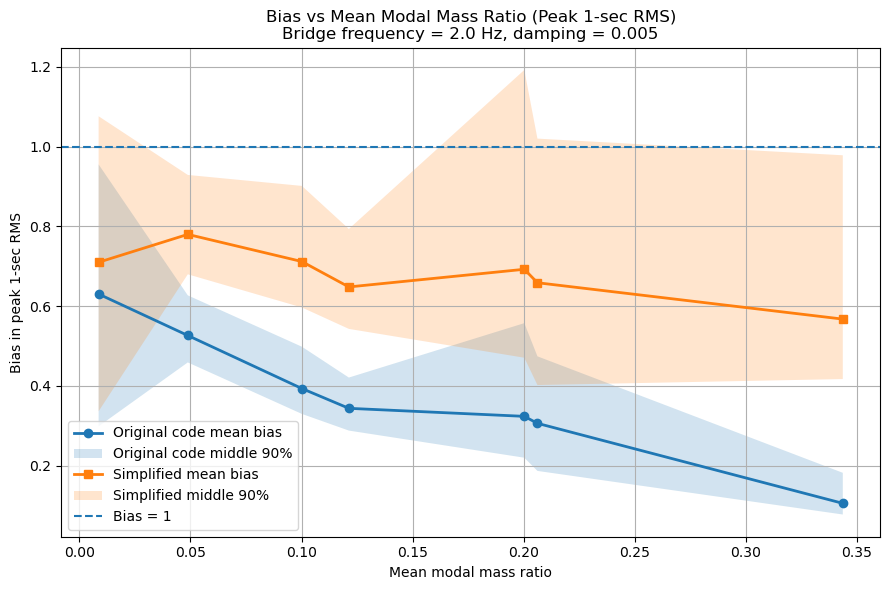

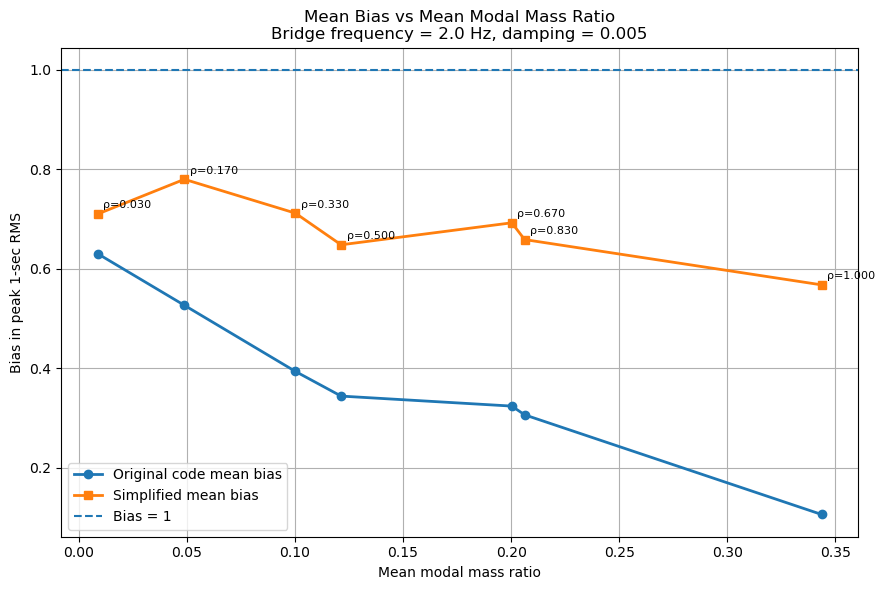

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_force_factor_exact_point
)

# ==================================================
# SETTINGS
# ==================================================
NUM_SIMULATIONS = 10
NUM_PROCESSES = 10
response_measure = "peak_rms"
hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

# fixed bridge properties
target_bf = 2.0
target_beamdamp = 0.005

# MC input
BeamFreq = np.array([target_bf, 8.0])   # keep same style as your current MC
Beamdamp = np.array([target_beamdamp])

Length = 50.0
Width = 2.0

densities = [0.0333, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0]

# choose which response measure to use for bias
# options:
#   "peak_rms"
#   "peak_abs"
#   "p95_acc"


# ==================================================
# LOAD FORCE-FACTOR DATABASE
# ==================================================
with open("forcefactors_bridgeF_bridgedamp.pkl", "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

# ==================================================
# STORAGE
# ==================================================
mass_ratio_x = []
density_used_list = []

code_mean = []
code_p5 = []
code_p95 = []

simp_mean = []
simp_p5 = []
simp_p95 = []

eps = 1e-12

# ==================================================
# LOOP OVER DENSITIES
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for density in densities:
            print(f"\nRunning density = {density:.4f}")

            # ------------------------------------------
            # Convert target density to integer pedestrian counts
            # ------------------------------------------
            total_peds_float = density * Length * Width
            total_peds_int = int(round(total_peds_float))

            # keep at least 1 pedestrian if density is nonzero
            total_peds_int = max(1, total_peds_int)

            # split pedestrians between two directions
            Tocity = total_peds_int // 2
            Outcity = total_peds_int - Tocity

            # actual density after integer rounding
            actual_density = (Tocity + Outcity) / (Length * Width)

            print(f"  target density = {density:.4f}")
            print(f"  total pedestrians = {total_peds_int}")
            print(f"  Tocity = {Tocity}, Outcity = {Outcity}")
            print(f"  actual density = {actual_density:.4f}")
            
            actual_density = (Tocity + Outcity) / (Length * Width)

            seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

            args_list = [
                (
                    int(seeds[i]),
                    peddamp,
                    pedBodyF,
                    BeamFreq,
                    Beamdamp,
                    Tocity,
                    Outcity,
                    Length,
                    Width
                )
                for i in range(NUM_SIMULATIONS)
            ]

            results = pool.map(run_simulation, args_list)

            # ------------------------------------------
            # Extract MC outputs
            # ------------------------------------------
            accelerations = np.array([r[0] for r in results])
            mean_mass_ratios = np.array([r[1] for r in results])

            overall_mean_mass_ratio = np.mean(mean_mass_ratios)

            # steady-state trimming
            steady_start_idx = int(round(steady_start_time / hht))
            accelerations_ss = accelerations[:, steady_start_idx:]

            # reference distributions
            rms_histories, peak_rms_values = peak_rms_distribution(
                accelerations_ss,
                dt=hht,
                window_sec=1.0
            )

            acc_95_values = percentile_acc_distribution(
                accelerations_ss,
                percentile=95,
                use_abs=True
            )

            peak_abs_acc_values = peak_abs_acc_distribution(
                accelerations_ss
            )

            # choose reference scalar distribution
            if response_measure == "peak_rms":
                Y_ref = peak_rms_values
                scalar_key = "peak_1sec_rms"
                y_label = "Bias in peak 1-sec RMS"
                plot_title = "Bias vs Mean Modal Mass Ratio (Peak 1-sec RMS)"
            elif response_measure == "peak_abs":
                Y_ref = peak_abs_acc_values
                scalar_key = "peak_abs_acc"
                y_label = "Bias in peak absolute acceleration"
                plot_title = "Bias vs Mean Modal Mass Ratio (Peak Absolute Acceleration)"
            elif response_measure == "p95_acc":
                Y_ref = acc_95_values
                scalar_key = "p95_abs_acc"
                y_label = "Bias in 95% acceleration"
                plot_title = "Bias vs Mean Modal Mass Ratio (95% Acceleration)"
            else:
                raise ValueError("Unknown response_measure")

            # ------------------------------------------
            # Original code model
            # ------------------------------------------
            t_end = accelerations.shape[1] * hht

            code_result, code_measures = run_code_response_from_mc_inputs(
                Tocity=Tocity,
                Outcity=Outcity,
                Length=Length,
                Width=Width,
                BeamFreq=BeamFreq,
                Beamdamp=Beamdamp,
                linear_mass=linear_mass,
                hht=hht,
                t_end=t_end,
                mean_mass_ratio=overall_mean_mass_ratio,
                mass_ratio_limit=0.05,
                steady_start_time=steady_start_time,
                numbers=1,
                modify_both_modes=False
            )

           # --------------------------------------------------
            # Cap mass ratio to interpolation database range
            # --------------------------------------------------
            mc_mass_ratio = float(overall_mean_mass_ratio)

            if mc_mass_ratio < 0.0089:
                target_mass_ratio_used = 0.0090
            elif mc_mass_ratio > 0.2954:
                target_mass_ratio_used = 0.29
            else:
                target_mass_ratio_used = mc_mass_ratio

            print("MC mean mass ratio       =", mc_mass_ratio)
            print("Mass ratio used for x    =", target_mass_ratio_used)

            x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
                results_all=ff_results_all,
                target_bf=target_bf,
                target_beamdamp=target_beamdamp,
                target_mass_ratio=target_mass_ratio_used,
                damping_values=ff_damping_values,
                densities=ff_densities,
                bridge_frequencies=ff_bridge_frequencies,
                pedBodyF=ff_pedBodyF
            )

            Tocity_simplified = Tocity * x_factor
            Outcity_simplified = Outcity * x_factor

            simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                Tocity=Tocity_simplified,
                Outcity=Outcity_simplified,
                Length=Length,
                Width=Width,
                BeamFreq=BeamFreq,
                Beamdamp=Beamdamp,
                linear_mass=linear_mass,
                hht=hht,
                t_end=t_end,
                mean_mass_ratio=target_mass_ratio_used,
                mass_ratio_limit=0.05,
                steady_start_time=steady_start_time,
                numbers=1,
                modify_both_modes=False
            )

            # ------------------------------------------
            # Bias distributions
            # ------------------------------------------
            B_code = Y_ref / max(code_measures[scalar_key], eps)
            B_simp = Y_ref / max(simplified_measures[scalar_key], eps)

            # ------------------------------------------
            # Store summaries
            # ------------------------------------------
            mass_ratio_x.append(overall_mean_mass_ratio)
            density_used_list.append(actual_density)

            code_mean.append(np.mean(B_code))
            code_p5.append(np.percentile(B_code, 5))
            code_p95.append(np.percentile(B_code, 95))

            simp_mean.append(np.mean(B_simp))
            simp_p5.append(np.percentile(B_simp, 5))
            simp_p95.append(np.percentile(B_simp, 95))

            print(f"  mean mass ratio = {overall_mean_mass_ratio:.4f}")
            print(f"  code mean bias  = {np.mean(B_code):.4f}")
            print(f"  simp mean bias  = {np.mean(B_simp):.4f}")

    # ==================================================
    # SORT BY MASS RATIO
    # ==================================================
    mass_ratio_x = np.array(mass_ratio_x)
    density_used_list = np.array(density_used_list)

    code_mean = np.array(code_mean)
    code_p5 = np.array(code_p5)
    code_p95 = np.array(code_p95)

    simp_mean = np.array(simp_mean)
    simp_p5 = np.array(simp_p5)
    simp_p95 = np.array(simp_p95)

    sort_idx = np.argsort(mass_ratio_x)

    mr_plot = mass_ratio_x[sort_idx]
    density_plot = density_used_list[sort_idx]

    code_mean = code_mean[sort_idx]
    code_p5 = code_p5[sort_idx]
    code_p95 = code_p95[sort_idx]

    simp_mean = simp_mean[sort_idx]
    simp_p5 = simp_p5[sort_idx]
    simp_p95 = simp_p95[sort_idx]

    # ==================================================
    # PLOT: bias vs mass ratio with 5%-95% error bars
    # ==================================================

    # asymmetric error bars
    code_yerr = np.vstack([
        code_mean - code_p5,      # lower error
        code_p95 - code_mean      # upper error
    ])

    simp_yerr = np.vstack([
        simp_mean - simp_p5,
        simp_p95 - simp_mean
    ])

    plt.figure(figsize=(9, 6))

# Original code model
    plt.errorbar(
        mr_plot,
        code_mean,
        yerr=code_yerr,
        marker="o",
        linestyle="-",
        linewidth=2,
        capsize=5,
        label="Original code mean bias, 5%-95%"
    )

    # Simplified model
    plt.errorbar(
        mr_plot,
        simp_mean,
        yerr=simp_yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=5,
        label="Simplified mean bias, 5%-95%"
    )

    plt.axhline(
        1.0,
        linestyle="--",
        linewidth=1.5,
        label="Bias = 1"
    )

    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"{plot_title}\n"
        f"Bridge frequency = {target_bf} Hz, damping = {target_beamdamp}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ==================================================
    # OPTIONAL: label density values on the plot
    # ==================================================
    plt.figure(figsize=(9, 6))

    plt.plot(mr_plot, code_mean, marker="o", linewidth=2, label="Original code mean bias")
    plt.plot(mr_plot, simp_mean, marker="s", linewidth=2, label="Simplified mean bias")

    for x, y, rho in zip(mr_plot, simp_mean, density_plot):
        plt.annotate(f"ρ={rho:.3f}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Mean Bias vs Mean Modal Mass Ratio\n"
        f"Bridge frequency = {target_bf} Hz, damping = {target_beamdamp}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

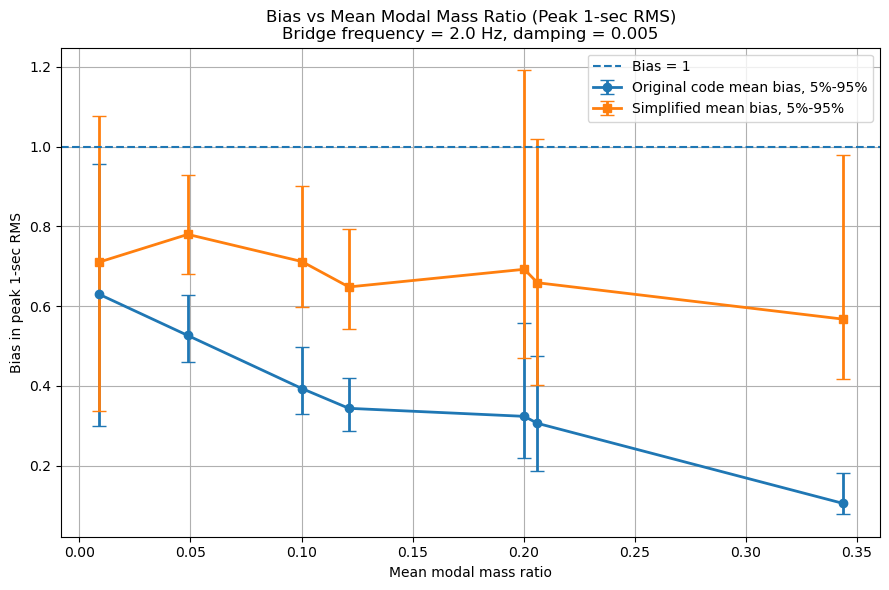

In [27]:
# ==================================================
# PLOT: bias vs mass ratio with 5%-95% error bars
# ==================================================

# asymmetric error bars
code_yerr = np.vstack([
    code_mean - code_p5,      # lower error
    code_p95 - code_mean      # upper error
])

simp_yerr = np.vstack([
    simp_mean - simp_p5,
    simp_p95 - simp_mean
])

plt.figure(figsize=(9, 6))

# Original code model
plt.errorbar(
    mr_plot,
    code_mean,
    yerr=code_yerr,
    marker="o",
    linestyle="-",
    linewidth=2,
    capsize=5,
    label="Original code mean bias, 5%-95%"
)

# Simplified model
plt.errorbar(
    mr_plot,
    simp_mean,
    yerr=simp_yerr,
    marker="s",
    linestyle="-",
    linewidth=2,
    capsize=5,
    label="Simplified mean bias, 5%-95%"
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Bias = 1"
)

plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"{plot_title}\n"
    f"Bridge frequency = {target_bf} Hz, damping = {target_beamdamp}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Loaded force-factor database.
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

RUNNING BRIDGE FREQUENCY = 1.5 Hz

Running density = 0.0333
  total pedestrians = 3
  Tocity = 1, Outcity = 2
  actual density = 0.0300
  MC mean mass ratio       = 0.0085
  mass ratio used for x    = 0.0090

--- Simplified density factor rule ---
Bridge frequency      = 1.5
Interpolated x factor = 0.9227060217632509
Factor applied?       = True
Density factor used   = 0.9227060217632509

fb = 1.500 Hz | density target = 0.0333
  actual density       = 0.0300
  mean modal mass ratio = 0.0085
  code mean bias        = 0.1506
  simplified mean bias  = 0.1568

Running density = 0.1667
  total pedestrians = 17
  Tocity = 8, Outcity = 9
  actual density = 0.1700
  MC mean mass ratio       = 0.0479
  mass ratio used for x    = 0.0479

--- Simplified density factor rule ---
Bridge frequency      = 1.5
Interpolated x factor = 0.7192587911640902
Factor applied?       = True
Density factor used   = 0

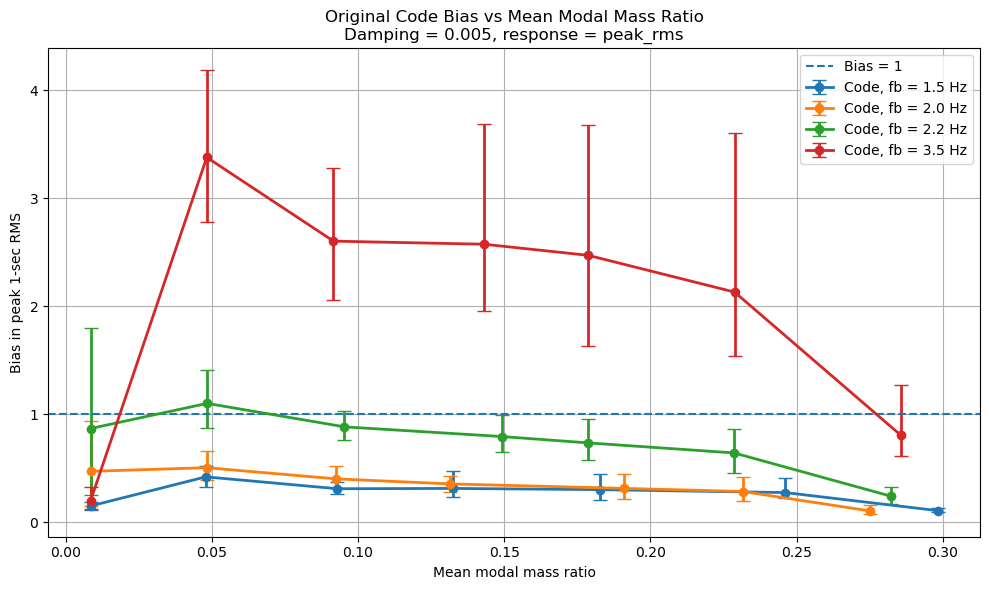

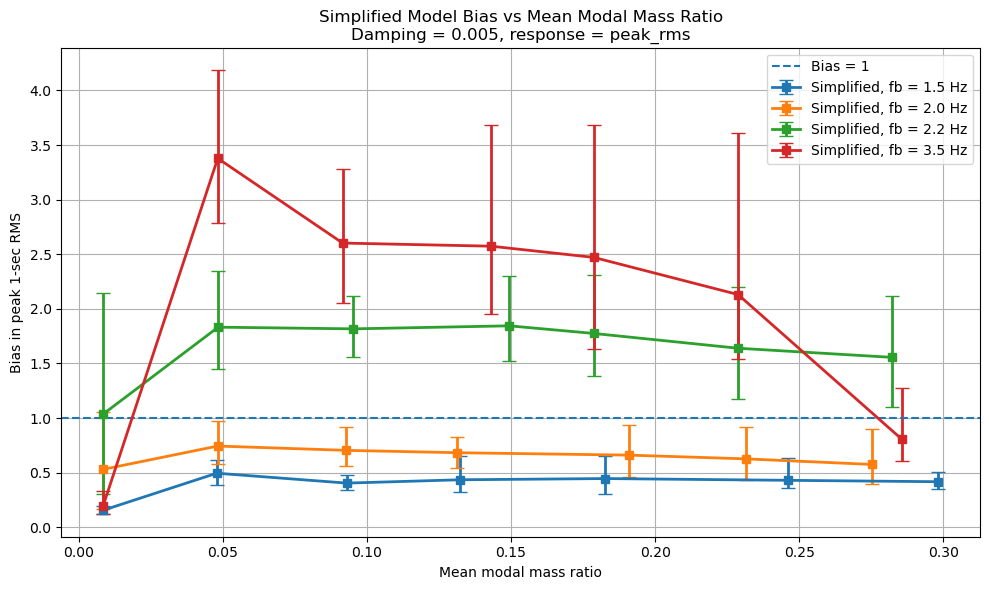

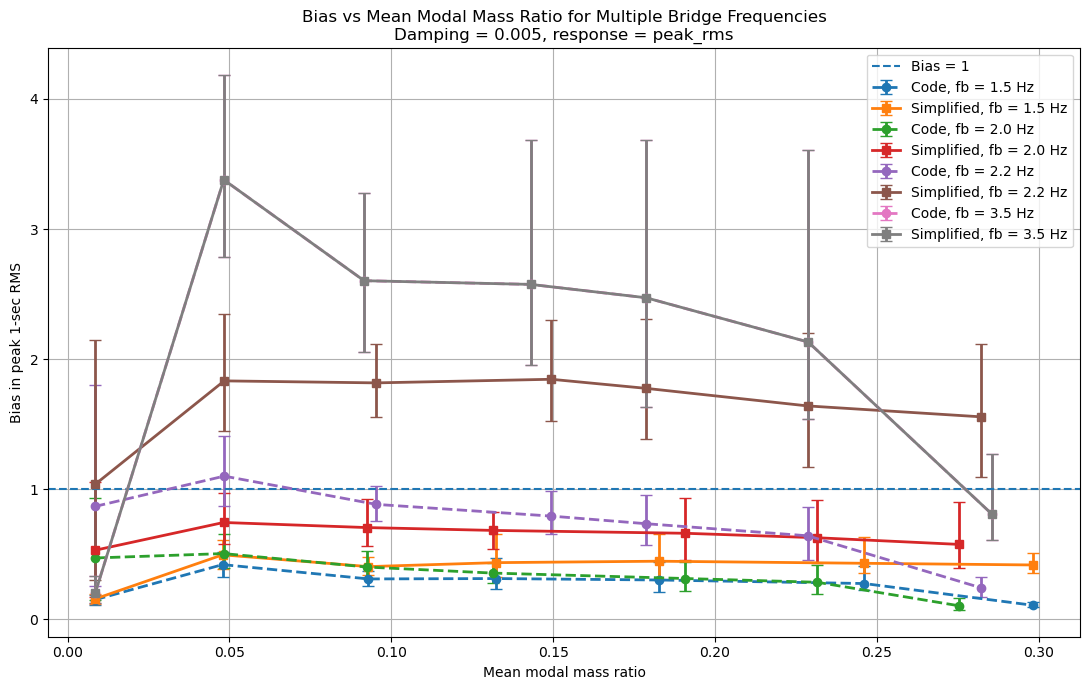

In [ ]:
# ==================================================
# FULL WORKFLOW:
# Bias vs mean modal mass ratio
# for multiple bridge frequencies
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_force_factor_exact_point
)

# ==================================================
# SETTINGS
# ==================================================

NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Bridge frequencies you want to study
bridge_frequencies_to_run = [1.5, 2.0, 2.2, 3.5]

# Fixed damping ratio for this study
target_beamdamp = 0.005

# Density cases
densities = [0.0333, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0]

# Choose response measure:
# "peak_rms" = peak 1-sec RMS
# "peak_abs" = peak absolute acceleration
# "p95_acc"  = 95th percentile absolute acceleration
response_measure = "peak_rms"

# Force-factor database
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29

eps = 1e-12


# ==================================================
# RESPONSE MEASURE SETTINGS
# ==================================================

measure_specs = {
    "peak_rms": {
        "scalar_key": "peak_1sec_rms",
        "y_label": "Bias in peak 1-sec RMS",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak 1-sec RMS)"
    },
    "peak_abs": {
        "scalar_key": "peak_abs_acc",
        "y_label": "Bias in peak absolute acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak Absolute Acceleration)"
    },
    "p95_acc": {
        "scalar_key": "p95_abs_acc",
        "y_label": "Bias in 95% acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (95% Acceleration)"
    }
}

if response_measure not in measure_specs:
    raise ValueError("response_measure must be 'peak_rms', 'peak_abs', or 'p95_acc'")

scalar_key = measure_specs[response_measure]["scalar_key"]
y_label = measure_specs[response_measure]["y_label"]
plot_title = measure_specs[response_measure]["plot_title"]


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    """
    Keep mass ratio inside interpolation database range.
    """
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


def print_case_summary(target_bf, density, actual_density, mr, B_code, B_simp):
    print(f"\nfb = {target_bf:.3f} Hz | density target = {density:.4f}")
    print(f"  actual density       = {actual_density:.4f}")
    print(f"  mean modal mass ratio = {mr:.4f}")
    print(f"  code mean bias        = {np.mean(B_code):.4f}")
    print(f"  simplified mean bias  = {np.mean(B_simp):.4f}")


# ==================================================
# LOAD FORCE-FACTOR DATABASE
# ==================================================

with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

print("Loaded force-factor database.")
print("Available damping values:", ff_damping_values)


# ==================================================
# MAIN LOOP
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_by_freq = {}

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_bf in bridge_frequencies_to_run:

            print("\n" + "=" * 80)
            print(f"RUNNING BRIDGE FREQUENCY = {target_bf} Hz")
            print("=" * 80)

            BeamFreq = np.array([target_bf, 4*target_bf])
            Beamdamp = np.array([target_beamdamp])

            # storage for this bridge frequency
            mass_ratio_x = []
            density_used_list = []

            code_mean = []
            code_p5 = []
            code_p95 = []

            simp_mean = []
            simp_p5 = []
            simp_p95 = []

            for density in densities:

                # --------------------------------------------------
                # Convert density to integer pedestrian counts
                # --------------------------------------------------
                total_peds_float = density * Length * Width
                total_peds_int = int(round(total_peds_float))
                total_peds_int = max(1, total_peds_int)

                Tocity = total_peds_int // 2
                Outcity = total_peds_int - Tocity

                actual_density = (Tocity + Outcity) / (Length * Width)

                print(f"\nRunning density = {density:.4f}")
                print(f"  total pedestrians = {total_peds_int}")
                print(f"  Tocity = {Tocity}, Outcity = {Outcity}")
                print(f"  actual density = {actual_density:.4f}")

                # --------------------------------------------------
                # Run MC reference system
                # --------------------------------------------------
                seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                args_list = [
                    (
                        int(seeds[i]),
                        peddamp,
                        pedBodyF,
                        BeamFreq,
                        Beamdamp,
                        Tocity,
                        Outcity,
                        Length,
                        Width
                    )
                    for i in range(NUM_SIMULATIONS)
                ]

                results = pool.map(run_simulation, args_list)

                accelerations = np.array([r[0] for r in results])
                mean_mass_ratios = np.array([r[1] for r in results])

                overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                # --------------------------------------------------
                # Trim first 10 seconds
                # --------------------------------------------------
                steady_start_idx = int(round(steady_start_time / hht))

                if steady_start_idx >= accelerations.shape[1]:
                    raise ValueError("steady_start_time is longer than acceleration time history.")

                accelerations_ss = accelerations[:, steady_start_idx:]

                # --------------------------------------------------
                # MC response distributions
                # --------------------------------------------------
                rms_histories, peak_rms_values = peak_rms_distribution(
                    accelerations_ss,
                    dt=hht,
                    window_sec=1.0
                )

                acc_95_values = percentile_acc_distribution(
                    accelerations_ss,
                    percentile=95,
                    use_abs=True
                )

                peak_abs_acc_values = peak_abs_acc_distribution(
                    accelerations_ss
                )

                if response_measure == "peak_rms":
                    Y_ref = peak_rms_values
                elif response_measure == "peak_abs":
                    Y_ref = peak_abs_acc_values
                elif response_measure == "p95_acc":
                    Y_ref = acc_95_values
                else:
                    raise ValueError("Unknown response_measure")

                # --------------------------------------------------
                # Original deterministic/code model
                # --------------------------------------------------
                t_end = accelerations.shape[1] * hht

                code_result, code_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False
                )

                # --------------------------------------------------
                # Interpolate force factor x for simplified model
                # --------------------------------------------------
                target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                    overall_mean_mass_ratio
                )

                print(f"  MC mean mass ratio       = {overall_mean_mass_ratio:.4f}")
                print(f"  mass ratio used for x    = {target_mass_ratio_used:.4f}")

                x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
                    results_all=ff_results_all,
                    target_bf=target_bf,
                    target_beamdamp=target_beamdamp,
                    target_mass_ratio=target_mass_ratio_used,
                    damping_values=ff_damping_values,
                    densities=ff_densities,
                    bridge_frequencies=ff_bridge_frequencies,
                    pedBodyF=ff_pedBodyF
                )

                # --------------------------------------------------
                # Simplified model
                # Apply density reduction factor x only if bridge frequency
                # is within 1.25 Hz to 2.30 Hz.
                # Otherwise, use original density.
                # --------------------------------------------------

                if 1.25 <= target_bf <= 2.30:
                    density_factor_used = x_factor
                    factor_applied = True
                else:
                    density_factor_used = 1.0
                    factor_applied = False

                Tocity_simplified = Tocity * density_factor_used
                Outcity_simplified = Outcity * density_factor_used

                print("\n--- Simplified density factor rule ---")
                print("Bridge frequency      =", target_bf)
                print("Interpolated x factor =", x_factor)
                print("Factor applied?       =", factor_applied)
                print("Density factor used   =", density_factor_used)

                simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity_simplified,
                    Outcity=Outcity_simplified,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=target_mass_ratio_used,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False
                )

                # --------------------------------------------------
                # Bias distributions
                # --------------------------------------------------
                B_code = Y_ref / max(code_measures[scalar_key], eps)
                B_simp = Y_ref / max(simplified_measures[scalar_key], eps)

                # --------------------------------------------------
                # Store summary statistics
                # --------------------------------------------------
                mass_ratio_x.append(overall_mean_mass_ratio)
                density_used_list.append(actual_density)

                code_mean.append(np.mean(B_code))
                code_p5.append(np.percentile(B_code, 5))
                code_p95.append(np.percentile(B_code, 95))

                simp_mean.append(np.mean(B_simp))
                simp_p5.append(np.percentile(B_simp, 5))
                simp_p95.append(np.percentile(B_simp, 95))

                print_case_summary(
                    target_bf,
                    density,
                    actual_density,
                    overall_mean_mass_ratio,
                    B_code,
                    B_simp
                )

            # --------------------------------------------------
            # Sort results by mass ratio for this bridge frequency
            # --------------------------------------------------
            mass_ratio_x = np.asarray(mass_ratio_x)
            density_used_list = np.asarray(density_used_list)

            code_mean = np.asarray(code_mean)
            code_p5 = np.asarray(code_p5)
            code_p95 = np.asarray(code_p95)

            simp_mean = np.asarray(simp_mean)
            simp_p5 = np.asarray(simp_p5)
            simp_p95 = np.asarray(simp_p95)

            sort_idx = np.argsort(mass_ratio_x)

            summary_by_freq[target_bf] = {
                "mass_ratio": mass_ratio_x[sort_idx],
                "density": density_used_list[sort_idx],

                "code_mean": code_mean[sort_idx],
                "code_p5": code_p5[sort_idx],
                "code_p95": code_p95[sort_idx],

                "simp_mean": simp_mean[sort_idx],
                "simp_p5": simp_p5[sort_idx],
                "simp_p95": simp_p95[sort_idx],
            }

    # ==================================================
    # SAVE SUMMARY RESULTS
    # ==================================================

    save_summary = {
        "summary_by_freq": summary_by_freq,
        "bridge_frequencies_to_run": bridge_frequencies_to_run,
        "target_beamdamp": target_beamdamp,
        "densities": densities,
        "response_measure": response_measure,
        "NUM_SIMULATIONS": NUM_SIMULATIONS,
        "steady_start_time": steady_start_time,
        "Length": Length,
        "Width": Width,
    }

    with open("bias_vs_mass_ratio_multi_frequency.pkl", "wb") as f:
        pickle.dump(save_summary, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary to bias_vs_mass_ratio_multi_frequency.pkl")

    # ==================================================
    # PLOT 1: ORIGINAL CODE MODEL FOR ALL FREQUENCIES
    # ==================================================

    plt.figure(figsize=(10, 6))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]
        mean = data["code_mean"]
        p5 = data["code_p5"]
        p95 = data["code_p95"]

        yerr = np.vstack([
            mean - p5,
            p95 - mean
        ])

        plt.errorbar(
            mr_plot,
            mean,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=2,
            capsize=5,
            label=f"Code, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Original Code Bias vs Mean Modal Mass Ratio\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOT 2: SIMPLIFIED MODEL FOR ALL FREQUENCIES
    # ==================================================

    plt.figure(figsize=(10, 6))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]
        mean = data["simp_mean"]
        p5 = data["simp_p5"]
        p95 = data["simp_p95"]

        yerr = np.vstack([
            mean - p5,
            p95 - mean
        ])

        plt.errorbar(
            mr_plot,
            mean,
            yerr=yerr,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=5,
            label=f"Simplified, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Simplified Model Bias vs Mean Modal Mass Ratio\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOT 3: CODE AND SIMPLIFIED TOGETHER
    # ==================================================

    plt.figure(figsize=(11, 7))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]

        code_mean = data["code_mean"]
        code_p5 = data["code_p5"]
        code_p95 = data["code_p95"]

        simp_mean = data["simp_mean"]
        simp_p5 = data["simp_p5"]
        simp_p95 = data["simp_p95"]

        code_yerr = np.vstack([
            code_mean - code_p5,
            code_p95 - code_mean
        ])

        simp_yerr = np.vstack([
            simp_mean - simp_p5,
            simp_p95 - simp_mean
        ])

        plt.errorbar(
            mr_plot,
            code_mean,
            yerr=code_yerr,
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            label=f"Code, fb = {target_bf} Hz"
        )

        plt.errorbar(
            mr_plot,
            simp_mean,
            yerr=simp_yerr,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=4,
            label=f"Simplified, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Bias vs Mean Modal Mass Ratio for Multiple Bridge Frequencies\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

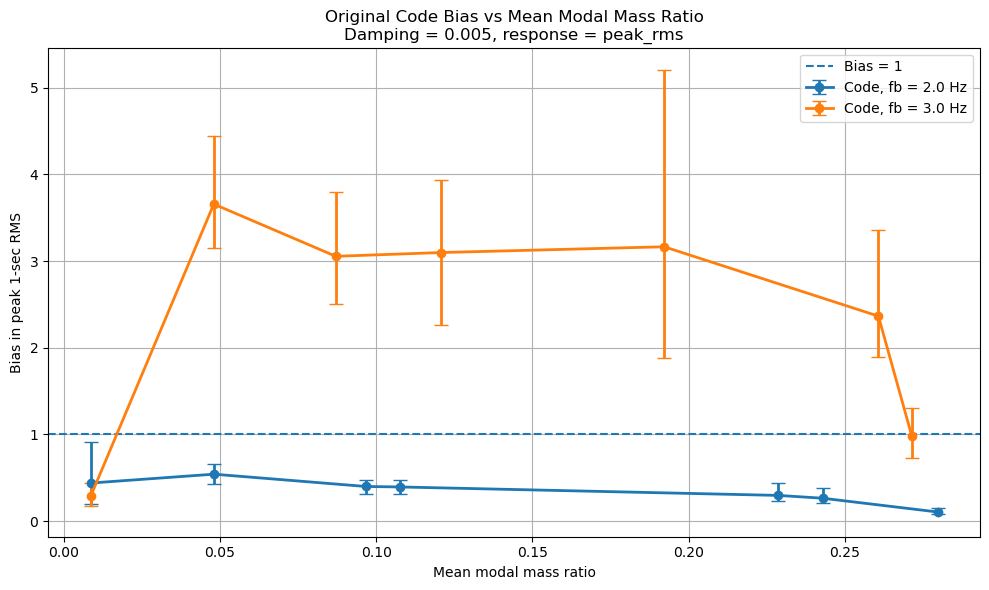

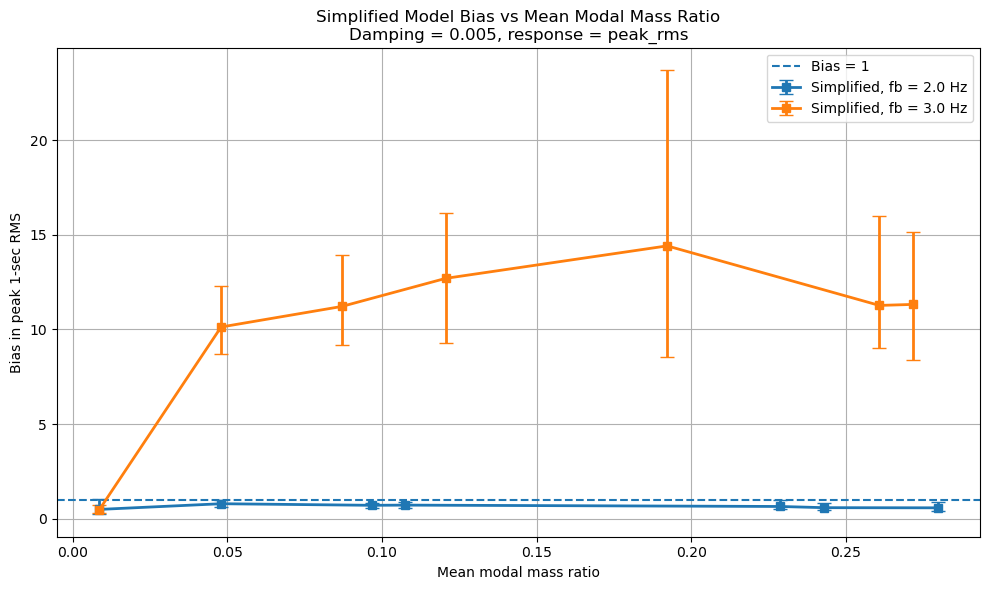

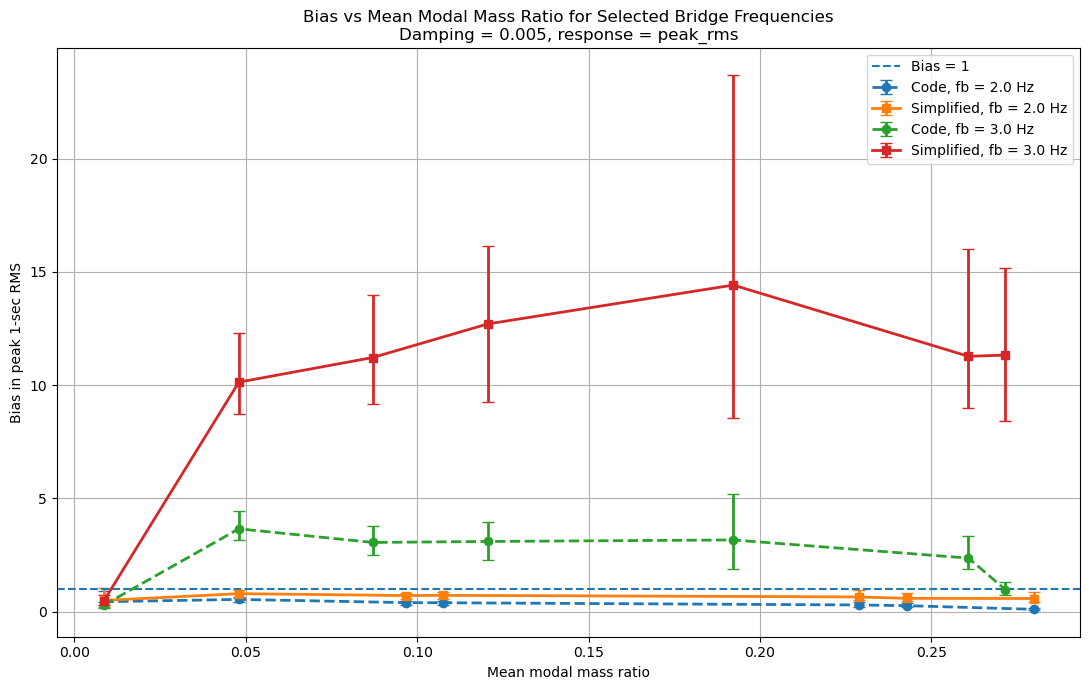

In [29]:
# Only plot these bridge frequencies
bridge_frequencies_to_plot = [2.0, 3.0]

# ==================================================
# PLOT 1: ORIGINAL CODE MODEL FOR SELECTED FREQUENCIES
# ==================================================

plt.figure(figsize=(10, 6))

for target_bf in bridge_frequencies_to_plot:

    data = summary_by_freq[target_bf]

    mr_plot = data["mass_ratio"]
    mean = data["code_mean"]
    p5 = data["code_p5"]
    p95 = data["code_p95"]

    yerr = np.vstack([
        mean - p5,
        p95 - mean
    ])

    plt.errorbar(
        mr_plot,
        mean,
        yerr=yerr,
        marker="o",
        linestyle="-",
        linewidth=2,
        capsize=5,
        label=f"Code, fb = {target_bf} Hz"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"Original Code Bias vs Mean Modal Mass Ratio\n"
    f"Damping = {target_beamdamp}, response = {response_measure}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 2: SIMPLIFIED MODEL FOR SELECTED FREQUENCIES
# ==================================================

plt.figure(figsize=(10, 6))

for target_bf in bridge_frequencies_to_plot:

    data = summary_by_freq[target_bf]

    mr_plot = data["mass_ratio"]
    mean = data["simp_mean"]
    p5 = data["simp_p5"]
    p95 = data["simp_p95"]

    yerr = np.vstack([
        mean - p5,
        p95 - mean
    ])

    plt.errorbar(
        mr_plot,
        mean,
        yerr=yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=5,
        label=f"Simplified, fb = {target_bf} Hz"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"Simplified Model Bias vs Mean Modal Mass Ratio\n"
    f"Damping = {target_beamdamp}, response = {response_measure}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 3: CODE AND SIMPLIFIED TOGETHER FOR SELECTED FREQUENCIES
# ==================================================

plt.figure(figsize=(11, 7))

for target_bf in bridge_frequencies_to_plot:

    data = summary_by_freq[target_bf]

    mr_plot = data["mass_ratio"]

    code_mean = data["code_mean"]
    code_p5 = data["code_p5"]
    code_p95 = data["code_p95"]

    simp_mean = data["simp_mean"]
    simp_p5 = data["simp_p5"]
    simp_p95 = data["simp_p95"]

    code_yerr = np.vstack([
        code_mean - code_p5,
        code_p95 - code_mean
    ])

    simp_yerr = np.vstack([
        simp_mean - simp_p5,
        simp_p95 - simp_mean
    ])

    plt.errorbar(
        mr_plot,
        code_mean,
        yerr=code_yerr,
        marker="o",
        linestyle="--",
        linewidth=2,
        capsize=4,
        label=f"Code, fb = {target_bf} Hz"
    )

    plt.errorbar(
        mr_plot,
        simp_mean,
        yerr=simp_yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=4,
        label=f"Simplified, fb = {target_bf} Hz"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"Bias vs Mean Modal Mass Ratio for Selected Bridge Frequencies\n"
    f"Damping = {target_beamdamp}, response = {response_measure}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import importlib
import bias
import biascodefunction
import solver
import pedestrian

# Reload lower-level modules first
importlib.reload(pedestrian)
importlib.reload(solver)

# Reload modules that depend on them
importlib.reload(biascodefunction)
importlib.reload(bias)

# Reassign functions after reload
run_simulation = bias.run_simulation

peak_rms_distribution = biascodefunction.peak_rms_distribution
percentile_acc_distribution = biascodefunction.percentile_acc_distribution
peak_abs_acc_distribution = biascodefunction.peak_abs_acc_distribution
run_code_response_from_mc_inputs = biascodefunction.run_code_response_from_mc_inputs
interpolate_force_factor_exact_point = biascodefunction.interpolate_force_factor_exact_point

print("Reloaded:")
print("bias:", bias.__file__)
print("biascodefunction:", biascodefunction.__file__)
print("solver:", solver.__file__)
print("pedestrian:", pedestrian.__file__)



Reloaded:
bias: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\bias.py
biascodefunction: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\biascodefunction.py
solver: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\solver.py
pedestrian: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\pedestrian.py


In [15]:
import importlib
import inspect
import pedestrian

importlib.reload(pedestrian)

print("Using pedestrian.py from:")
print(pedestrian.__file__)

print("\n--- psi_w_h1_modified loaded? ---")
print(hasattr(pedestrian, "psi_w_h1_modified"))

if hasattr(pedestrian, "psi_w_h1_modified"):
    print(inspect.getsource(pedestrian.psi_w_h1_modified))

print("\n--- force_2harm psi-selection block ---")
src = inspect.getsource(pedestrian.force_2harm)

for line in src.splitlines():
    if "psi_w_h1" in line or "isclose" in line or "rf" in line:
        print(line)

Using pedestrian.py from:
\\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\pedestrian.py

--- psi_w_h1_modified loaded? ---
True
def psi_w_h1_modified(x):
    """
    Modified psi function used only when force reduction factor rf != 1.

    Shape:
    - 1.25–1.70 : 0 -> 1
    - 1.70–2.30 : 1
    - 2.30–2.50 : 1 -> 0
    - otherwise : 0
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.30 : 1
    m = (x >= 1.70) & (x <= 2.30)
    psi[m] = 1.0

    # 2.30–2.50 : 1 -> 0
    m = (x > 2.30) & (x <= 2.50)
    psi[m] = 1.0 - (x[m] - 2.30) / (2.50 - 2.30)

    return psi


--- force_2harm psi-selection block ---
def force_2harm(t, x, density, xi, S, phase=(0.0, 0.0), rf=1.0):
    rf = float(rf)
    if np.isclose(rf, 1.0):
        psi1 = psi_w_h1(x)              # original psi
        psi1 = psi_w_h1_modified(x)     # modified psi for reduced-forc

Loaded force-factor database.
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

RUNNING BRIDGE FREQUENCY = 1.5 Hz

Running density = 0.0333
  total pedestrians = 3
  Tocity = 1, Outcity = 2
  actual density = 0.0300
  MC mean mass ratio       = 0.0085
  mass ratio used for x    = 0.0090

--- Simplified direct force factor rule ---
Bridge frequency              = 1.5
Interpolated x factor          = 0.9227060217632509
Force reduction factor used    = 0.9227060217632509
Density kept unchanged?        = True

fb = 1.500 Hz | density target = 0.0333
  actual density       = 0.0300
  mean modal mass ratio = 0.0085
  code mean bias        = 0.1475
  simplified mean bias  = 0.1598

Running density = 0.1667
  total pedestrians = 17
  Tocity = 8, Outcity = 9
  actual density = 0.1700
  MC mean mass ratio       = 0.0484
  mass ratio used for x    = 0.0484

--- Simplified direct force factor rule ---
Bridge frequency              = 1.5
Interpolated x factor          = 0.716572154

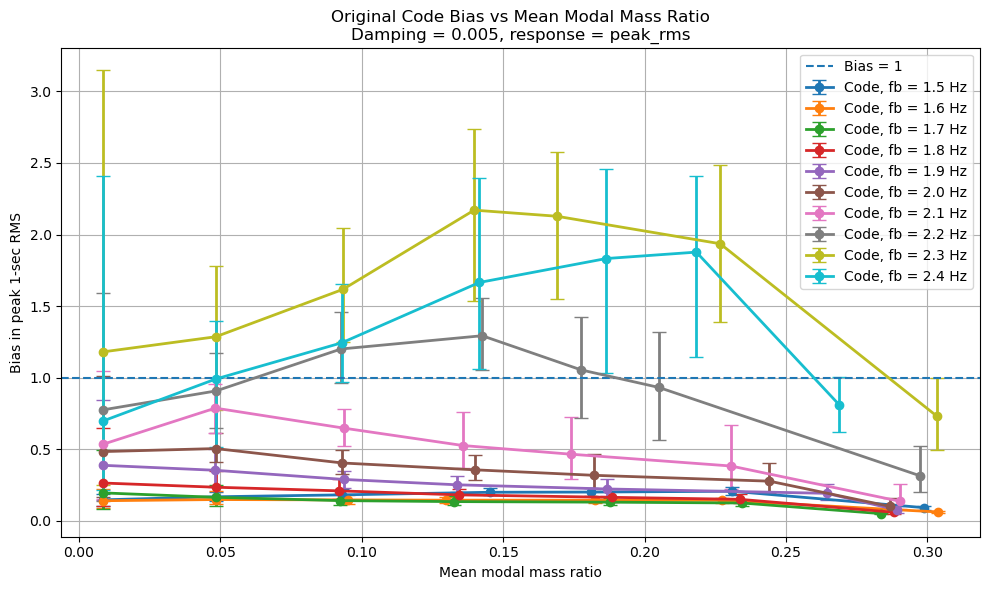

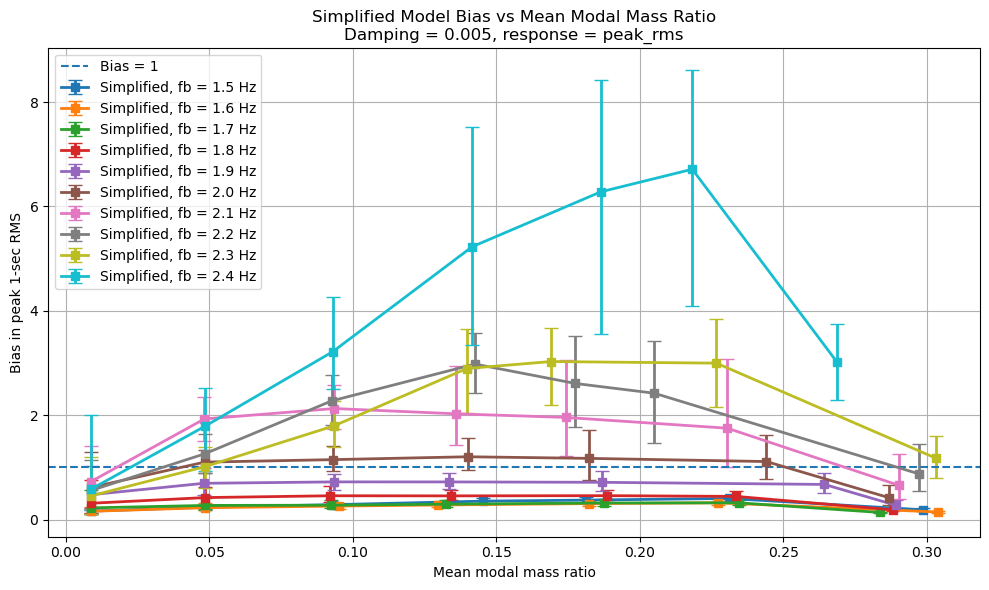

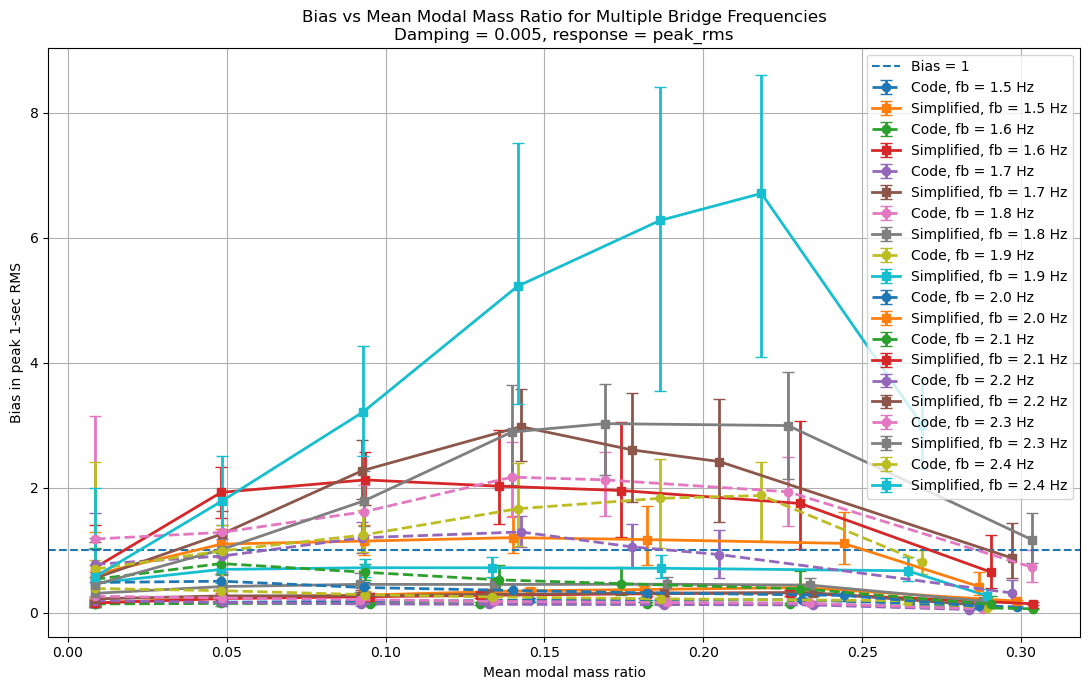

In [16]:
# ==================================================
# FULL WORKFLOW:
# Bias vs mean modal mass ratio
# for multiple bridge frequencies
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_force_factor_exact_point
)

# ==================================================
# SETTINGS
# ==================================================

NUM_SIMULATIONS = 100
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Bridge frequencies you want to study
bridge_frequencies_to_run = [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4]

# Fixed damping ratio for this study
target_beamdamp = 0.005

# Density cases
densities = [0.0333, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0 ] #0.8333, 1.0

# Choose response measure:
# "peak_rms" = peak 1-sec RMS
# "peak_abs" = peak absolute acceleration
# "p95_acc"  = 95th percentile absolute acceleration
response_measure = "peak_rms"

# Force-factor database
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29

eps = 1e-12


# ==================================================
# RESPONSE MEASURE SETTINGS
# ==================================================

measure_specs = {
    "peak_rms": {
        "scalar_key": "peak_1sec_rms",
        "y_label": "Bias in peak 1-sec RMS",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak 1-sec RMS)"
    },
    "peak_abs": {
        "scalar_key": "peak_abs_acc",
        "y_label": "Bias in peak absolute acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak Absolute Acceleration)"
    },
    "p95_acc": {
        "scalar_key": "p95_abs_acc",
        "y_label": "Bias in 95% acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (95% Acceleration)"
    }
}

if response_measure not in measure_specs:
    raise ValueError("response_measure must be 'peak_rms', 'peak_abs', or 'p95_acc'")

scalar_key = measure_specs[response_measure]["scalar_key"]
y_label = measure_specs[response_measure]["y_label"]
plot_title = measure_specs[response_measure]["plot_title"]


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    """
    Keep mass ratio inside interpolation database range.
    """
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


def print_case_summary(target_bf, density, actual_density, mr, B_code, B_simp):
    print(f"\nfb = {target_bf:.3f} Hz | density target = {density:.4f}")
    print(f"  actual density       = {actual_density:.4f}")
    print(f"  mean modal mass ratio = {mr:.4f}")
    print(f"  code mean bias        = {np.mean(B_code):.4f}")
    print(f"  simplified mean bias  = {np.mean(B_simp):.4f}")


# ==================================================
# LOAD FORCE-FACTOR DATABASE
# ==================================================

with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

print("Loaded force-factor database.")
print("Available damping values:", ff_damping_values)


# ==================================================
# MAIN LOOP
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_by_freq = {}

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_bf in bridge_frequencies_to_run:

            print("\n" + "=" * 80)
            print(f"RUNNING BRIDGE FREQUENCY = {target_bf} Hz")
            print("=" * 80)

            BeamFreq = np.array([target_bf, 4*target_bf])
            Beamdamp = np.array([target_beamdamp])

            # storage for this bridge frequency
            mass_ratio_x = []
            density_used_list = []

            code_mean = []
            code_p5 = []
            code_p95 = []

            simp_mean = []
            simp_p5 = []
            simp_p95 = []

            for density in densities:

                # --------------------------------------------------
                # Convert density to integer pedestrian counts
                # --------------------------------------------------
                total_peds_float = density * Length * Width
                total_peds_int = int(round(total_peds_float))
                total_peds_int = max(1, total_peds_int)

                Tocity = total_peds_int // 2
                Outcity = total_peds_int - Tocity

                actual_density = (Tocity + Outcity) / (Length * Width)

                print(f"\nRunning density = {density:.4f}")
                print(f"  total pedestrians = {total_peds_int}")
                print(f"  Tocity = {Tocity}, Outcity = {Outcity}")
                print(f"  actual density = {actual_density:.4f}")

                # --------------------------------------------------
                # Run MC reference system
                # --------------------------------------------------
                seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                args_list = [
                    (
                        int(seeds[i]),
                        peddamp,
                        pedBodyF,
                        BeamFreq,
                        Beamdamp,
                        Tocity,
                        Outcity,
                        Length,
                        Width
                    )
                    for i in range(NUM_SIMULATIONS)
                ]

                results = pool.map(run_simulation, args_list)

                accelerations = np.array([r[0] for r in results])
                mean_mass_ratios = np.array([r[1] for r in results])

                overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                # --------------------------------------------------
                # Trim first 10 seconds
                # --------------------------------------------------
                steady_start_idx = int(round(steady_start_time / hht))

                if steady_start_idx >= accelerations.shape[1]:
                    raise ValueError("steady_start_time is longer than acceleration time history.")

                accelerations_ss = accelerations[:, steady_start_idx:]

                # --------------------------------------------------
                # MC response distributions
                # --------------------------------------------------
                rms_histories, peak_rms_values = peak_rms_distribution(
                    accelerations_ss,
                    dt=hht,
                    window_sec=1.0
                )

                acc_95_values = percentile_acc_distribution(
                    accelerations_ss,
                    percentile=95,
                    use_abs=True
                )

                peak_abs_acc_values = peak_abs_acc_distribution(
                    accelerations_ss
                )

                if response_measure == "peak_rms":
                    Y_ref = peak_rms_values
                elif response_measure == "peak_abs":
                    Y_ref = peak_abs_acc_values
                elif response_measure == "p95_acc":
                    Y_ref = acc_95_values
                else:
                    raise ValueError("Unknown response_measure")

                # --------------------------------------------------
                # Original deterministic/code model
                # --------------------------------------------------
                t_end = accelerations.shape[1] * hht

                code_result, code_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False
                )

                # --------------------------------------------------
                # Interpolate force factor x for simplified model
                # --------------------------------------------------
                target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                    overall_mean_mass_ratio
                )

                print(f"  MC mean mass ratio       = {overall_mean_mass_ratio:.4f}")
                print(f"  mass ratio used for x    = {target_mass_ratio_used:.4f}")

                x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
                    results_all=ff_results_all,
                    target_bf=target_bf,
                    target_beamdamp=target_beamdamp,
                    target_mass_ratio=target_mass_ratio_used,
                    damping_values=ff_damping_values,
                    densities=ff_densities,
                    bridge_frequencies=ff_bridge_frequencies,
                    pedBodyF=ff_pedBodyF
                )

                # --------------------------------------------------
                # Simplified model
                # Apply direct force modification factor x.
                # Density and pedestrian count are kept unchanged.
                # --------------------------------------------------
                force_reduction_factor_used = x_factor               
                

                Tocity_simplified = Tocity 
                Outcity_simplified = Outcity 

                print("\n--- Simplified direct force factor rule ---")
                print("Bridge frequency              =", target_bf)
                print("Interpolated x factor          =", x_factor)
                print("Force reduction factor used    =", force_reduction_factor_used)
                print("Density kept unchanged?        =", True)

                simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity_simplified,
                    Outcity=Outcity_simplified,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=0.0,# overall_mean_mass_ratio, # Use zero here since we're applying the force reduction factor directly, instead of modifying the mass ratio.
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=force_reduction_factor_used
                )

                # --------------------------------------------------
                # Bias distributions
                # --------------------------------------------------
                B_code = Y_ref / max(code_measures[scalar_key], eps)
                B_simp = Y_ref / max(simplified_measures[scalar_key], eps)

                # --------------------------------------------------
                # Store summary statistics
                # --------------------------------------------------
                mass_ratio_x.append(overall_mean_mass_ratio)
                density_used_list.append(actual_density)

                code_mean.append(np.mean(B_code))
                code_p5.append(np.percentile(B_code, 5))
                code_p95.append(np.percentile(B_code, 95))

                simp_mean.append(np.mean(B_simp))
                simp_p5.append(np.percentile(B_simp, 5))
                simp_p95.append(np.percentile(B_simp, 95))

                print_case_summary(
                    target_bf,
                    density,
                    actual_density,
                    overall_mean_mass_ratio,
                    B_code,
                    B_simp
                )

            # --------------------------------------------------
            # Sort results by mass ratio for this bridge frequency
            # --------------------------------------------------
            mass_ratio_x = np.asarray(mass_ratio_x)
            density_used_list = np.asarray(density_used_list)

            code_mean = np.asarray(code_mean)
            code_p5 = np.asarray(code_p5)
            code_p95 = np.asarray(code_p95)

            simp_mean = np.asarray(simp_mean)
            simp_p5 = np.asarray(simp_p5)
            simp_p95 = np.asarray(simp_p95)

            sort_idx = np.argsort(mass_ratio_x)

            summary_by_freq[target_bf] = {
                "mass_ratio": mass_ratio_x[sort_idx],
                "density": density_used_list[sort_idx],

                "code_mean": code_mean[sort_idx],
                "code_p5": code_p5[sort_idx],
                "code_p95": code_p95[sort_idx],

                "simp_mean": simp_mean[sort_idx],
                "simp_p5": simp_p5[sort_idx],
                "simp_p95": simp_p95[sort_idx],
            }

    # ==================================================
    # SAVE SUMMARY RESULTS
    # ==================================================

    save_summary = {
        "summary_by_freq": summary_by_freq,
        "bridge_frequencies_to_run": bridge_frequencies_to_run,
        "target_beamdamp": target_beamdamp,
        "densities": densities,
        "response_measure": response_measure,
        "NUM_SIMULATIONS": NUM_SIMULATIONS,
        "steady_start_time": steady_start_time,
        "Length": Length,
        "Width": Width,
    }

    with open("bias_vs_mass_ratio_multi_frequency.pkl", "wb") as f:
       pickle.dump(save_summary, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary to bias_vs_mass_ratio_multi_frequency.pkl")

    # ==================================================
    # PLOT 1: ORIGINAL CODE MODEL FOR ALL FREQUENCIES
    # ==================================================

    plt.figure(figsize=(10, 6))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]
        mean = data["code_mean"]
        p5 = data["code_p5"]
        p95 = data["code_p95"]

        yerr = np.vstack([
            mean - p5,
            p95 - mean
        ])

        plt.errorbar(
            mr_plot,
            mean,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=2,
            capsize=5,
            label=f"Code, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Original Code Bias vs Mean Modal Mass Ratio\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOT 2: SIMPLIFIED MODEL FOR ALL FREQUENCIES
    # ==================================================

    plt.figure(figsize=(10, 6))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]
        mean = data["simp_mean"]
        p5 = data["simp_p5"]
        p95 = data["simp_p95"]

        yerr = np.vstack([
            mean - p5,
            p95 - mean
        ])

        plt.errorbar(
            mr_plot,
            mean,
            yerr=yerr,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=5,
            label=f"Simplified, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Simplified Model Bias vs Mean Modal Mass Ratio\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOT 3: CODE AND SIMPLIFIED TOGETHER
    # ==================================================

    plt.figure(figsize=(11, 7))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]

        code_mean = data["code_mean"]
        code_p5 = data["code_p5"]
        code_p95 = data["code_p95"]

        simp_mean = data["simp_mean"]
        simp_p5 = data["simp_p5"]
        simp_p95 = data["simp_p95"]

        code_yerr = np.vstack([
            code_mean - code_p5,
            code_p95 - code_mean
        ])

        simp_yerr = np.vstack([
            simp_mean - simp_p5,
            simp_p95 - simp_mean
        ])

        plt.errorbar(
            mr_plot,
            code_mean,
            yerr=code_yerr,
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            label=f"Code, fb = {target_bf} Hz"
        )

        plt.errorbar(
            mr_plot,
            simp_mean,
            yerr=simp_yerr,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=4,
            label=f"Simplified, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Bias vs Mean Modal Mass Ratio for Multiple Bridge Frequencies\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

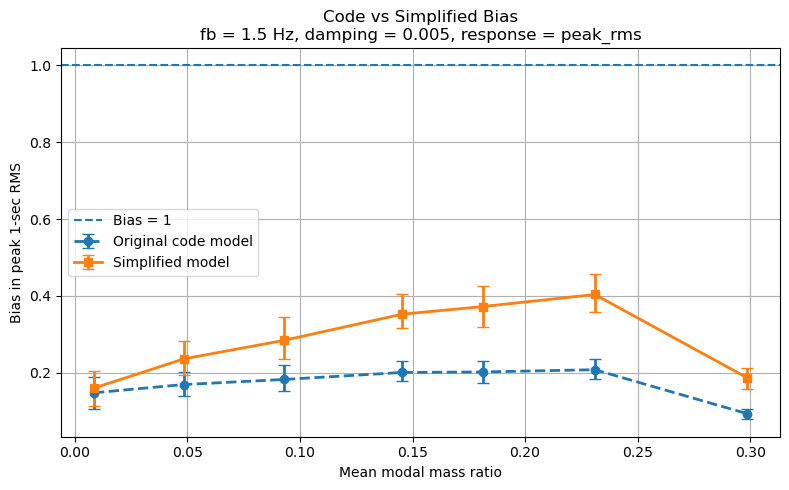

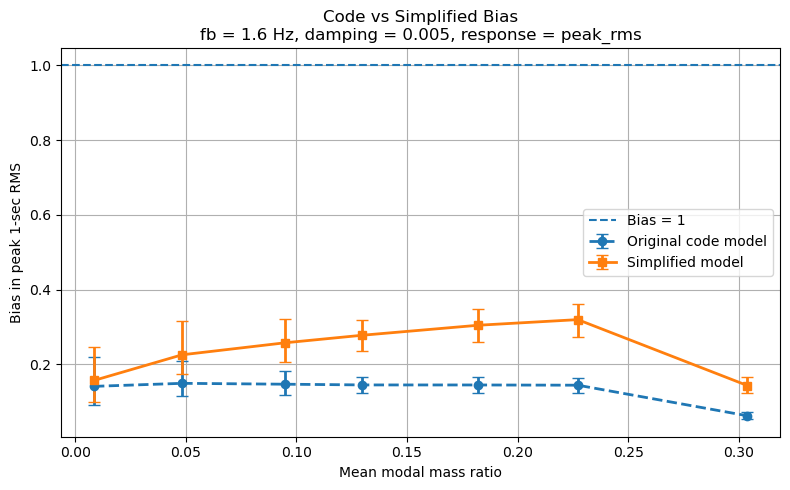

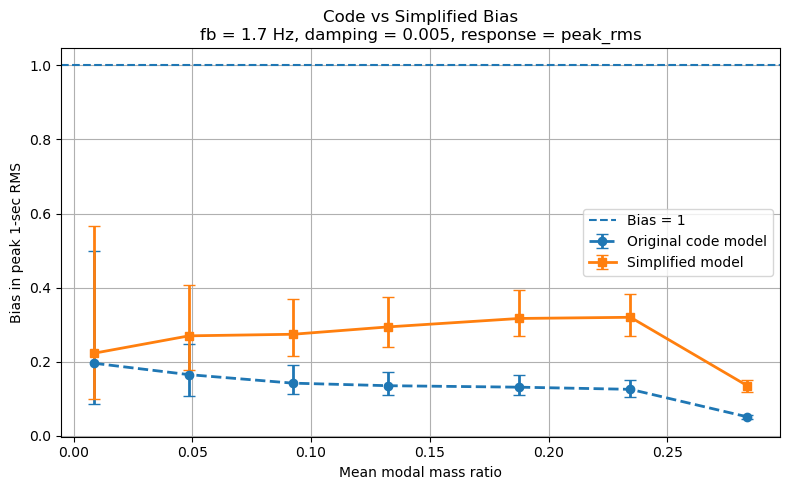

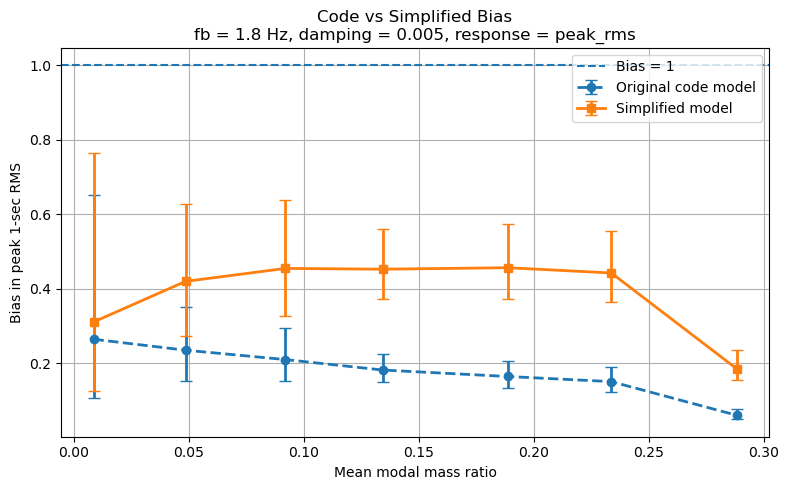

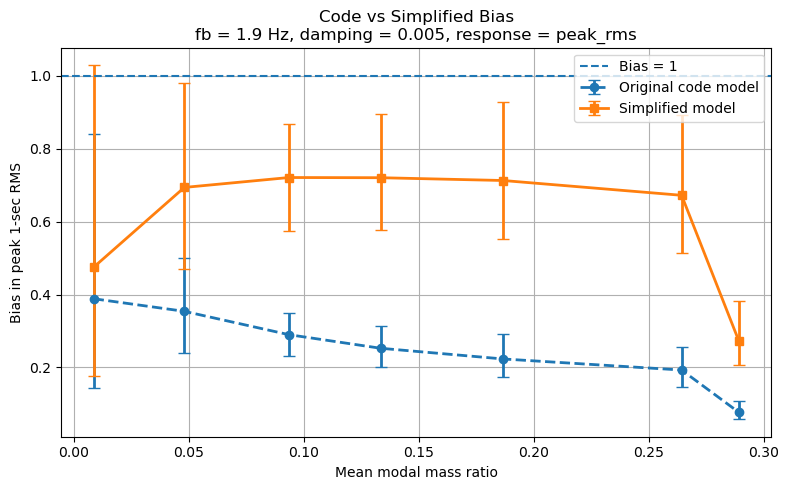

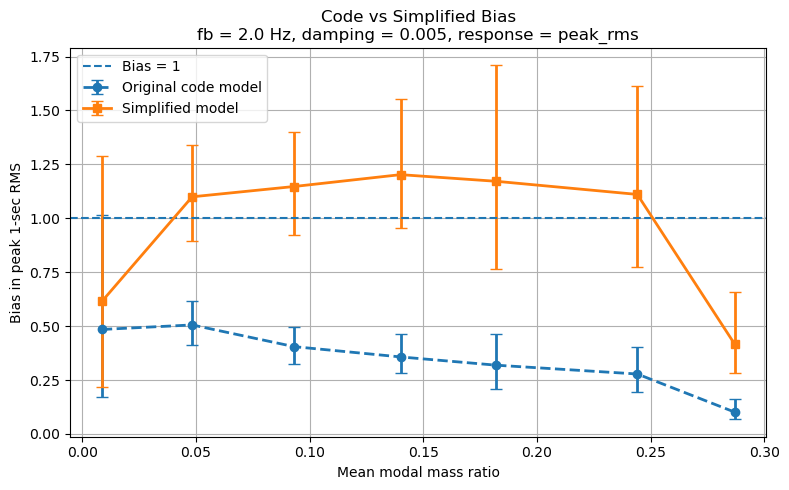

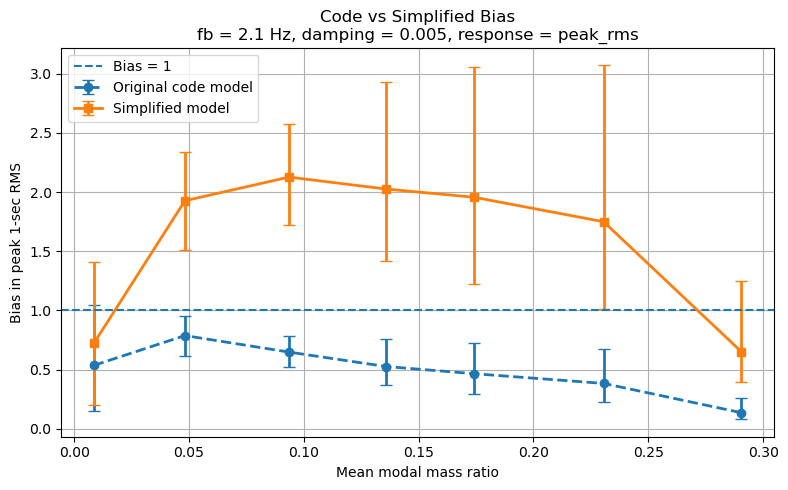

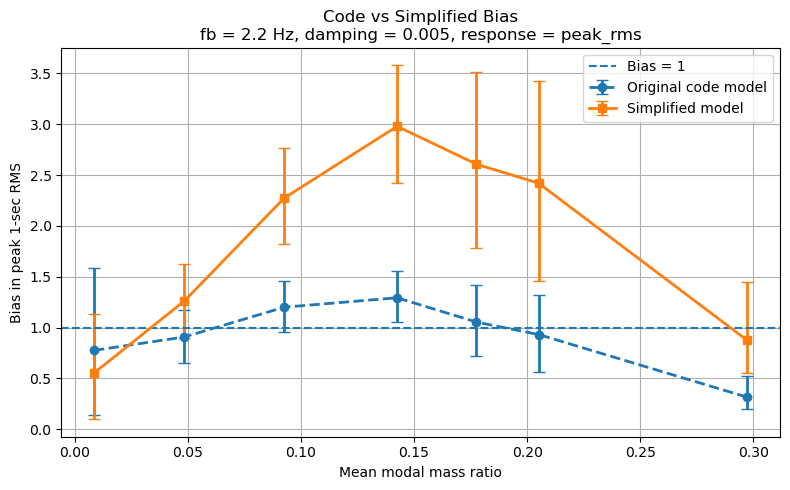

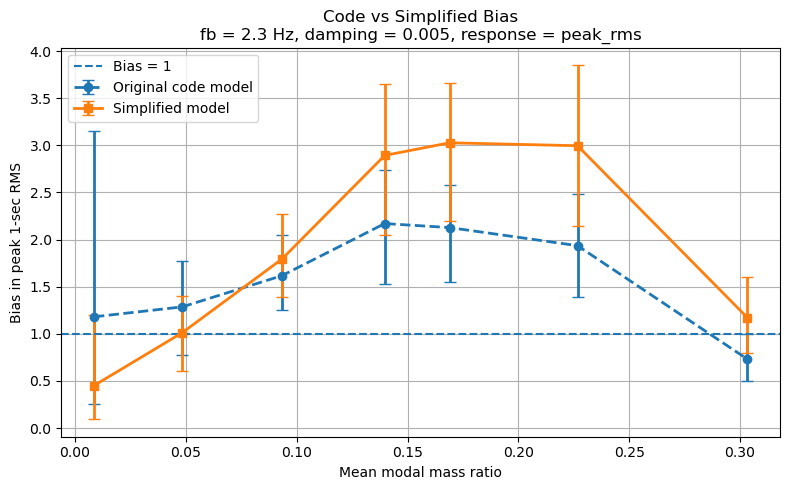

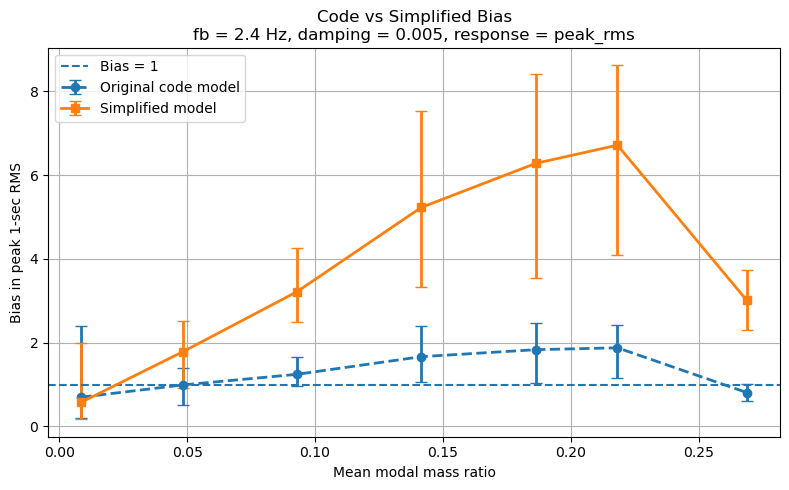

In [17]:
# ==================================================
# PLOT 4: ONE PLOT PER FREQUENCY
# CODE AND SIMPLIFIED BIAS TOGETHER
# ==================================================

for target_bf in bridge_frequencies_to_run:

    data = summary_by_freq[target_bf]

    mr_plot = np.array(data["mass_ratio"])

    code_mean = np.array(data["code_mean"])
    code_p5   = np.array(data["code_p5"])
    code_p95  = np.array(data["code_p95"])

    simp_mean = np.array(data["simp_mean"])
    simp_p5   = np.array(data["simp_p5"])
    simp_p95  = np.array(data["simp_p95"])

    # Sort by mass ratio so the lines are clean
    sort_idx = np.argsort(mr_plot)

    mr_plot = mr_plot[sort_idx]

    code_mean = code_mean[sort_idx]
    code_p5   = code_p5[sort_idx]
    code_p95  = code_p95[sort_idx]

    simp_mean = simp_mean[sort_idx]
    simp_p5   = simp_p5[sort_idx]
    simp_p95  = simp_p95[sort_idx]

    code_yerr = np.vstack([
        code_mean - code_p5,
        code_p95 - code_mean
    ])

    simp_yerr = np.vstack([
        simp_mean - simp_p5,
        simp_p95 - simp_mean
    ])

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        mr_plot,
        code_mean,
        yerr=code_yerr,
        marker="o",
        linestyle="--",
        linewidth=2,
        capsize=4,
        label="Original code model"
    )

    plt.errorbar(
        mr_plot,
        simp_mean,
        yerr=simp_yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=4,
        label="Simplified model"
    )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")

    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Code vs Simplified Bias\n"
        f"fb = {target_bf} Hz, damping = {target_beamdamp}, response = {response_measure}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Loaded force-factor database.
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

RUNNING BRIDGE FREQUENCY = 1.9 Hz

Running density = 0.0333
  total pedestrians = 3
  Tocity = 1, Outcity = 2
  actual density = 0.0300
  MC mean mass ratio       = 0.0085
  mass ratio used for x    = 0.0090

--- Simplified direct force factor rule ---
Bridge frequency              = 1.9
Interpolated x factor          = 0.8179367028033625
Force reduction factor used    = 0.8179367028033625
Density kept unchanged?        = True

fb = 1.900 Hz | density target = 0.0333
  actual density       = 0.0300
  mean modal mass ratio = 0.0085
  code mean bias        = 0.4137
  simplified mean bias  = 0.5058

Running density = 0.1667
  total pedestrians = 17
  Tocity = 8, Outcity = 9
  actual density = 0.1700
  MC mean mass ratio       = 0.0483
  mass ratio used for x    = 0.0483

--- Simplified direct force factor rule ---
Bridge frequency              = 1.9
Interpolated x factor          = 0.508440598

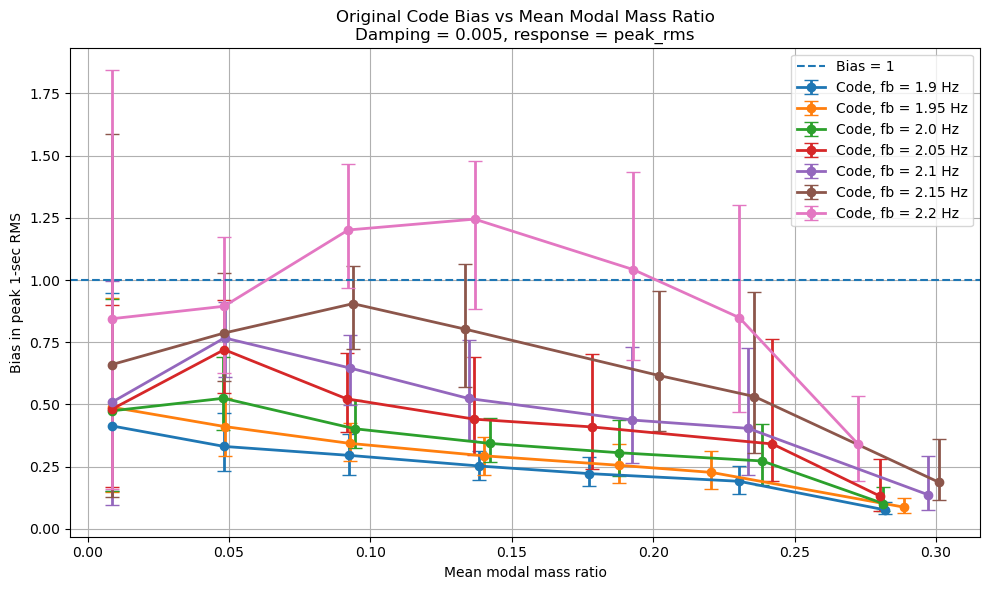

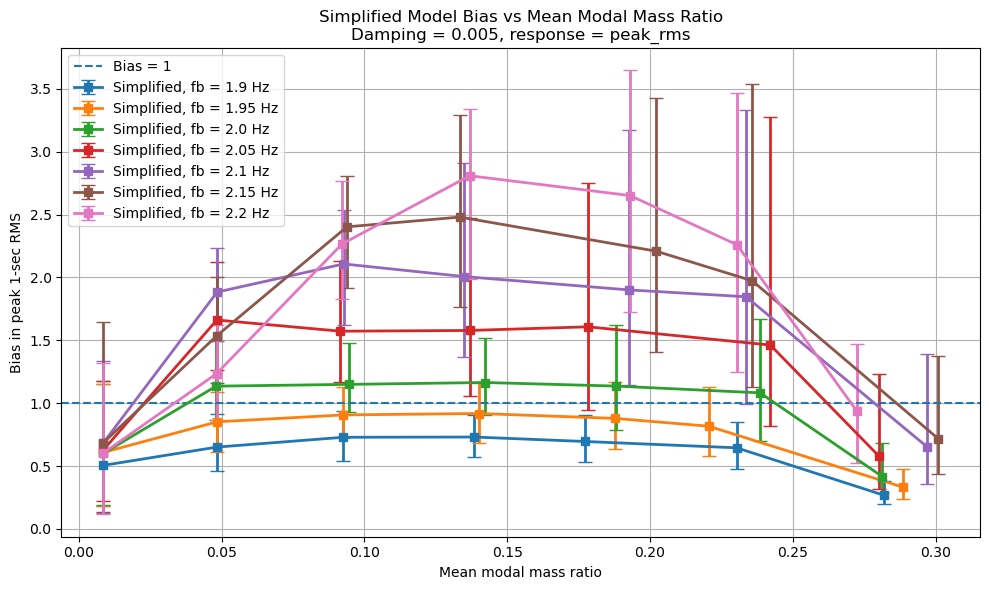

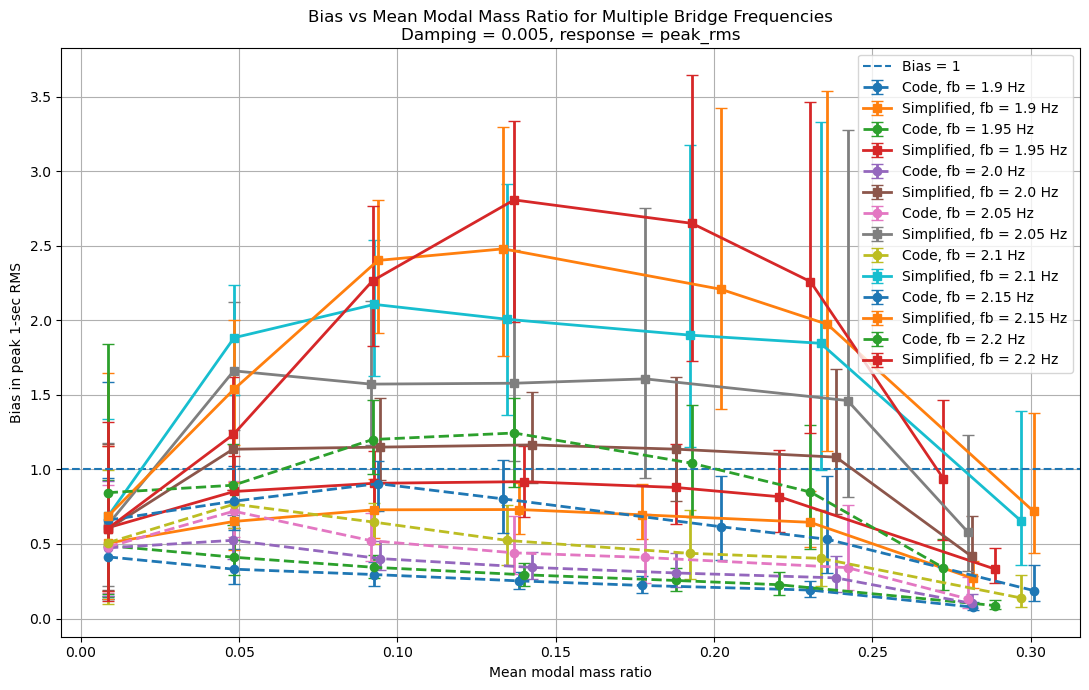

In [20]:
# ==================================================
# FULL WORKFLOW:
# Bias vs mean modal mass ratio
# for multiple bridge frequencies
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_force_factor_exact_point
)

# ==================================================
# SETTINGS
# ==================================================

NUM_SIMULATIONS = 100
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 20.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Bridge frequencies you want to study
bridge_frequencies_to_run = [1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2]

# Fixed damping ratio for this study
target_beamdamp = 0.005

# Density cases
densities = [0.0333, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0 ] #0.8333, 1.0

# Choose response measure:
# "peak_rms" = peak 1-sec RMS
# "peak_abs" = peak absolute acceleration
# "p95_acc"  = 95th percentile absolute acceleration
response_measure = "peak_rms"

# Force-factor database
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29

eps = 1e-12


# ==================================================
# RESPONSE MEASURE SETTINGS
# ==================================================

measure_specs = {
    "peak_rms": {
        "scalar_key": "peak_1sec_rms",
        "y_label": "Bias in peak 1-sec RMS",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak 1-sec RMS)"
    },
    "peak_abs": {
        "scalar_key": "peak_abs_acc",
        "y_label": "Bias in peak absolute acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak Absolute Acceleration)"
    },
    "p95_acc": {
        "scalar_key": "p95_abs_acc",
        "y_label": "Bias in 95% acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (95% Acceleration)"
    }
}

if response_measure not in measure_specs:
    raise ValueError("response_measure must be 'peak_rms', 'peak_abs', or 'p95_acc'")

scalar_key = measure_specs[response_measure]["scalar_key"]
y_label = measure_specs[response_measure]["y_label"]
plot_title = measure_specs[response_measure]["plot_title"]


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    """
    Keep mass ratio inside interpolation database range.
    """
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


def print_case_summary(target_bf, density, actual_density, mr, B_code, B_simp):
    print(f"\nfb = {target_bf:.3f} Hz | density target = {density:.4f}")
    print(f"  actual density       = {actual_density:.4f}")
    print(f"  mean modal mass ratio = {mr:.4f}")
    print(f"  code mean bias        = {np.mean(B_code):.4f}")
    print(f"  simplified mean bias  = {np.mean(B_simp):.4f}")


# ==================================================
# LOAD FORCE-FACTOR DATABASE
# ==================================================

with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

print("Loaded force-factor database.")
print("Available damping values:", ff_damping_values)


# ==================================================
# MAIN LOOP
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_by_freq = {}

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_bf in bridge_frequencies_to_run:

            print("\n" + "=" * 80)
            print(f"RUNNING BRIDGE FREQUENCY = {target_bf} Hz")
            print("=" * 80)

            BeamFreq = np.array([target_bf, 4*target_bf])
            Beamdamp = np.array([target_beamdamp])

            # storage for this bridge frequency
            mass_ratio_x = []
            density_used_list = []

            code_mean = []
            code_p5 = []
            code_p95 = []

            simp_mean = []
            simp_p5 = []
            simp_p95 = []

            for density in densities:

                # --------------------------------------------------
                # Convert density to integer pedestrian counts
                # --------------------------------------------------
                total_peds_float = density * Length * Width
                total_peds_int = int(round(total_peds_float))
                total_peds_int = max(1, total_peds_int)

                Tocity = total_peds_int // 2
                Outcity = total_peds_int - Tocity

                actual_density = (Tocity + Outcity) / (Length * Width)

                print(f"\nRunning density = {density:.4f}")
                print(f"  total pedestrians = {total_peds_int}")
                print(f"  Tocity = {Tocity}, Outcity = {Outcity}")
                print(f"  actual density = {actual_density:.4f}")

                # --------------------------------------------------
                # Run MC reference system
                # --------------------------------------------------
                seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                args_list = [
                    (
                        int(seeds[i]),
                        peddamp,
                        pedBodyF,
                        BeamFreq,
                        Beamdamp,
                        Tocity,
                        Outcity,
                        Length,
                        Width
                    )
                    for i in range(NUM_SIMULATIONS)
                ]

                results = pool.map(run_simulation, args_list)

                accelerations = np.array([r[0] for r in results])
                mean_mass_ratios = np.array([r[1] for r in results])

                overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                # --------------------------------------------------
                # Trim first 10 seconds
                # --------------------------------------------------
                steady_start_idx = int(round(steady_start_time / hht))

                if steady_start_idx >= accelerations.shape[1]:
                    raise ValueError("steady_start_time is longer than acceleration time history.")

                accelerations_ss = accelerations[:, steady_start_idx:]

                # --------------------------------------------------
                # MC response distributions
                # --------------------------------------------------
                rms_histories, peak_rms_values = peak_rms_distribution(
                    accelerations_ss,
                    dt=hht,
                    window_sec=1.0
                )

                acc_95_values = percentile_acc_distribution(
                    accelerations_ss,
                    percentile=95,
                    use_abs=True
                )

                peak_abs_acc_values = peak_abs_acc_distribution(
                    accelerations_ss
                )

                if response_measure == "peak_rms":
                    Y_ref = peak_rms_values
                elif response_measure == "peak_abs":
                    Y_ref = peak_abs_acc_values
                elif response_measure == "p95_acc":
                    Y_ref = acc_95_values
                else:
                    raise ValueError("Unknown response_measure")

                # --------------------------------------------------
                # Original deterministic/code model
                # --------------------------------------------------
                t_end = accelerations.shape[1] * hht

                code_result, code_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False
                )

                # --------------------------------------------------
                # Interpolate force factor x for simplified model
                # --------------------------------------------------
                target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                    overall_mean_mass_ratio
                )

                print(f"  MC mean mass ratio       = {overall_mean_mass_ratio:.4f}")
                print(f"  mass ratio used for x    = {target_mass_ratio_used:.4f}")

                x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
                    results_all=ff_results_all,
                    target_bf=target_bf,
                    target_beamdamp=target_beamdamp,
                    target_mass_ratio=target_mass_ratio_used,
                    damping_values=ff_damping_values,
                    densities=ff_densities,
                    bridge_frequencies=ff_bridge_frequencies,
                    pedBodyF=ff_pedBodyF
                )

                # --------------------------------------------------
                # Simplified model
                # Apply direct force modification factor x.
                # Density and pedestrian count are kept unchanged.
                # --------------------------------------------------
                force_reduction_factor_used = x_factor               
                

                Tocity_simplified = Tocity 
                Outcity_simplified = Outcity 

                print("\n--- Simplified direct force factor rule ---")
                print("Bridge frequency              =", target_bf)
                print("Interpolated x factor          =", x_factor)
                print("Force reduction factor used    =", force_reduction_factor_used)
                print("Density kept unchanged?        =", True)

                simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity_simplified,
                    Outcity=Outcity_simplified,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=0.0,# overall_mean_mass_ratio, # Use zero here since we're applying the force reduction factor directly, instead of modifying the mass ratio.
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=force_reduction_factor_used
                )

                # --------------------------------------------------
                # Bias distributions
                # --------------------------------------------------
                B_code = Y_ref / max(code_measures[scalar_key], eps)
                B_simp = Y_ref / max(simplified_measures[scalar_key], eps)

                # --------------------------------------------------
                # Store summary statistics
                # --------------------------------------------------
                mass_ratio_x.append(overall_mean_mass_ratio)
                density_used_list.append(actual_density)

                code_mean.append(np.mean(B_code))
                code_p5.append(np.percentile(B_code, 5))
                code_p95.append(np.percentile(B_code, 95))

                simp_mean.append(np.mean(B_simp))
                simp_p5.append(np.percentile(B_simp, 5))
                simp_p95.append(np.percentile(B_simp, 95))

                print_case_summary(
                    target_bf,
                    density,
                    actual_density,
                    overall_mean_mass_ratio,
                    B_code,
                    B_simp
                )

            # --------------------------------------------------
            # Sort results by mass ratio for this bridge frequency
            # --------------------------------------------------
            mass_ratio_x = np.asarray(mass_ratio_x)
            density_used_list = np.asarray(density_used_list)

            code_mean = np.asarray(code_mean)
            code_p5 = np.asarray(code_p5)
            code_p95 = np.asarray(code_p95)

            simp_mean = np.asarray(simp_mean)
            simp_p5 = np.asarray(simp_p5)
            simp_p95 = np.asarray(simp_p95)

            sort_idx = np.argsort(mass_ratio_x)

            summary_by_freq[target_bf] = {
                "mass_ratio": mass_ratio_x[sort_idx],
                "density": density_used_list[sort_idx],

                "code_mean": code_mean[sort_idx],
                "code_p5": code_p5[sort_idx],
                "code_p95": code_p95[sort_idx],

                "simp_mean": simp_mean[sort_idx],
                "simp_p5": simp_p5[sort_idx],
                "simp_p95": simp_p95[sort_idx],
            }

    # ==================================================
    # SAVE SUMMARY RESULTS
    # ==================================================

    save_summary = {
        "summary_by_freq": summary_by_freq,
        "bridge_frequencies_to_run": bridge_frequencies_to_run,
        "target_beamdamp": target_beamdamp,
        "densities": densities,
        "response_measure": response_measure,
        "NUM_SIMULATIONS": NUM_SIMULATIONS,
        "steady_start_time": steady_start_time,
        "Length": Length,
        "Width": Width,
    }

    with open("bias_vs_mass_ratio_multi_frequency.pkl", "wb") as f:
       pickle.dump(save_summary, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary to bias_vs_mass_ratio_multi_frequency.pkl")

    # ==================================================
    # PLOT 1: ORIGINAL CODE MODEL FOR ALL FREQUENCIES
    # ==================================================

    plt.figure(figsize=(10, 6))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]
        mean = data["code_mean"]
        p5 = data["code_p5"]
        p95 = data["code_p95"]

        yerr = np.vstack([
            mean - p5,
            p95 - mean
        ])

        plt.errorbar(
            mr_plot,
            mean,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=2,
            capsize=5,
            label=f"Code, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Original Code Bias vs Mean Modal Mass Ratio\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOT 2: SIMPLIFIED MODEL FOR ALL FREQUENCIES
    # ==================================================

    plt.figure(figsize=(10, 6))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]
        mean = data["simp_mean"]
        p5 = data["simp_p5"]
        p95 = data["simp_p95"]

        yerr = np.vstack([
            mean - p5,
            p95 - mean
        ])

        plt.errorbar(
            mr_plot,
            mean,
            yerr=yerr,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=5,
            label=f"Simplified, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Simplified Model Bias vs Mean Modal Mass Ratio\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOT 3: CODE AND SIMPLIFIED TOGETHER
    # ==================================================

    plt.figure(figsize=(11, 7))

    for target_bf in bridge_frequencies_to_run:

        data = summary_by_freq[target_bf]

        mr_plot = data["mass_ratio"]

        code_mean = data["code_mean"]
        code_p5 = data["code_p5"]
        code_p95 = data["code_p95"]

        simp_mean = data["simp_mean"]
        simp_p5 = data["simp_p5"]
        simp_p95 = data["simp_p95"]

        code_yerr = np.vstack([
            code_mean - code_p5,
            code_p95 - code_mean
        ])

        simp_yerr = np.vstack([
            simp_mean - simp_p5,
            simp_p95 - simp_mean
        ])

        plt.errorbar(
            mr_plot,
            code_mean,
            yerr=code_yerr,
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            label=f"Code, fb = {target_bf} Hz"
        )

        plt.errorbar(
            mr_plot,
            simp_mean,
            yerr=simp_yerr,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=4,
            label=f"Simplified, fb = {target_bf} Hz"
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Bias vs Mean Modal Mass Ratio for Multiple Bridge Frequencies\n"
        f"Damping = {target_beamdamp}, response = {response_measure}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

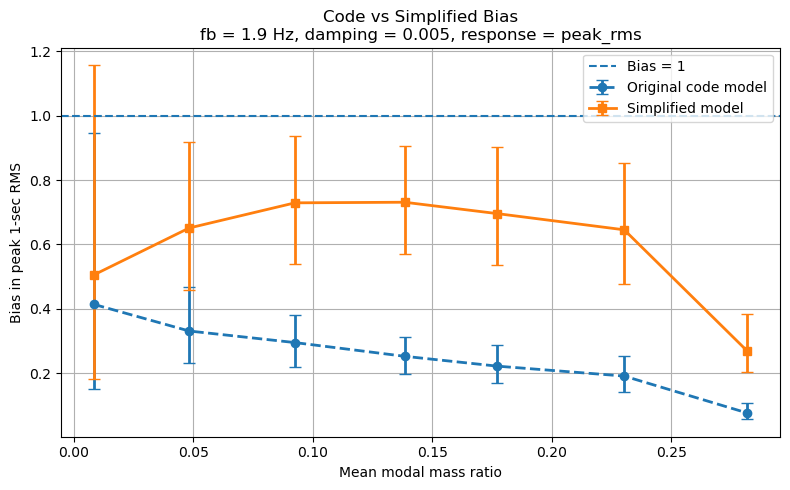

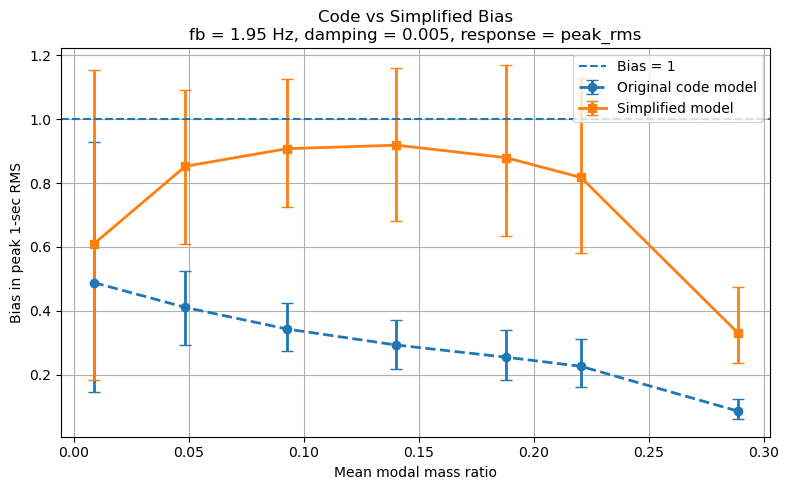

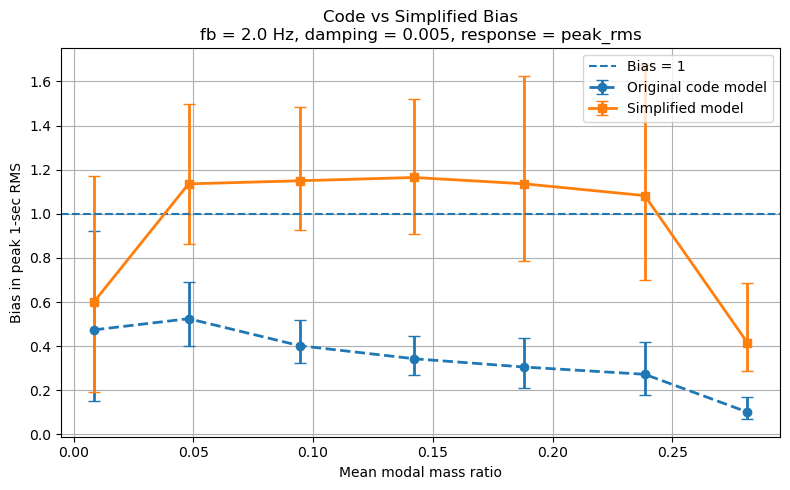

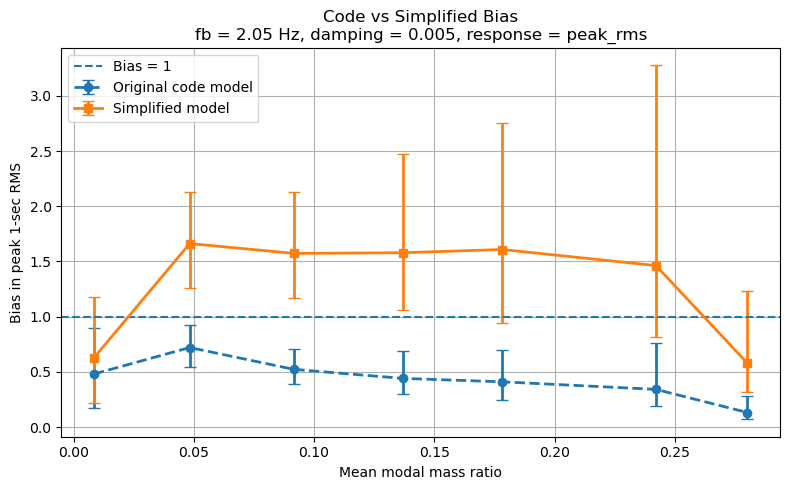

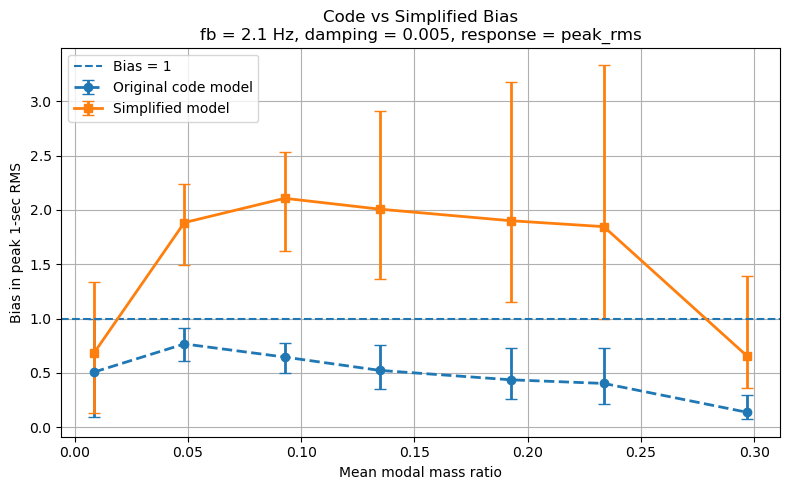

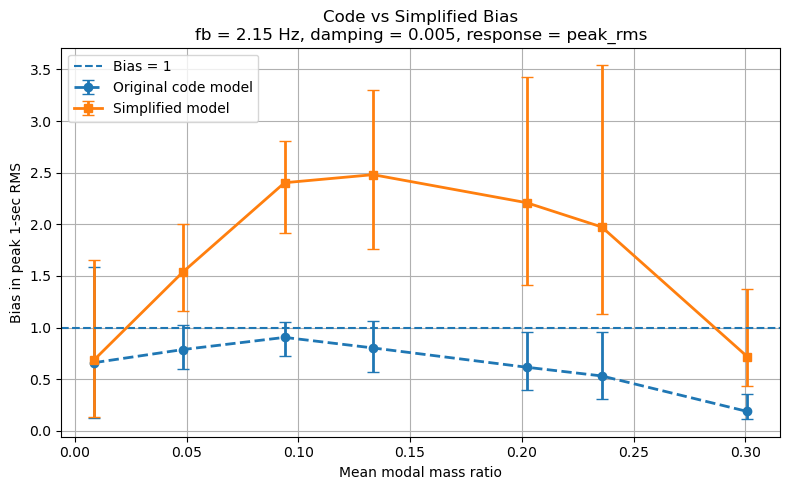

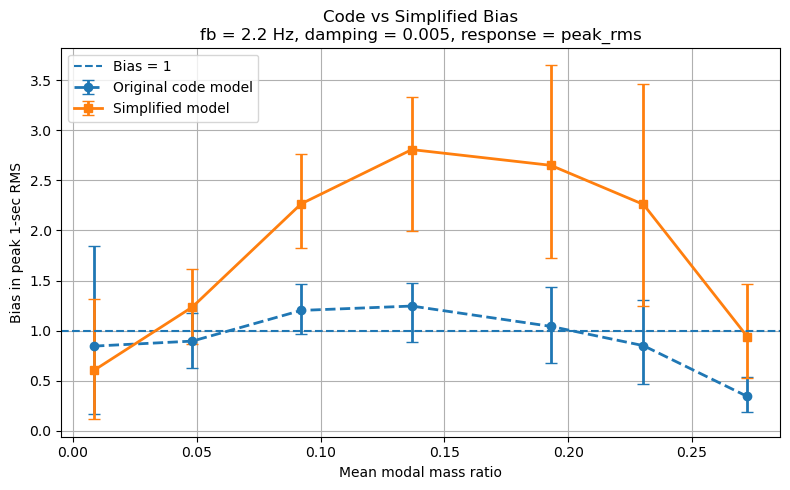

In [21]:
# ==================================================
# PLOT 4: ONE PLOT PER FREQUENCY
# CODE AND SIMPLIFIED BIAS TOGETHER
# ==================================================

for target_bf in bridge_frequencies_to_run:

    data = summary_by_freq[target_bf]

    mr_plot = np.array(data["mass_ratio"])

    code_mean = np.array(data["code_mean"])
    code_p5   = np.array(data["code_p5"])
    code_p95  = np.array(data["code_p95"])

    simp_mean = np.array(data["simp_mean"])
    simp_p5   = np.array(data["simp_p5"])
    simp_p95  = np.array(data["simp_p95"])

    # Sort by mass ratio so the lines are clean
    sort_idx = np.argsort(mr_plot)

    mr_plot = mr_plot[sort_idx]

    code_mean = code_mean[sort_idx]
    code_p5   = code_p5[sort_idx]
    code_p95  = code_p95[sort_idx]

    simp_mean = simp_mean[sort_idx]
    simp_p5   = simp_p5[sort_idx]
    simp_p95  = simp_p95[sort_idx]

    code_yerr = np.vstack([
        code_mean - code_p5,
        code_p95 - code_mean
    ])

    simp_yerr = np.vstack([
        simp_mean - simp_p5,
        simp_p95 - simp_mean
    ])

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        mr_plot,
        code_mean,
        yerr=code_yerr,
        marker="o",
        linestyle="--",
        linewidth=2,
        capsize=4,
        label="Original code model"
    )

    plt.errorbar(
        mr_plot,
        simp_mean,
        yerr=simp_yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=4,
        label="Simplified model"
    )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")

    plt.xlabel("Mean modal mass ratio")
    plt.ylabel(y_label)
    plt.title(
        f"Code vs Simplified Bias\n"
        f"fb = {target_bf} Hz, damping = {target_beamdamp}, response = {response_measure}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

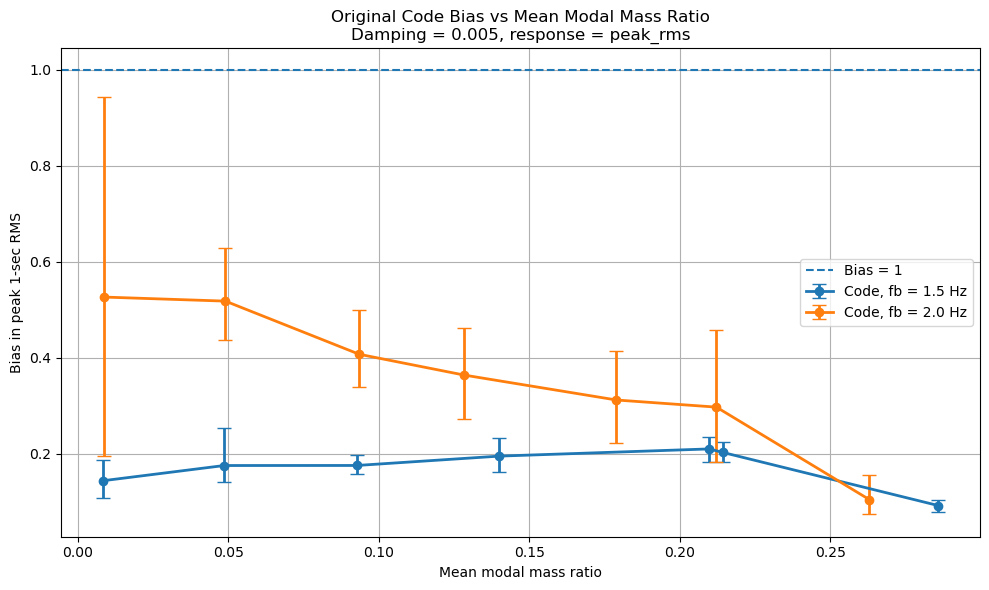

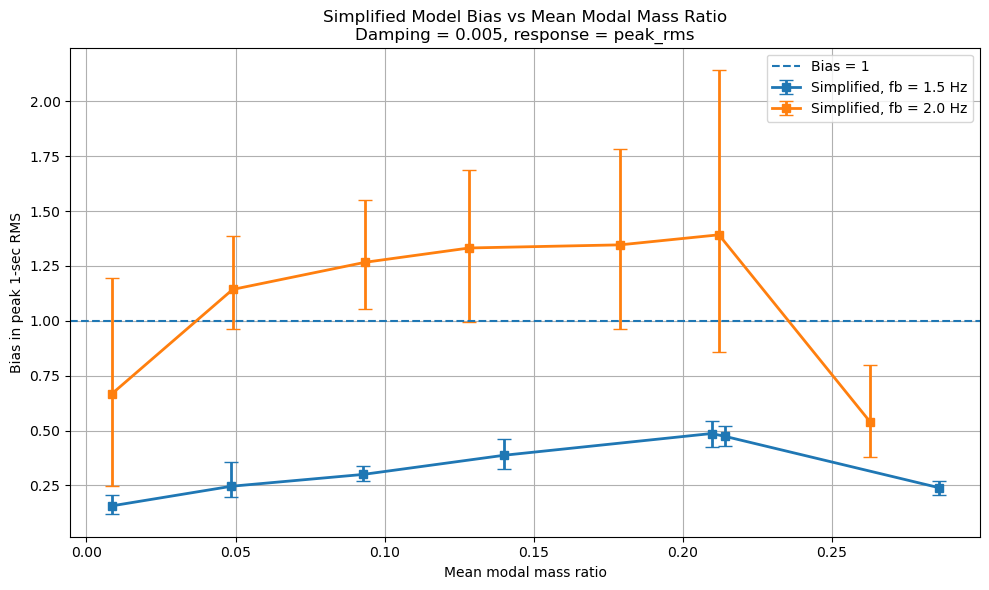

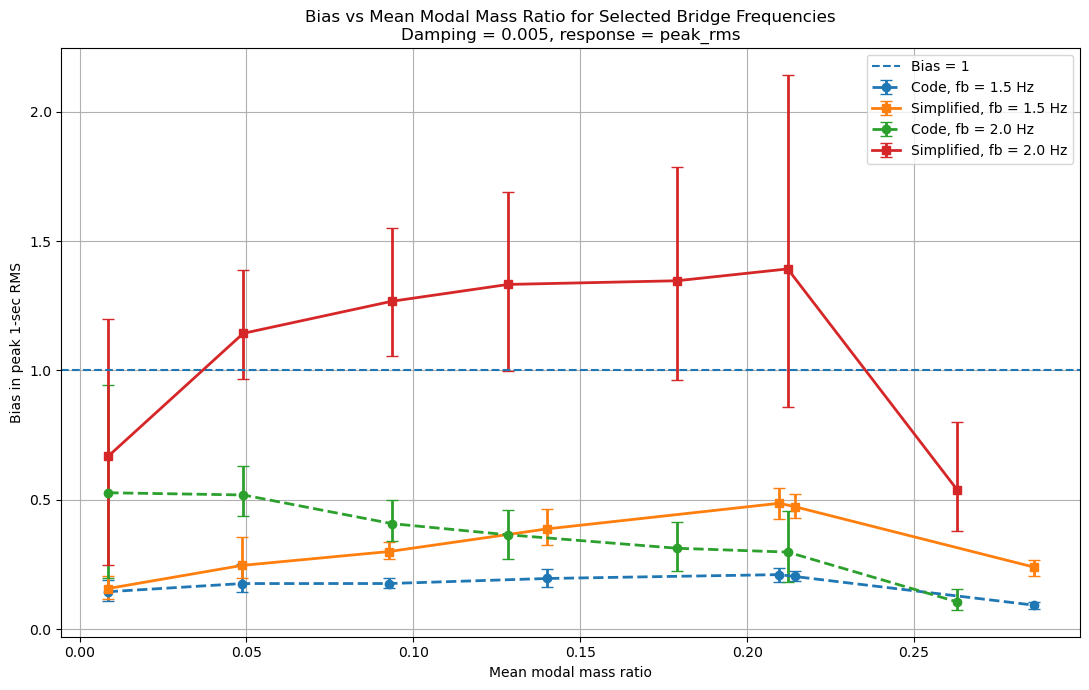

In [8]:
# ==================================================
# ONLY PLOT SELECTED FREQUENCIES
# ==================================================

frequencies_to_plot = [1.5, 2.0]

# ==================================================
# PLOT 1: ORIGINAL CODE MODEL FOR SELECTED FREQUENCIES
# ==================================================

plt.figure(figsize=(10, 6))

for target_bf in frequencies_to_plot:

    data = summary_by_freq[target_bf]

    mr_plot = data["mass_ratio"]
    mean = data["code_mean"]
    p5 = data["code_p5"]
    p95 = data["code_p95"]

    yerr = np.vstack([
        mean - p5,
        p95 - mean
    ])

    plt.errorbar(
        mr_plot,
        mean,
        yerr=yerr,
        marker="o",
        linestyle="-",
        linewidth=2,
        capsize=5,
        label=f"Code, fb = {target_bf} Hz"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"Original Code Bias vs Mean Modal Mass Ratio\n"
    f"Damping = {target_beamdamp}, response = {response_measure}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 2: SIMPLIFIED MODEL FOR SELECTED FREQUENCIES
# ==================================================

plt.figure(figsize=(10, 6))

for target_bf in frequencies_to_plot:

    data = summary_by_freq[target_bf]

    mr_plot = data["mass_ratio"]
    mean = data["simp_mean"]
    p5 = data["simp_p5"]
    p95 = data["simp_p95"]

    yerr = np.vstack([
        mean - p5,
        p95 - mean
    ])

    plt.errorbar(
        mr_plot,
        mean,
        yerr=yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=5,
        label=f"Simplified, fb = {target_bf} Hz"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"Simplified Model Bias vs Mean Modal Mass Ratio\n"
    f"Damping = {target_beamdamp}, response = {response_measure}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 3: CODE AND SIMPLIFIED TOGETHER FOR SELECTED FREQUENCIES
# ==================================================

plt.figure(figsize=(11, 7))

for target_bf in frequencies_to_plot:

    data = summary_by_freq[target_bf]

    mr_plot = data["mass_ratio"]

    code_mean = data["code_mean"]
    code_p5 = data["code_p5"]
    code_p95 = data["code_p95"]

    simp_mean = data["simp_mean"]
    simp_p5 = data["simp_p5"]
    simp_p95 = data["simp_p95"]

    code_yerr = np.vstack([
        code_mean - code_p5,
        code_p95 - code_mean
    ])

    simp_yerr = np.vstack([
        simp_mean - simp_p5,
        simp_p95 - simp_mean
    ])

    plt.errorbar(
        mr_plot,
        code_mean,
        yerr=code_yerr,
        marker="o",
        linestyle="--",
        linewidth=2,
        capsize=4,
        label=f"Code, fb = {target_bf} Hz"
    )

    plt.errorbar(
        mr_plot,
        simp_mean,
        yerr=simp_yerr,
        marker="s",
        linestyle="-",
        linewidth=2,
        capsize=4,
        label=f"Simplified, fb = {target_bf} Hz"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")
plt.xlabel("Mean modal mass ratio")
plt.ylabel(y_label)
plt.title(
    f"Bias vs Mean Modal Mass Ratio for Selected Bridge Frequencies\n"
    f"Damping = {target_beamdamp}, response = {response_measure}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

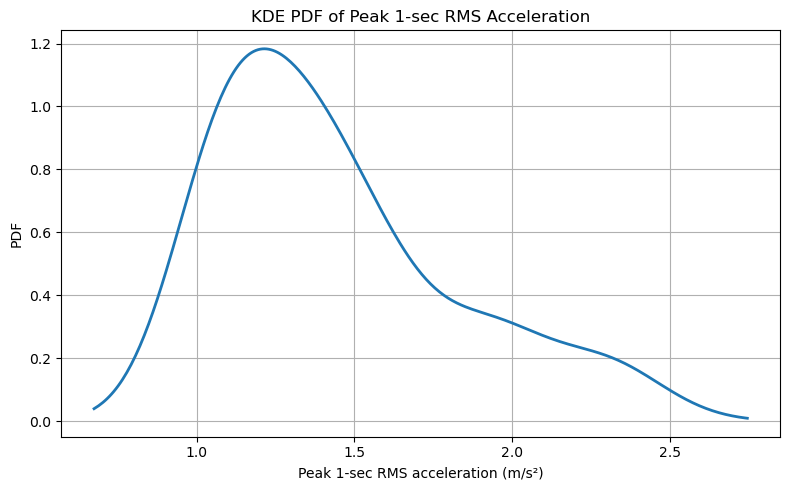

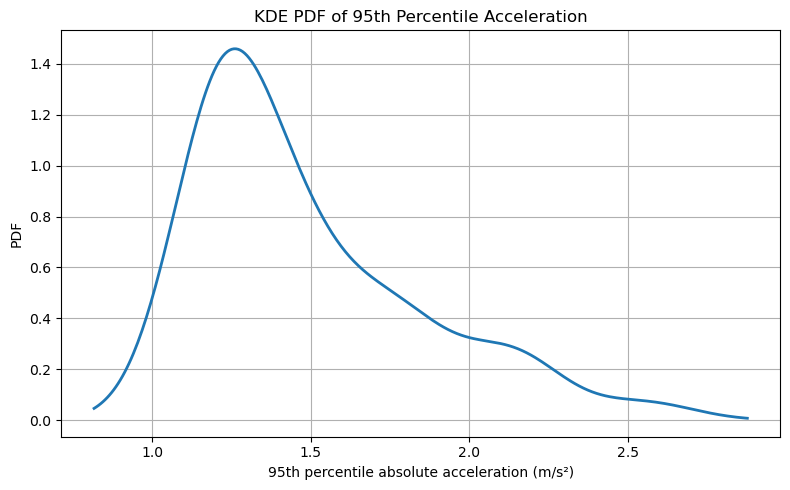

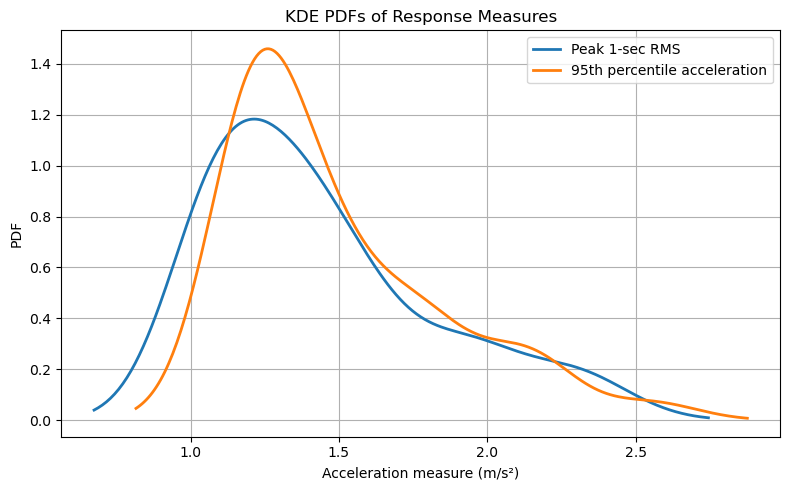

In [3]:
discard_samples = int(10 / hht)
accelerations_trimmed = accelerations[:, discard_samples:]
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_trimmed,
    dt=hht,
    window_sec=1.0
)

acc_95_values = percentile_acc_distribution(
    accelerations_trimmed,
    percentile=95,
    use_abs=True
)

# KDE PDF of peak 1-sec RMS values
x_peak_rms, kde_peak_rms = plot_kde_pdf(
    peak_rms_values,
    num_points=300,
    bandwidth="scott",
    xlabel="Peak 1-sec RMS acceleration (m/s²)",
    title="KDE PDF of Peak 1-sec RMS Acceleration"
    )

# KDE PDF of 95th percentile acceleration values
x_acc_95, kde_acc_95 = plot_kde_pdf(
    acc_95_values,
    num_points=300,
    bandwidth="scott",
    xlabel="95th percentile absolute acceleration (m/s²)",
    title="KDE PDF of 95th Percentile Acceleration"
    )

t_trimmed = np.arange(accelerations_trimmed.shape[1]) * hht + 10

plt.figure(figsize=(8, 5))

plt.plot(x_peak_rms, kde_peak_rms, linewidth=2, label="Peak 1-sec RMS")
plt.plot(x_acc_95, kde_acc_95, linewidth=2, label="95th percentile acceleration")

plt.xlabel("Acceleration measure (m/s²)")
plt.ylabel("PDF")
plt.title("KDE PDFs of Response Measures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

accelerations shape: (10, 10001)
mean_mass_ratios shape: (10,)
Mean modal mass ratio = 0.3044423999110668
Std modal mass ratio  = 0.1046827306127791
95th percentile of max |acc| = 6.4569991378996905
95th percentile of max 1-sec RMS = 2.4491681595217507


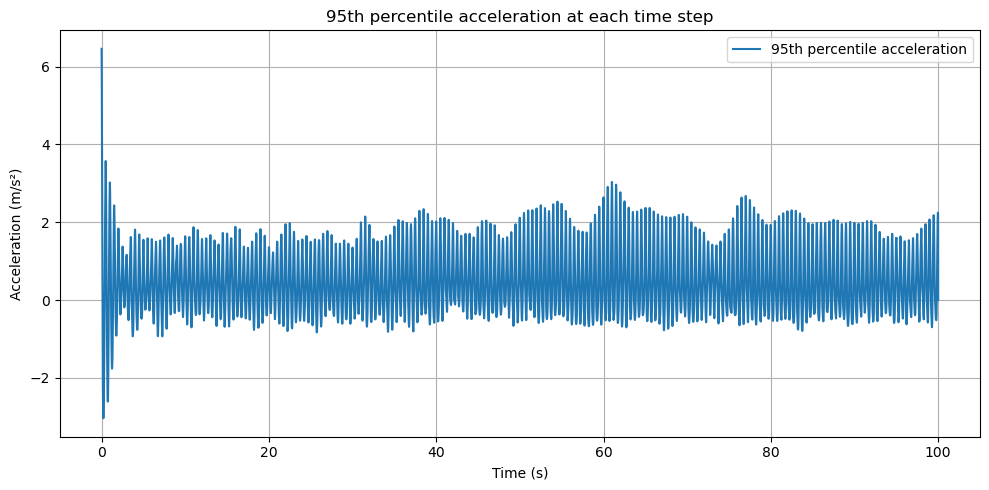

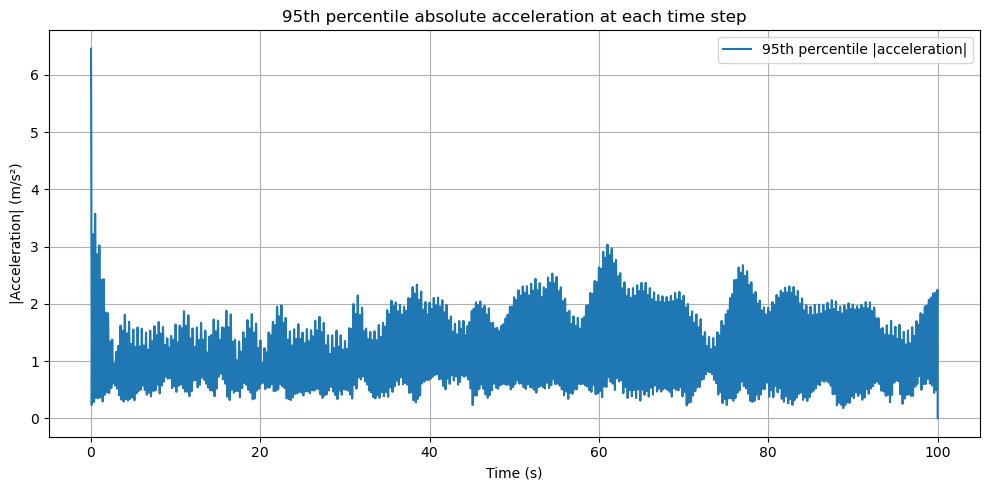

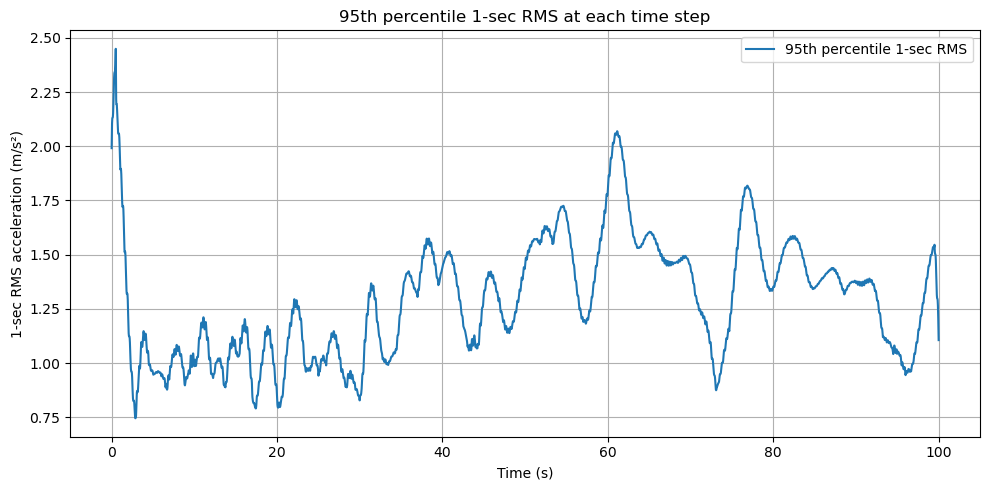

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt

from bias import run_simulation
from biascodefunction import sliding_rms  


if __name__ == "__main__":
    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # -----------------------------
    # settings
    # -----------------------------
    NUM_SIMULATIONS = 10
    NUM_PROCESSES = 10

    peddamp = 0.30
    pedBodyF = 3.10
    Tocity = 50
    Outcity = 50
    Length = 50
    Width = 2

    hht = 0.01   # same as used in bias.py

    # -----------------------------
    # Monte Carlo runs
    # -----------------------------
    rng = np.random.default_rng()
    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

    args_list = [
        (int(seed), peddamp, pedBodyF, Tocity, Outcity, Length, Width)
        for seed in seeds
    ]

    with mp.get_context("spawn").Pool(processes=NUM_PROCESSES) as pool:
        results = pool.map(run_simulation, args_list)

    # -----------------------------
    # unpack outputs
    # -----------------------------
    accelerations = np.array([r[0] for r in results], dtype=float)
    mean_mass_ratios = np.array([r[1] for r in results], dtype=float)

    print("accelerations shape:", accelerations.shape)
    print("mean_mass_ratios shape:", mean_mass_ratios.shape)

    # -----------------------------
    # time vector
    # -----------------------------
    nt = accelerations.shape[1]
    t = np.arange(nt) * hht

    # -----------------------------
    # 95th percentile acceleration
    # at each time step
    # -----------------------------
    acc_95 = np.percentile(accelerations, 95, axis=0)
    abs_acc_95 = np.percentile(np.abs(accelerations), 95, axis=0)

    # -----------------------------
    # 1-second RMS history for each simulation
    # -----------------------------
    rms_all = np.array([
        sliding_rms(accelerations[i], hht, window_sec=1.0)
        for i in range(NUM_SIMULATIONS)
    ])

    # 95th percentile RMS at each time step
    rms_95 = np.percentile(rms_all, 95, axis=0)

    # optional summary values
    max_rms_each_sim = np.max(rms_all, axis=1)
    max_abs_acc_each_sim = np.max(np.abs(accelerations), axis=1)

    print("Mean modal mass ratio =", np.mean(mean_mass_ratios))
    print("Std modal mass ratio  =", np.std(mean_mass_ratios))
    print("95th percentile of max |acc| =", np.percentile(max_abs_acc_each_sim, 95))
    print("95th percentile of max 1-sec RMS =", np.percentile(max_rms_each_sim, 95))

    # -----------------------------
    # plots
    # -----------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(t, acc_95, label="95th percentile acceleration")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.title("95th percentile acceleration at each time step")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(t, abs_acc_95, label="95th percentile |acceleration|")
    plt.xlabel("Time (s)")
    plt.ylabel("|Acceleration| (m/s²)")
    plt.title("95th percentile absolute acceleration at each time step")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(t, rms_95, label="95th percentile 1-sec RMS")
    plt.xlabel("Time (s)")
    plt.ylabel("1-sec RMS acceleration (m/s²)")
    plt.title("95th percentile 1-sec RMS at each time step")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Mean modal mass ratio for stochastic case = 0.30457566360779575
Mean of stochastic 95% |acc| curve = 1.5263923411947755
Mean of stochastic 95% RMS curve   = 1.5234337372446976
95th percentile of code |acc| = 19.18892636195299
95th percentile of code RMS   = 13.845712846684801

CASE BIAS RESULTS
Bias using mean stochastic 95% |acc| / code 95% |acc| = 0.07954547911660358
Bias using mean stochastic 95% RMS / code 95% RMS     = 0.11002927434028552


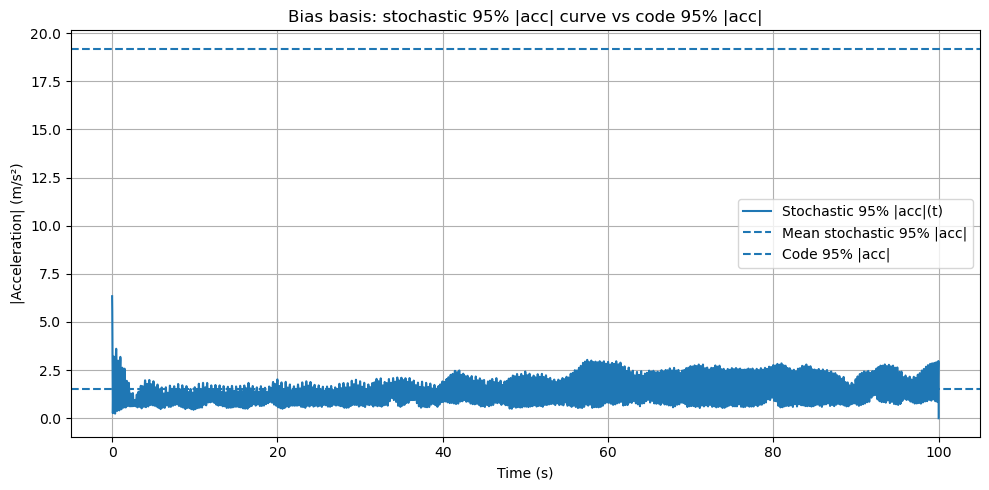

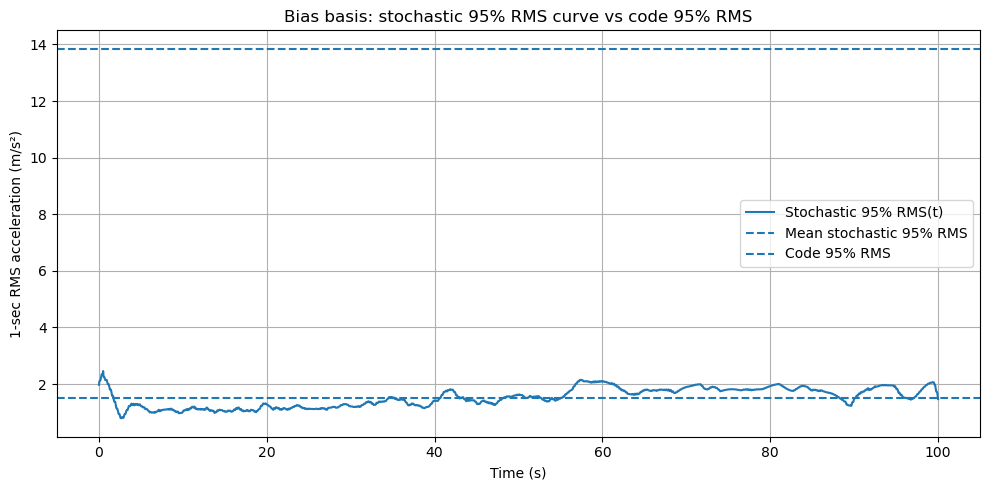

In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt

from bias import run_simulation
from biascodefunction import run_code_response, sliding_rms


if __name__ == "__main__":
    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # USER INPUTS FOR THE CASE
    # --------------------------------------------------
    NUM_SIMULATIONS = 50
    NUM_PROCESSES = 10

    # stochastic model inputs
    peddamp = 0.30
    pedBodyF = 3.10
    Tocity = 50
    Outcity = 50
    Length = 50.0
    Width = 2.0
    hht = 0.01

    # code-model inputs (must match the stochastic case)
    beam_freq = np.array([2.0, 8.0])   # match bias.py as it is now
    modal_damping_ratio = 0.005
    linear_mass = 500.0
    numbers = 2
    modify_both_modes = True

    # --------------------------------------------------
    # 1) STOCHASTIC MONTE CARLO
    # --------------------------------------------------
    rng = np.random.default_rng()
    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

    args_list = [
        (int(seed), peddamp, pedBodyF, Tocity, Outcity, Length, Width)
        for seed in seeds
    ]

    with mp.get_context("spawn").Pool(processes=NUM_PROCESSES) as pool:
        results = pool.map(run_simulation, args_list)

    accelerations = np.array([r[0] for r in results], dtype=float)
    mean_mass_ratios = np.array([r[1] for r in results], dtype=float)

    nt = accelerations.shape[1]
    t = np.arange(nt) * hht

    # pointwise 95th-percentile stochastic curves
    abs_acc_95_stoch = np.percentile(np.abs(accelerations), 95, axis=0)

    rms_all = np.array([
        sliding_rms(accelerations[i], hht, window_sec=1.0)
        for i in range(NUM_SIMULATIONS)
    ])
    rms_95_stoch = np.percentile(rms_all, 95, axis=0)

    # scalar summaries you asked for
    mean_abs_acc_95_stoch = np.mean(abs_acc_95_stoch)
    mean_rms_95_stoch = np.mean(rms_95_stoch)

    mean_mass_ratio_case = np.mean(mean_mass_ratios)

    print("Mean modal mass ratio for stochastic case =", mean_mass_ratio_case)
    print("Mean of stochastic 95% |acc| curve =", mean_abs_acc_95_stoch)
    print("Mean of stochastic 95% RMS curve   =", mean_rms_95_stoch)

    # --------------------------------------------------
    # 2) CODE PREDICTION FOR THE SAME CASE
    # --------------------------------------------------
    # Here density is the target case density.
    # If you want, replace 1.0 with the realized stochastic mean density later.
    density_case = 1.0

    result_code = run_code_response(
        density=density_case,
        mass_ratio=mean_mass_ratio_case,
        length=Length,
        width=Width,
        beam_freq=beam_freq,
        modal_damping_ratio=modal_damping_ratio,
        linear_mass=linear_mass,
        hht=hht,
        t_end=t[-1] + hht,
        numbers=numbers,
        modify_both_modes=modify_both_modes
    )

    acc_code = np.asarray(result_code["acceleration"], dtype=float)

    # align lengths if needed
    nmin = min(len(acc_code), len(t))
    t_plot = t[:nmin]
    acc_code = acc_code[:nmin]

    rms_code = sliding_rms(acc_code, hht, window_sec=1.0)

    # 95th percentile of code prediction over time
    code_abs_acc_95 = np.percentile(np.abs(acc_code), 95)
    code_rms_95 = np.percentile(rms_code, 95)

    print("95th percentile of code |acc| =", code_abs_acc_95)
    print("95th percentile of code RMS   =", code_rms_95)

    # --------------------------------------------------
    # 3) BIAS
    # --------------------------------------------------
    eps = 1e-12

    bias_abs = mean_abs_acc_95_stoch / max(code_abs_acc_95, eps)
    bias_rms = mean_rms_95_stoch / max(code_rms_95, eps)

    print("\nCASE BIAS RESULTS")
    print("Bias using mean stochastic 95% |acc| / code 95% |acc| =", bias_abs)
    print("Bias using mean stochastic 95% RMS / code 95% RMS     =", bias_rms)

    # --------------------------------------------------
    # 4) OPTIONAL PLOTS
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(t, abs_acc_95_stoch, label="Stochastic 95% |acc|(t)")
    plt.axhline(mean_abs_acc_95_stoch, linestyle="--", label="Mean stochastic 95% |acc|")
    plt.axhline(code_abs_acc_95, linestyle="--", label="Code 95% |acc|")
    plt.xlabel("Time (s)")
    plt.ylabel("|Acceleration| (m/s²)")
    plt.title("Bias basis: stochastic 95% |acc| curve vs code 95% |acc|")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, rms_95_stoch[:nmin], label="Stochastic 95% RMS(t)")
    plt.axhline(mean_rms_95_stoch, linestyle="--", label="Mean stochastic 95% RMS")
    plt.axhline(code_rms_95, linestyle="--", label="Code 95% RMS")
    plt.xlabel("Time (s)")
    plt.ylabel("1-sec RMS acceleration (m/s²)")
    plt.title("Bias basis: stochastic 95% RMS curve vs code 95% RMS")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Accelerations shape: (1, 10001)
Mean modal mass ratios shape: (1,)
Overall mean modal mass ratio = 0.3614180881083526
Overall std modal mass ratio  = 0.0


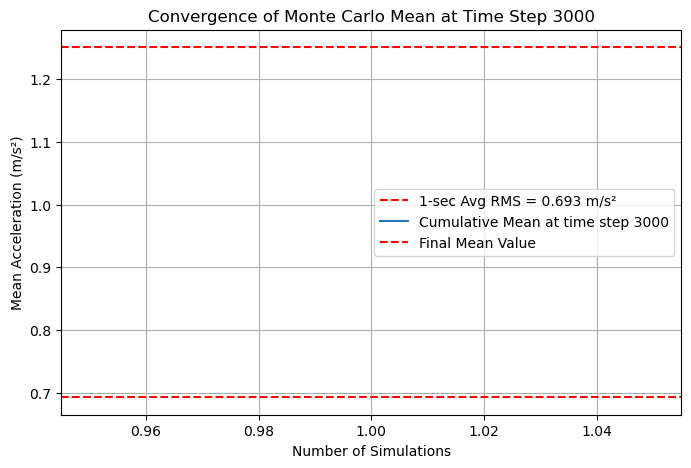

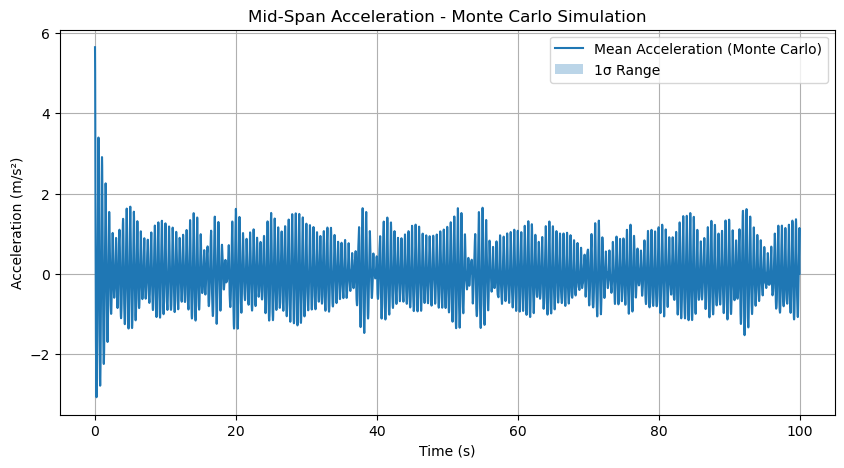

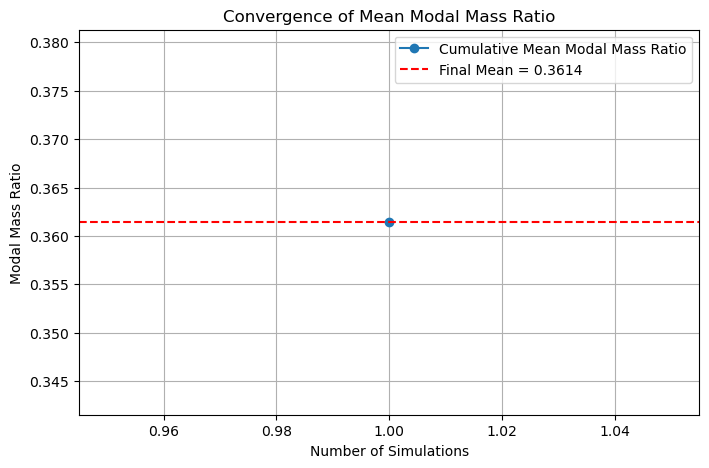

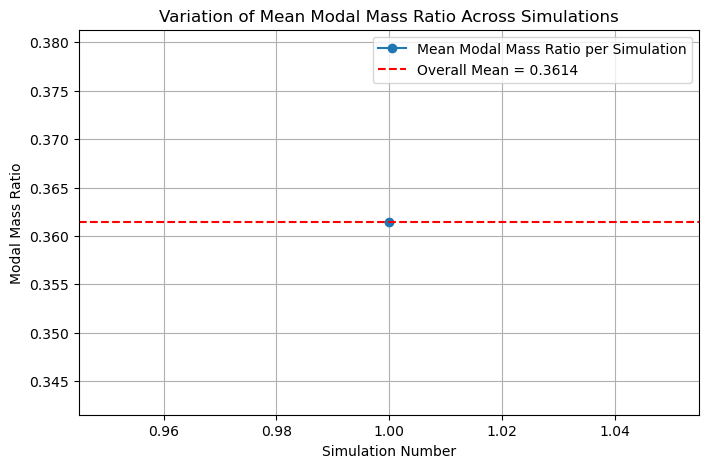


---------------- CODE COMPARISON ----------------
Overall mean modal mass ratio = 0.3614180881083526
Code modifier                 = 1.3614180881083526
Code modified modal mass      = 17017.72610135441
Code peak abs acceleration    = 18.786026809039846
Code peak envelope            = 18.786026809039846
Code max 1-sec RMS            = 13.269898124666454

---------------- BIAS ----------------
Bias (peak abs acceleration)  = 0.30058328792428624
Bias (peak envelope)          = 0.30058328792428624
Bias (max 1-sec RMS)          = 0.17700930450443383


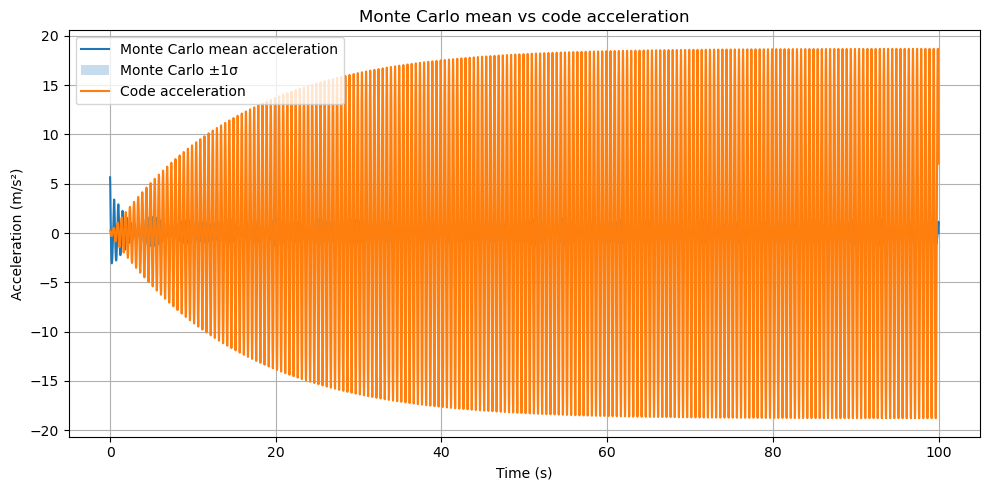

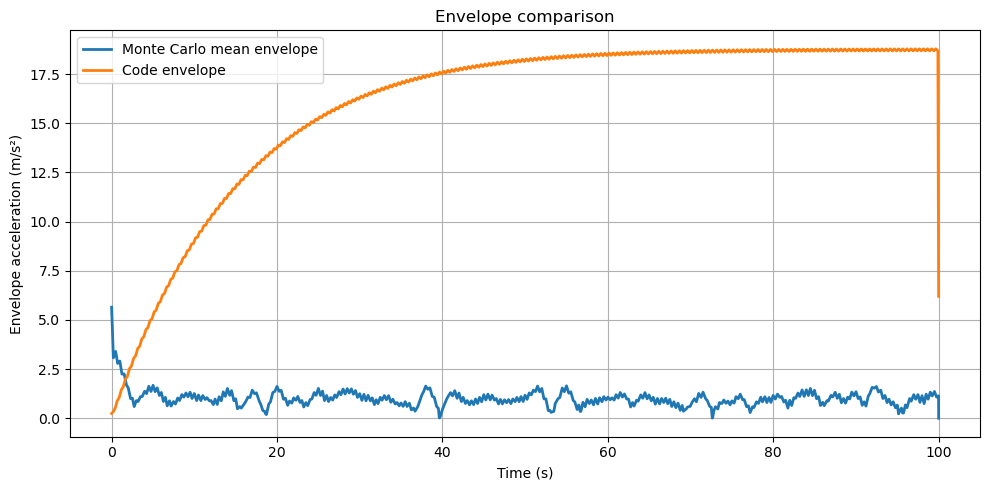

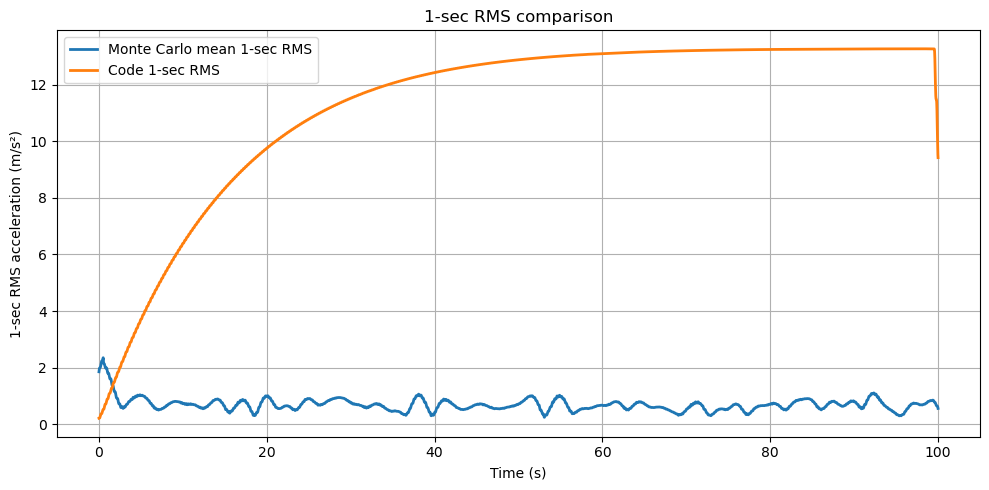

In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt

from bias import run_simulation
from solver import compute_1sec_rms_mean
from biascodefunction import (
    run_code_response,
    compute_bias_from_histories,
    build_peak_envelope,
    sliding_rms,
)

NUM_SIMULATIONS = 1
NUM_PROCESSES = 1
hht = 0.01

if __name__ == "__main__":
    peddamp = 0.30
    pedBodyF = 3.10
    BeamFreq = np.array([2.0,8.0])          # keep consistent with stochastic model
    Beamdamp = np.array([0.005])
    Tocity = 50
    Outcity = 50
    Length = 50.0
    Width = 2.0
    linear_mass = 500.0
    density_code = (Tocity+Outcity)/(Length*Width)

    with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
        args_list = [
            (None, peddamp, pedBodyF, BeamFreq, Beamdamp, Tocity, Outcity, Length, Width)
            for _ in range(NUM_SIMULATIONS)
        ]
        results = pool.map(run_simulation, args_list)

    accelerations = np.array([r[0] for r in results], dtype=float)
    mean_mass_ratios = np.array([r[1] for r in results], dtype=float)

    print("Accelerations shape:", accelerations.shape)
    print("Mean modal mass ratios shape:", mean_mass_ratios.shape)

    mean_acceleration = np.mean(accelerations, axis=0)
    std_acceleration = np.std(accelerations, axis=0)

    cumulative_means = np.array([
        np.mean(accelerations[:i+1], axis=0) for i in range(NUM_SIMULATIONS)
    ])

    time_step = 3000
    convergence_curve = cumulative_means[:, time_step]

    avg_1sec_rms = compute_1sec_rms_mean(accelerations, int(1 / hht))

    t = np.arange(accelerations.shape[1]) * hht

    overall_mean_mass_ratio = np.mean(mean_mass_ratios)
    overall_std_mass_ratio = np.std(mean_mass_ratios)

    sim_numbers = np.arange(1, NUM_SIMULATIONS + 1)
    cumulative_mean_mass_ratio = np.cumsum(mean_mass_ratios) / sim_numbers

    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Overall std modal mass ratio  =", overall_std_mass_ratio)

    # ---------------- existing plots ----------------
    plt.figure(figsize=(8, 5))
    plt.axhline(avg_1sec_rms, color='red', linestyle='--',
                label=f'1-sec Avg RMS = {avg_1sec_rms:.3f} m/s²')
    plt.plot(sim_numbers, convergence_curve, label=f"Cumulative Mean at time step {time_step}")
    plt.axhline(y=convergence_curve[-1], color='r', linestyle="--", label="Final Mean Value")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Mean Acceleration (m/s²)")
    plt.title(f"Convergence of Monte Carlo Mean at Time Step {time_step}")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(t, mean_acceleration, label="Mean Acceleration (Monte Carlo)")
    plt.fill_between(
        t,
        mean_acceleration - std_acceleration,
        mean_acceleration + std_acceleration,
        alpha=0.3,
        label="1σ Range"
    )
    plt.title("Mid-Span Acceleration - Monte Carlo Simulation")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, cumulative_mean_mass_ratio, marker='o',
             label="Cumulative Mean Modal Mass Ratio")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Final Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Convergence of Mean Modal Mass Ratio")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, mean_mass_ratios, marker='o', linestyle='-',
             label="Mean Modal Mass Ratio per Simulation")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Overall Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Simulation Number")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Variation of Mean Modal Mass Ratio Across Simulations")
    plt.legend()
    plt.grid()
    plt.show()

    # ---------------- code response ----------------
    numbers = len(np.atleast_1d(BeamFreq))
    t_end_code = accelerations.shape[1] * hht

    code_result = run_code_response(
        density=density_code,
        mass_ratio=overall_mean_mass_ratio,
        length=Length,
        width=Width,
        beam_freq=BeamFreq,
        modal_damping_ratio=Beamdamp,
        linear_mass=linear_mass,
        hht=hht,
        t_end=t_end_code,
        numbers=numbers,
        modify_both_modes=True
    )

    t_code = code_result["t"]
    acc_code = np.asarray(code_result["acceleration"], dtype=float)
    env_code = np.asarray(code_result["envelope"], dtype=float)
    rms_code = np.asarray(code_result["rms_1s"], dtype=float)

    env_mc = build_peak_envelope(t, mean_acceleration)
    rms_mc = sliding_rms(mean_acceleration, hht, window_sec=1.0)

    n = min(len(mean_acceleration), len(acc_code), len(t), len(t_code))

    t_plot = t[:n]
    mean_acc_plot = mean_acceleration[:n]
    std_acc_plot = std_acceleration[:n]
    acc_code_plot = acc_code[:n]
    env_mc_plot = env_mc[:n]
    env_code_plot = env_code[:n]
    rms_mc_plot = rms_mc[:n]
    rms_code_plot = rms_code[:n]

    bias = compute_bias_from_histories(mean_acc_plot, acc_code_plot, hht)

    print("\n---------------- CODE COMPARISON ----------------")
    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Code modifier                 =", code_result["modifier"])
    print("Code modified modal mass      =", code_result["modified_modal_mass"])
    print("Code peak abs acceleration    =", code_result["peak_abs_acceleration"])
    print("Code peak envelope            =", code_result["peak_envelope"])
    print("Code max 1-sec RMS            =", code_result["max_rms_1s"])

    print("\n---------------- BIAS ----------------")
    print("Bias (peak abs acceleration)  =", bias["bias_peak_abs"])
    print("Bias (peak envelope)          =", bias["bias_peak_envelope"])
    print("Bias (max 1-sec RMS)          =", bias["bias_max_rms_1s"])

    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, mean_acc_plot, label="Monte Carlo mean acceleration", linewidth=1.5)
    plt.fill_between(
        t_plot,
        mean_acc_plot - std_acc_plot,
        mean_acc_plot + std_acc_plot,
        alpha=0.25,
        label="Monte Carlo ±1σ"
    )
    plt.plot(t_plot, acc_code_plot, label="Code acceleration", linewidth=1.5)
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.title("Monte Carlo mean vs code acceleration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, env_mc_plot, label="Monte Carlo mean envelope", linewidth=2.0)
    plt.plot(t_plot, env_code_plot, label="Code envelope", linewidth=2.0)
    plt.xlabel("Time (s)")
    plt.ylabel("Envelope acceleration (m/s²)")
    plt.title("Envelope comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(t_plot, rms_mc_plot, label="Monte Carlo mean 1-sec RMS", linewidth=2.0)
    plt.plot(t_plot, rms_code_plot, label="Code 1-sec RMS", linewidth=2.0)
    plt.xlabel("Time (s)")
    plt.ylabel("1-sec RMS acceleration (m/s²)")
    plt.title("1-sec RMS comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Running for bridge frequency = 1.25 Hz
Mean modal mass ratio       = 0.08935866810811291
Bias peak abs acceleration  = 1658320675305.6519
Bias peak envelope          = 1658320675305.6519
Bias max 1-sec RMS          = 665225131104.6982

Running for bridge frequency = 1.50 Hz
Mean modal mass ratio       = 0.08494899816958928
Bias peak abs acceleration  = 0.5470745129762022
Bias peak envelope          = 0.5470745129762022
Bias max 1-sec RMS          = 0.32480791868887204

Running for bridge frequency = 1.75 Hz
Mean modal mass ratio       = 0.08251570019454432
Bias peak abs acceleration  = 0.3247902213837767
Bias peak envelope          = 0.3247902213837767
Bias max 1-sec RMS          = 0.22900028062758335

Running for bridge frequency = 2.00 Hz
Mean modal mass ratio       = 0.09151625466952222
Bias peak abs acceleration  = 0.37479601425576053
Bias peak envelope          = 0.37479601425576053
Bias max 1-sec RMS          = 0.3766572183704901

Running for bridge frequency = 2.25 Hz
Mean moda

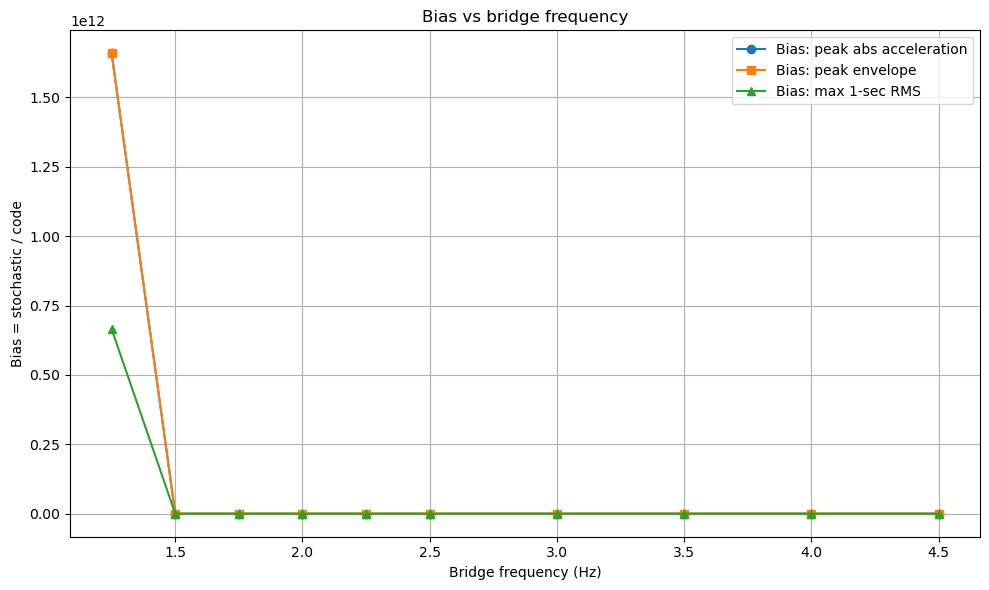

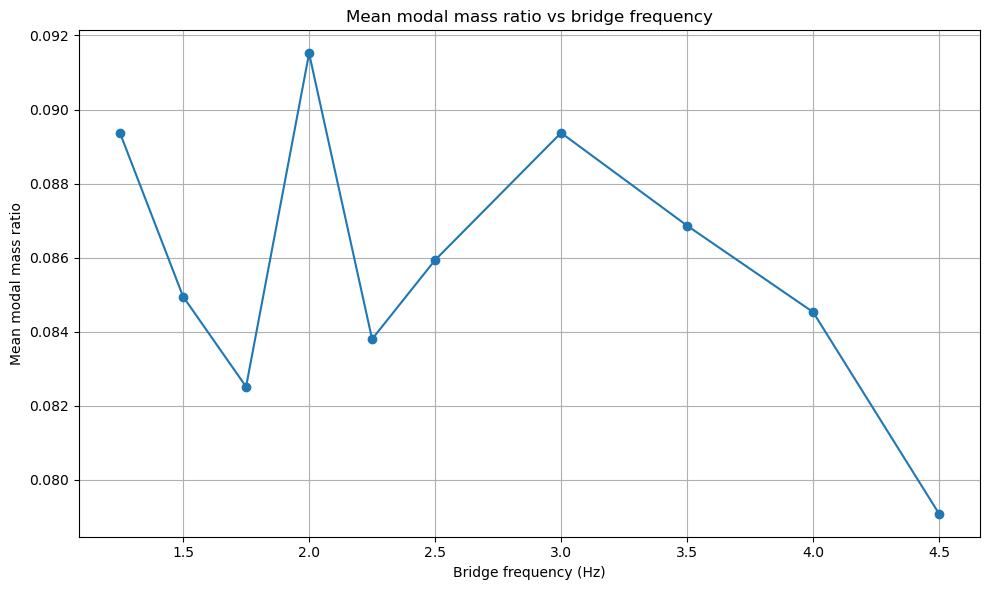

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing
import numpy as np
import matplotlib.pyplot as plt

from bias import run_simulation
from biascodefunction import run_code_response, compute_bias_from_histories

NUM_SIMULATIONS = 10
NUM_PROCESSES = 1
hht = 0.01

if __name__ == "__main__":
    # -----------------------------------------
    # fixed inputs
    # -----------------------------------------
    peddamp = 0.30
    pedBodyF = 3.10
    Tocity = 15
    Outcity = 15
    Length = 50.0
    Width = 2.0
    linear_mass = 500.0

    density_code = (Tocity + Outcity) / (Length * Width)

    # bridge frequencies to loop over
    f1_list = [1.25, 1.5, 1.75, 2.0, 2.25,2.5,3.0,3.5,4.0,4.5]  # Hz

    # damping ratio
    xi1 = 0.005

    # store results
    freq_results = []
    bias_peak_abs_all = []
    bias_peak_env_all = []
    bias_rms_all = []
    mean_mass_ratio_all = []

    for f1 in f1_list:
        print(f"\n==============================")
        print(f"Running for bridge frequency = {f1:.2f} Hz")
        print(f"==============================")

    
        BeamFreq = np.array([f1, 4.0*f1], dtype=float)
        Beamdamp = np.array([xi1, xi1], dtype=float)

        # -----------------------------------------
        # stochastic Monte Carlo
        # -----------------------------------------
        with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
            args_list = [
                (None, peddamp, pedBodyF, BeamFreq, Beamdamp, Tocity, Outcity, Length, Width)
                for _ in range(NUM_SIMULATIONS)
            ]
            results = pool.map(run_simulation, args_list)

        accelerations = np.array([r[0] for r in results], dtype=float)
        mean_mass_ratios = np.array([r[1] for r in results], dtype=float)

        mean_acceleration = np.mean(accelerations, axis=0)
        overall_mean_mass_ratio = np.mean(mean_mass_ratios)

        t_end_code = accelerations.shape[1] * hht
        numbers = len(BeamFreq)

        # -----------------------------------------
        # deterministic code prediction
        # -----------------------------------------
        code_result = run_code_response(
            density=density_code,
            mass_ratio=overall_mean_mass_ratio,
            length=Length,
            width=Width,
            beam_freq=BeamFreq,
            modal_damping_ratio=Beamdamp,
            linear_mass=linear_mass,
            hht=hht,
            t_end=t_end_code,
            numbers=numbers,
            modify_both_modes=True
        )

        acc_code = np.asarray(code_result["acceleration"], dtype=float)

        # -----------------------------------------
        # bias
        # -----------------------------------------
        n = min(len(mean_acceleration), len(acc_code))
        acc_mc = mean_acceleration[:n]
        acc_cd = acc_code[:n]

        bias = compute_bias_from_histories(acc_mc, acc_cd, hht)

        print("Mean modal mass ratio       =", overall_mean_mass_ratio)
        print("Bias peak abs acceleration  =", bias["bias_peak_abs"])
        print("Bias peak envelope          =", bias["bias_peak_envelope"])
        print("Bias max 1-sec RMS          =", bias["bias_max_rms_1s"])

        freq_results.append(f1)
        mean_mass_ratio_all.append(overall_mean_mass_ratio)
        bias_peak_abs_all.append(bias["bias_peak_abs"])
        bias_peak_env_all.append(bias["bias_peak_envelope"])
        bias_rms_all.append(bias["bias_max_rms_1s"])

    # -----------------------------------------
    # convert to arrays
    # -----------------------------------------
    freq_results = np.array(freq_results, dtype=float)
    mean_mass_ratio_all = np.array(mean_mass_ratio_all, dtype=float)
    bias_peak_abs_all = np.array(bias_peak_abs_all, dtype=float)
    bias_peak_env_all = np.array(bias_peak_env_all, dtype=float)
    bias_rms_all = np.array(bias_rms_all, dtype=float)

    # -----------------------------------------
    # print summary table
    # -----------------------------------------
    print("\n\n=========== SUMMARY ===========")
    print("f_bridge   mean_mass_ratio   bias_peak_abs   bias_peak_env   bias_rms_1s")
    for i in range(len(freq_results)):
        print(f"{freq_results[i]:7.3f}   "
              f"{mean_mass_ratio_all[i]:15.6f}   "
              f"{bias_peak_abs_all[i]:13.6f}   "
              f"{bias_peak_env_all[i]:13.6f}   "
              f"{bias_rms_all[i]:11.6f}")

    # -----------------------------------------
    # plot bias vs bridge frequency
    # -----------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(freq_results, bias_peak_abs_all, marker='o', label="Bias: peak abs acceleration")
    plt.plot(freq_results, bias_peak_env_all, marker='s', label="Bias: peak envelope")
    plt.plot(freq_results, bias_rms_all, marker='^', label="Bias: max 1-sec RMS")
    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Bias = stochastic / code")
    plt.title("Bias vs bridge frequency")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # optional: modal mass ratio vs frequency
    plt.figure(figsize=(10, 6))
    plt.plot(freq_results, mean_mass_ratio_all, marker='o')
    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Mean modal mass ratio")
    plt.title("Mean modal mass ratio vs bridge frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

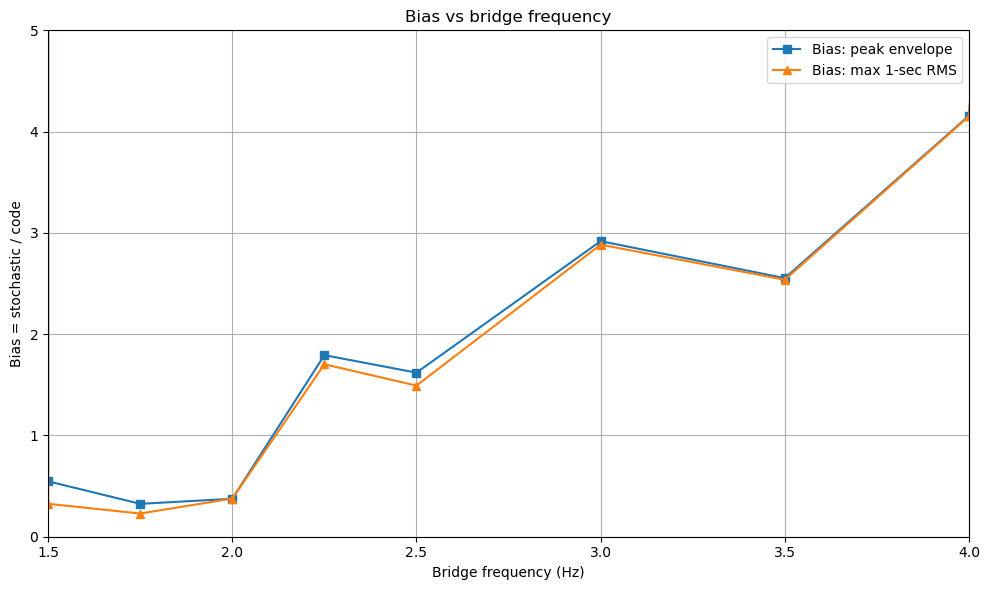

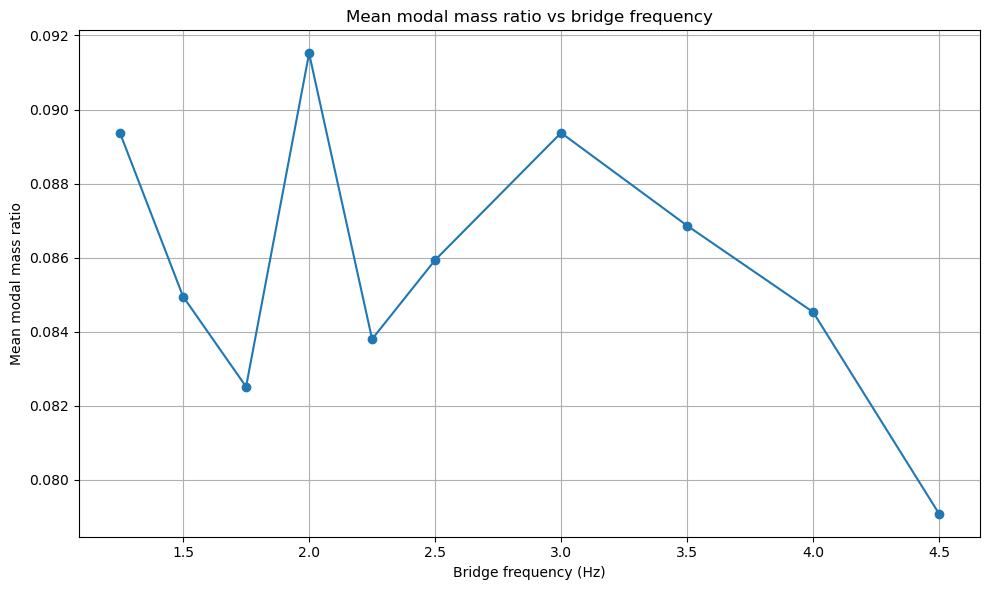

In [5]:

    # -----------------------------------------
    # plot bias vs bridge frequency
    # -----------------------------------------
plt.figure(figsize=(10, 6))
#plt.plot(freq_results, bias_peak_abs_all, marker='o', label="Bias: peak abs acceleration")
plt.plot(freq_results, bias_peak_env_all, marker='s', label="Bias: peak envelope")
plt.plot(freq_results, bias_rms_all, marker='^', label="Bias: max 1-sec RMS")
plt.xlabel("Bridge frequency (Hz)")
plt.xlim(1.5, 4.0)
plt.ylabel("Bias = stochastic / code")
plt.ylim(0.0, 5.0)
plt.title("Bias vs bridge frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# optional: modal mass ratio vs frequency
plt.figure(figsize=(10, 6))
plt.plot(freq_results, mean_mass_ratio_all, marker='o')
plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Mean modal mass ratio")
plt.title("Mean modal mass ratio vs bridge frequency")
plt.grid(True)
plt.tight_layout()
plt.show()